# 4개 방법 워크스루 — 코드 검증용 노트북

**이 노트북의 목적은 "결과 보고"가 아니라 "코드 검증"이다.**
`simple kriging` / `SGS` / `RBF+bootstrap` / `GP-MLE` 네 방법이 실제로 어떤 중간 산출물을
만들어내는지, 셀을 하나씩 내려가며 눈으로 확인하기 위한 것이다.

## 설계 원칙

1. **`src/`의 실제 함수를 import해서 호출한다.** 로직을 노트북에 다시 구현하지 않는다.
   각 셀 머리말에 `src/experiments/*.py`의 어느 단계에 해당하는지 명시했다.
   - `geostats.kb2d`, `geostats.sgsim`, `geostats.nscore`, `geostats.gamv`, `geostats.vmodel`
   - `src.experiments.kriging.backtr_value_vectorized`
   - `src.experiments.rbf_bootstrap.cv_mse_grid_search`
   - `src.experiments.gp_mle.build_kernel`
   - `src.experiments.base_case_conditioning.{build_vario, get_base_case_truth, get_conditioning_samples}`
   - `src.evaluation.{conditioning_cell_mask, mse, calc_umg, accuracy_plot_fraction_in,
     kriging_fraction_in, gaussian_interval_widths, kriging_interval_widths,
     gaussian_crps, kriging_crps, crps_gaussian_analytic, kriging_quantiles_physical, crps_tau_grid}`
   - **예외**: `kriging.main()` / `sgs.main()` / `rbf_bootstrap.main()` / `gp_mle.main()` 안에
     *인라인으로* 들어있는 오케스트레이션 코드(kb2d 호출 블록, Monte Carlo 분산 블록,
     bootstrap replicate 루프, sgsim 호출 블록)는 함수로 분리되어 있지 않아 import가 불가능하다.
     이 부분들은 **같은 상수·같은 순서로 호출을 재현**했고, 해당 셀에 그 사실을 명시했다.
     (`src/` 코드를 리팩토링하지 말라는 지시에 따라 분리하지 않았다.)
2. **중간 산출물의 수치를 반드시 print한다** — shape, min/max/mean/std, 하이퍼파라미터 값 등.
   그림만으로는 검증이 되지 않는다.
3. **저장하지 않는다.** `make_run_dir` / `save_result`를 호출하지 않으므로 `results/raw/`에
   새 run이 생기지 않는다. 계산은 전부 메모리에서만 이뤄진다.

## 위치 근거 (`notebooks/`)

`CLAUDE.md`의 디렉터리 구조에는 `notebooks/`가 없다. 이 노트북은
- 시뮬레이션 **산출물**(→ `results/raw/`)도,
- 논문용 **가공 데이터/그림**(→ `results/processed/`, `results/figures/`)도,
- 재사용되는 **라이브러리 코드**(→ `src/`)도 아니고,

"사람이 코드를 눈으로 따라가며 검증하는 용도"라는 별도 성격이라 기존 4개 디렉터리 중
어디에도 맞지 않는다. 따라서 `notebooks/`를 신설하고 이 목적의 노트북만 여기 둔다.

## 실행 시간

전체 실행은 대략 **3~7분**이다. 가장 오래 걸리는 셀:

| 셀 | 대략 소요 |
|---|---|
| §2 `geostats.sgsim` (10 realization) | **40~75초** |
| §0 ground truth 생성 (unconditional sgsim) | 5~15초 |
| §1 `geostats.kb2d` + Monte Carlo 역변환 | 5~15초 |
| §3 RBF CV 그리드 서치 (9 x 7 x 5-fold = 315 fit) | 5~20초 |
| §5 kriging UMG (스칼라 back-transform 루프) | 10~40초 |

## 커널

`.venv` (Python 3.8)의 `python3` 커널을 사용한다. 노트북 metadata에 지정되어 있다.

## 0.0 Import

`src.experiments.*` 모듈은 **import 시점에 `matplotlib.use("Agg")`를 호출**한다
(스크립트로 headless 실행할 때 파일로 저장하기 위한 설정). 노트북에서는 그림이 셀에 떠야 하므로
import가 전부 끝난 **뒤에** inline 백엔드로 되돌린다. 순서가 바뀌면 그림이 하나도 보이지 않는다.

In [1]:
import sys
import time
from pathlib import Path

# repo root 자동 탐색 (notebooks/에서 열든 repo root에서 열든 동작)
_here = Path.cwd().resolve()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "CLAUDE.md").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import RBFInterpolator
from sklearn.gaussian_process import GaussianProcessRegressor

import geostatspy.GSLIB as GSLIB
import geostatspy.geostats as geostats

# --- 검증 대상: src/ 의 실제 모듈 (로직 재구현 없이 이 객체들만 호출한다) ---
import src.experiments.base_case as base_case
import src.experiments.base_case_conditioning as cond
import src.experiments.kriging as kriging_mod
import src.experiments.rbf_bootstrap as rbf_mod
import src.experiments.sgs as sgs_mod
import src.experiments.gp_mle as gp_mod
import src.evaluation as ev
from src.grid_utils import full_grid_coordinates

# src.experiments.* 가 Agg로 바꿔놓은 백엔드를 inline으로 되돌린다 (위 설명 참고)
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 96
matplotlib.rcParams["figure.max_open_warning"] = 0
matplotlib.rcParams["axes.grid"] = False

# 한글 라벨이 네모(tofu)로 깨지지 않도록 한글 폰트 지정 (없으면 기본값 유지)
from matplotlib import font_manager as _fm
_installed = {f.name for f in _fm.fontManager.ttflist}
for _cand in ["Malgun Gothic", "NanumGothic", "AppleGothic", "Noto Sans CJK KR"]:
    if _cand in _installed:
        matplotlib.rcParams["font.family"] = _cand
        matplotlib.rcParams["axes.unicode_minus"] = False
        break
else:
    print("WARNING: 한글 폰트를 찾지 못했다 - 그림의 한글 라벨이 깨질 수 있다.")

print("python          :", sys.version.split()[0])
print("REPO_ROOT       :", REPO_ROOT)
print("matplotlib 백엔드:", matplotlib.get_backend())
print("numpy / pandas  :", np.__version__, "/", pd.__version__)
print()
print("이 노트북은 results/raw/ 에 아무것도 쓰지 않는다 (make_run_dir/save_result 미호출).")

python          : 3.8.10
REPO_ROOT       : C:\Users\yj7563\Desktop\NewWorld
matplotlib 백엔드: module://matplotlib_inline.backend_inline
numpy / pandas  : 1.24.4 / 2.0.3

이 노트북은 results/raw/ 에 아무것도 쓰지 않는다 (make_run_dir/save_result 미호출).


## 0.1 파라미터 블록

여기만 바꿔서 재실행하면 다른 axis 설정도 재현된다.

- `RANGE = 300.0` → base case. range axis는 100~800 m를 100 m 간격 8레벨로 돌린 것이므로
  `RANGE = 100.0` ... `800.0` 중 하나로 바꾸면 그 레벨이 재현된다.
- `N_SAMPLES = 125` → base case(2500셀의 5%). sample-density axis는 `50`(2%), `25`(1%).
- `TRUTH_SEED = 101`, `SAMPLE_SEED = 20` → 두 축 모두 고정.

그리드/분포/변동도 구조 상수(`NX, NY, XSIZ, XMN, POR_MEAN, NUG, CC1, IT1` 등)는 여기서
**재선언하지 않고** `src/experiments/base_case.py`에서 그대로 가져온다 — 단일 소스 원칙.

In [2]:
# ============================ 파라미터 블록 ============================
RANGE       = 300.0   # variogram range (m).  range axis: 100 ~ 800
N_SAMPLES   = 125     # 요청 샘플 수.         sample-density axis: 125 / 50 / 25
TRUTH_SEED  = 101
SAMPLE_SEED = 20
# =====================================================================

HMAJ1 = HMIN1 = RANGE          # isotropic (base case 및 range axis 전부 등방)

# --- 아래는 base_case.py 단일 소스에서 가져오는 것이지 여기서 정하는 값이 아니다 ---
NX, NY                 = base_case.NX, base_case.NY
XSIZ, YSIZ             = base_case.XSIZ, base_case.YSIZ
XMN, YMN               = base_case.XMN, base_case.YMN
XMIN, XMAX, YMIN, YMAX = base_case.XMIN, base_case.XMAX, base_case.YMIN, base_case.YMAX
POR_MEAN, POR_STDEV    = base_case.POR_MEAN, base_case.POR_STDEV
VCOL                   = cond.VCOL

print("그리드      : nx=%d ny=%d  xsiz=%.1f ysiz=%.1f  xmn=%.1f ymn=%.1f  domain=[%g,%g]x[%g,%g]"
      % (NX, NY, XSIZ, YSIZ, XMN, YMN, XMIN, XMAX, YMIN, YMAX))
print("목표 분포   : mean=%.1f stdev=%.1f  (물리 단위 porosity %%)" % (POR_MEAN, POR_STDEV))
print("변동도 구조 : nug=%.2f it1=%d cc1=%.2f azi1=%.1f  (nug+cc1=%.2f = NS 공간 sill)"
      % (base_case.NUG, base_case.IT1, base_case.CC1, base_case.AZI1, base_case.NUG + base_case.CC1))
print("값 컬럼     : %r" % VCOL)
print()

_checks = [
    ("RANGE (hmaj1/hmin1)", RANGE,       cond.HMAJ1),
    ("N_SAMPLES",           N_SAMPLES,   cond.N_SAMPLES),
    ("TRUTH_SEED",          TRUTH_SEED,  cond.TRUTH_SEED),
    ("SAMPLE_SEED",         SAMPLE_SEED, cond.SAMPLE_SEED),
]
print("노트북 파라미터 vs base case 기본값")
for _name, _nb, _base in _checks:
    _tag = "base case 그대로" if _nb == _base else ">>> base case에서 벗어남 <<<"
    print("  %-22s notebook=%-8s base_case=%-8s  %s" % (_name, _nb, _base, _tag))

그리드      : nx=50 ny=50  xsiz=20.0 ysiz=20.0  xmn=10.0 ymn=10.0  domain=[0,1000]x[0,1000]
목표 분포   : mean=15.0 stdev=3.0  (물리 단위 porosity %)
변동도 구조 : nug=0.05 it1=1 cc1=0.95 azi1=0.0  (nug+cc1=1.00 = NS 공간 sill)
값 컬럼     : 'Por'

노트북 파라미터 vs base case 기본값
  RANGE (hmaj1/hmin1)    notebook=300.0    base_case=300.0     base case 그대로
  N_SAMPLES              notebook=125      base_case=125       base case 그대로
  TRUTH_SEED             notebook=101      base_case=101       base case 그대로
  SAMPLE_SEED            notebook=20       base_case=20        base case 그대로


## 0.2 공통 플롯/출력 헬퍼

**시각화 전용 코드다. 파이프라인 로직이 아니다.** `src/`의 어떤 계산도 여기서 다시 구현하지 않는다.

In [3]:
def show_map(ax, arr, title, cbar_label, cmap="viridis", vmin=None, vmax=None,
             samples=None, sample_color="red", sample_size=7):
    # src/experiments/*.py 의 QC 그림들과 동일한 imshow 규약:
    # extent=[XMIN,XMAX,YMIN,YMAX], origin="upper" (row 0 = max-y row)
    im = ax.imshow(arr, extent=[XMIN, XMAX, YMIN, YMAX], origin="upper",
                   cmap=cmap, vmin=vmin, vmax=vmax)
    if samples is not None:
        ax.scatter(samples["X"], samples["Y"], s=sample_size, c=sample_color,
                   marker="+", linewidths=0.6)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("X (m)", fontsize=8)
    ax.set_ylabel("Y (m)", fontsize=8)
    ax.tick_params(labelsize=7)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(cbar_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)
    return im


def describe(name, arr):
    a = np.asarray(arr, dtype=float)
    print("%-38s shape=%-14s min=%11.5f  max=%11.5f  mean=%11.5f  std=%10.5f  n_nan=%d"
          % (name, str(a.shape), np.nanmin(a), np.nanmax(a), np.nanmean(a),
             np.nanstd(a), int(np.sum(~np.isfinite(a)))))


print("헬퍼 정의 완료: show_map(), describe()")

헬퍼 정의 완료: show_map(), describe()


## 0.3 Ground truth 필드

**대응**: 4개 방법 `main()` 전부의 **1단계** —
`base_case_conditioning.get_base_case_conditioning_data()` 안의
`get_base_case_truth(truth_seed, hmaj1, hmin1)` 호출.

내부적으로 `src/truth_model.py: make_porosity_truth()` →
`geostats.sgsim(itrans=0, ktype=0, 더미 조건데이터)` 로 **무조건부(unconditional) 시뮬레이션**을
표준정규 공간에서 수행한 뒤 `GSLIB.affine(sim_ns, mean, stdev)`로 목표 평균/표준편차를 입힌다.


 Data for SGSIM: Number of acceptable data     = 100
                 Number trimmed                = 0
                 Weighted Average              = 0.1664
                 Weighted Variance             = 1.0688
                 Weighted Transformed Average  = 0.1664
                 Weighted Transformed Variance = 1.0688
Setting up rotation matrices for variogram and search


Working on realization number 0
   currently on node 0


   currently on node 250
   currently on node 500
   currently on node 750


   currently on node 1000
   currently on node 1250
   currently on node 1500


   currently on node 1750
   currently on node 2000
   currently on node 2250


Reassigning data to nodes

 Realization 0: number   = 2500
                                   mean     = -0.2469 (close to 0.0?)
                                   variance = 1.1977 (close to gammabar(V,V)? approx. 1.0)
get_base_case_truth() 소요: 3.4초

truth (물리 단위 porosity %)               shape=(50, 50)       min=    6.80504  max=   24.28885  mean=   15.00000  std=   3.00000  n_nan=0

row 0 = max-y row 규약 확인: truth[0, :3] 은 y=990.0 m 행
목표 mean=15.00 / 실제 15.0000,  목표 stdev=3.00 / 실제 3.0000  (단일 realization의 ergodic fluctuation)


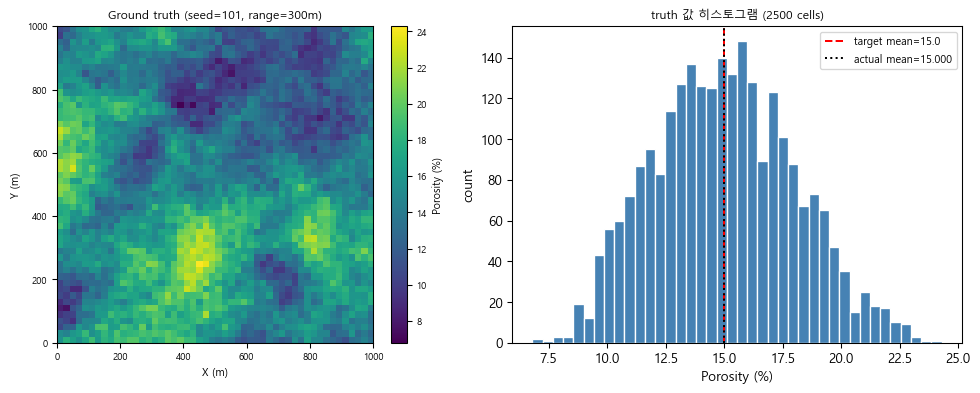

In [4]:
t0 = time.time()
truth = cond.get_base_case_truth(truth_seed=TRUTH_SEED, hmaj1=HMAJ1, hmin1=HMIN1)
print("get_base_case_truth() 소요: %.1f초" % (time.time() - t0))
print()
describe("truth (물리 단위 porosity %)", truth)
print()
print("row 0 = max-y row 규약 확인: truth[0, :3] 은 y=%.1f m 행" % (YMN + (NY - 1) * YSIZ))
print("목표 mean=%.2f / 실제 %.4f,  목표 stdev=%.2f / 실제 %.4f  (단일 realization의 ergodic fluctuation)"
      % (POR_MEAN, truth.mean(), POR_STDEV, truth.std()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
show_map(axes[0], truth, "Ground truth (seed=%d, range=%gm)" % (TRUTH_SEED, RANGE), "Porosity (%)")
axes[1].hist(truth.ravel(), bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(POR_MEAN, color="red", ls="--", label="target mean=%.1f" % POR_MEAN)
axes[1].axvline(truth.mean(), color="black", ls=":", label="actual mean=%.3f" % truth.mean())
axes[1].set_title("truth 값 히스토그램 (%d cells)" % truth.size, fontsize=9)
axes[1].set_xlabel("Porosity (%)"); axes[1].set_ylabel("count")
axes[1].legend(fontsize=8)
plt.tight_layout()

## 0.4 조건화 샘플 (4개 방법 공통)

**대응**: 4개 방법 `main()` 전부의 **1단계 후반** —
`get_base_case_conditioning_data()` 안의 `get_conditioning_samples(truth, sample_seed, n_samples)`.

내부적으로 `src/sampling.py: random_interior_samples()`가
1. 도메인 안쪽 `margin_frac=0.05` 여백을 둔 영역에서 `n_samples`개 균등 난수 좌표를 뽑고,
2. 각 좌표를 **가장 가까운 셀 중심으로 스냅**하고 (`_snap_to_grid_index`, GSLIB `+0.5` 반올림),
3. **같은 셀에 중복 매핑된 샘플을 버린다** → 그래서 실제 개수가 요청 개수보다 적다 (125 → 121).

이 DataFrame 하나를 4개 방법이 **그대로 공유**한다 ("identical sample locations across methods").

요청 n_samples          : 125
중복 셀 제거 후 실제 개수: 121  (4개 드롭)
샘플 비율               : 4.84% of 2500 cells
margin_frac             : 0.05 -> 샘플 가능 영역 x,y in [50.0, 950.0]

samples X                              shape=(121,)         min=   50.00000  max=  950.00000  mean=  516.11570  std= 239.72219  n_nan=0
samples Y                              shape=(121,)         min=   50.00000  max=  950.00000  mean=  570.00000  std= 250.48713  n_nan=0
samples Por                            shape=(121,)         min=    8.35131  max=   22.06934  mean=   14.10359  std=   2.60178  n_nan=0

좌표가 셀 중심에 정확히 스냅되었는지: max |(X-XMN)/XSIZ - round(...)| = 0.000e+00

       X      Y        Por
0  570.0  930.0  11.238153
1  850.0  870.0  11.163036
2  850.0  570.0  12.996035
3  790.0  450.0  16.230512
4   90.0  450.0  17.511526


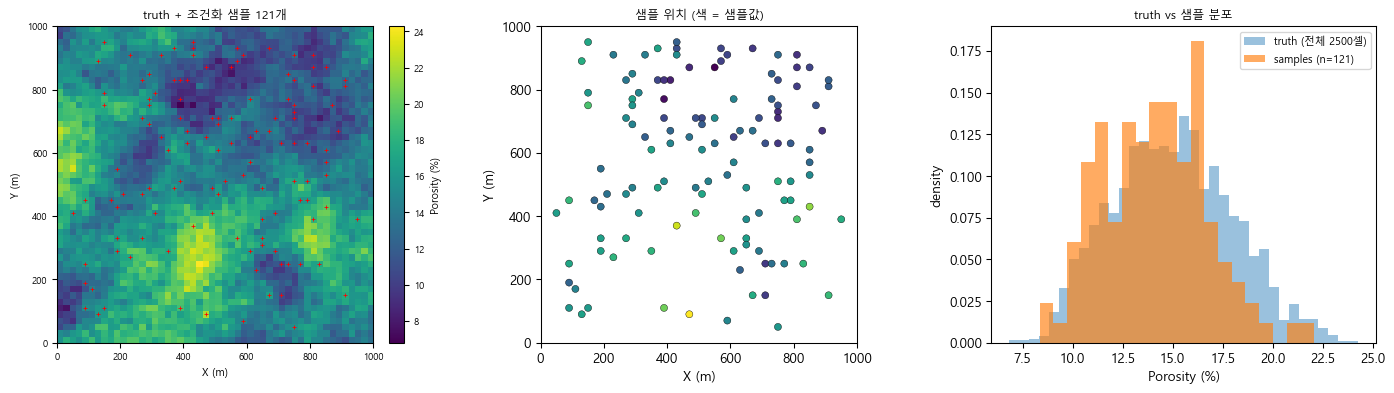

In [5]:
samples_df = cond.get_conditioning_samples(truth, sample_seed=SAMPLE_SEED, n_samples=N_SAMPLES)
n_actual_samples = len(samples_df)

print("요청 n_samples          : %d" % N_SAMPLES)
print("중복 셀 제거 후 실제 개수: %d  (%d개 드롭)" % (n_actual_samples, N_SAMPLES - n_actual_samples))
print("샘플 비율               : %.2f%% of %d cells" % (100.0 * n_actual_samples / (NX * NY), NX * NY))
print("margin_frac             : %.2f -> 샘플 가능 영역 x,y in [%.1f, %.1f]"
      % (cond.MARGIN_FRAC, XMIN + cond.MARGIN_FRAC * (XMAX - XMIN), XMAX - cond.MARGIN_FRAC * (XMAX - XMIN)))
print()
describe("samples X", samples_df["X"].values)
describe("samples Y", samples_df["Y"].values)
describe("samples %s" % VCOL, samples_df[VCOL].values)
print()
print("좌표가 셀 중심에 정확히 스냅되었는지: max |(X-XMN)/XSIZ - round(...)| = %.3e"
      % np.max(np.abs((samples_df["X"].values - XMN) / XSIZ
                      - np.round((samples_df["X"].values - XMN) / XSIZ))))
print()
print(samples_df.head())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
show_map(axes[0], truth, "truth + 조건화 샘플 %d개" % n_actual_samples, "Porosity (%)", samples=samples_df)
axes[1].scatter(samples_df["X"], samples_df["Y"], c=samples_df[VCOL], cmap="viridis",
                s=28, edgecolor="k", linewidths=0.3)
axes[1].set_xlim(XMIN, XMAX); axes[1].set_ylim(YMIN, YMAX); axes[1].set_aspect("equal")
axes[1].set_title("샘플 위치 (색 = 샘플값)", fontsize=9)
axes[1].set_xlabel("X (m)"); axes[1].set_ylabel("Y (m)")
axes[2].hist(truth.ravel(), bins=35, density=True, alpha=0.45, label="truth (전체 %d셀)" % truth.size)
axes[2].hist(samples_df[VCOL].values, bins=20, density=True, alpha=0.65,
             label="samples (n=%d)" % n_actual_samples)
axes[2].set_title("truth vs 샘플 분포", fontsize=9)
axes[2].set_xlabel("Porosity (%)"); axes[2].set_ylabel("density")
axes[2].legend(fontsize=8)
plt.tight_layout()

## 0.5 Variogram 모델

**대응**: kriging(`kb2d`)과 SGS(`sgsim`)가 **동일한 dict 하나를 공유**한다 —
`base_case_conditioning.build_vario(hmaj1, hmin1)` → `GSLIB.make_variogram(...)`.

RBF+bootstrap과 GP-MLE는 이 dict를 쓰지 않는다 (각자 CV / marginal likelihood로 하이퍼파라미터를
스스로 고른다). 이 대비가 논문의 비교 구도 자체다.

모델 곡선은 `geostats.vmodel(nlag, xlag, azm, vario)`로 뽑는다 (직접 구현하지 않음).

build_vario() 반환 dict (kb2d와 sgsim에 그대로 재사용되는 바로 그 객체):
   azi1     = 0.0
   azi2     = 0
   cc1      = 0.95
   cc2      = 0
   hmaj1    = 300.0
   hmaj2    = 0
   hmin1    = 300.0
   hmin2    = 0
   it1      = 1
   it2      = 1
   nst      = 1
   nug      = 0.05

sill 확인: nug + cc1 = 1.0000  (NS 공간 sill=1.0 이어야 함)
it1=1 -> spherical
anisotropy ratio hmin1/hmaj1 = 1.000 (1.0 = isotropic)

 x,y,z offsets = 0.0,20.0


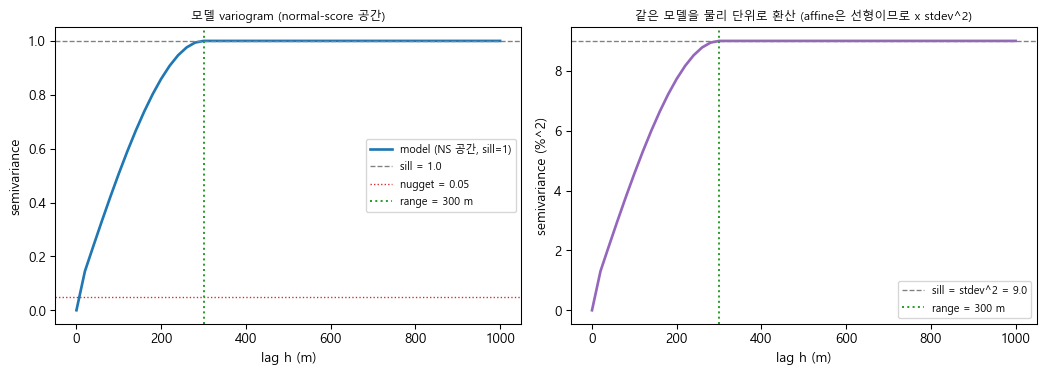

In [6]:
vario = cond.build_vario(hmaj1=HMAJ1, hmin1=HMIN1)

print("build_vario() 반환 dict (kb2d와 sgsim에 그대로 재사용되는 바로 그 객체):")
for k in sorted(vario.keys()):
    print("   %-8s = %s" % (k, vario[k]))
print()
print("sill 확인: nug + cc1 = %.4f  (NS 공간 sill=1.0 이어야 함)" % (vario["nug"] + vario["cc1"]))
print("it1=%d -> %s" % (vario["it1"], {1: "spherical", 2: "exponential", 3: "gaussian"}[vario["it1"]]))
print("anisotropy ratio hmin1/hmaj1 = %.3f (1.0 = isotropic)" % (vario["hmin1"] / vario["hmaj1"]))
print()

_idx, _h, _gam, _cov, _ro = geostats.vmodel(nlag=50, xlag=20.0, azm=0.0, vario=vario)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(_h, _gam, "-", color="tab:blue", lw=2, label="model (NS 공간, sill=1)")
axes[0].axhline(1.0, color="gray", ls="--", lw=1, label="sill = 1.0")
axes[0].axhline(vario["nug"], color="tab:red", ls=":", lw=1, label="nugget = %.2f" % vario["nug"])
axes[0].axvline(RANGE, color="tab:green", ls=":", lw=1.5, label="range = %g m" % RANGE)
axes[0].set_xlabel("lag h (m)"); axes[0].set_ylabel("semivariance")
axes[0].set_title("모델 variogram (normal-score 공간)", fontsize=9)
axes[0].legend(fontsize=8)

axes[1].plot(_h, _gam * POR_STDEV ** 2, "-", color="tab:purple", lw=2)
axes[1].axhline(POR_STDEV ** 2, color="gray", ls="--", lw=1,
                label="sill = stdev^2 = %.1f" % POR_STDEV ** 2)
axes[1].axvline(RANGE, color="tab:green", ls=":", lw=1.5, label="range = %g m" % RANGE)
axes[1].set_xlabel("lag h (m)"); axes[1].set_ylabel("semivariance (%^2)")
axes[1].set_title("같은 모델을 물리 단위로 환산 (affine은 선형이므로 x stdev^2)", fontsize=9)
axes[1].legend(fontsize=8)
plt.tight_layout()

---
# 1. Simple kriging — `src/experiments/kriging.py`

파이프라인 (해당 파일 docstring의 5단계):

1. 공통 조건화 데이터 (§0에서 이미 생성)
2. **normal-score 변환** `geostats.nscore` — variogram dict의 sill이 1.0(NS 공간)이므로
   kriging은 반드시 NS 공간에서 수행해야 한다
3. `geostats.kb2d(..., ktype=0, skmean=0.0)` — simple kriging, NS 공간 평균은 0
4. point estimate를 `geostats.backtr_value`로 물리 단위 역변환
5. **분산은 NS 단위 그대로 저장** (비선형 역변환을 분산에 점별 적용할 수 없음).
   시각화용으로만 Monte Carlo 근사 물리단위 분산을 따로 만든다.

## 1.1 Normal-score 변환 (`geostats.nscore`)

**대응**: `kriging.py` 2단계, `ns, vr, vrg = geostats.nscore(samples_df, VCOL)`.

`vr`/`vrg`는 **역변환 lookup table**이다 (평균/표준편차 쌍이 아님).
`vr[i]`(물리값) ↔ `vrg[i]`(정규점수)가 짝을 이루며, 길이는 샘플 개수와 같다.
이 표의 바깥으로 나가는 값은 선형 tail 외삽으로 처리된다 (§1.6에서 진단).

ns (정규점수 변환된 샘플값)                      shape=(121,)         min=   -2.38287  max=    2.64107  mean=    0.00213  std=   0.98932  n_nan=0
vr  (변환표: 물리값)                         shape=(121,)         min=    8.35131  max=   22.06934  mean=   14.10359  std=   2.60178  n_nan=0
vrg (변환표: 정규점수)                        shape=(121,)         min=   -2.64107  max=    2.64107  mean=   -0.00000  std=   0.99473  n_nan=0

변환표 길이 = 121  (= 샘플 개수 121)
변환표가 단조증가인지: vr diff min=1.314e-04, vrg diff min=2.072e-02 (둘 다 > 0 이어야 함)
변환표 커버 범위: 물리 [8.3513, 22.0693]  <->  NS [-2.6411, 2.6411]
NPor 평균=0.0021 표준편차=0.9893 (표준정규에 가까워야 함)


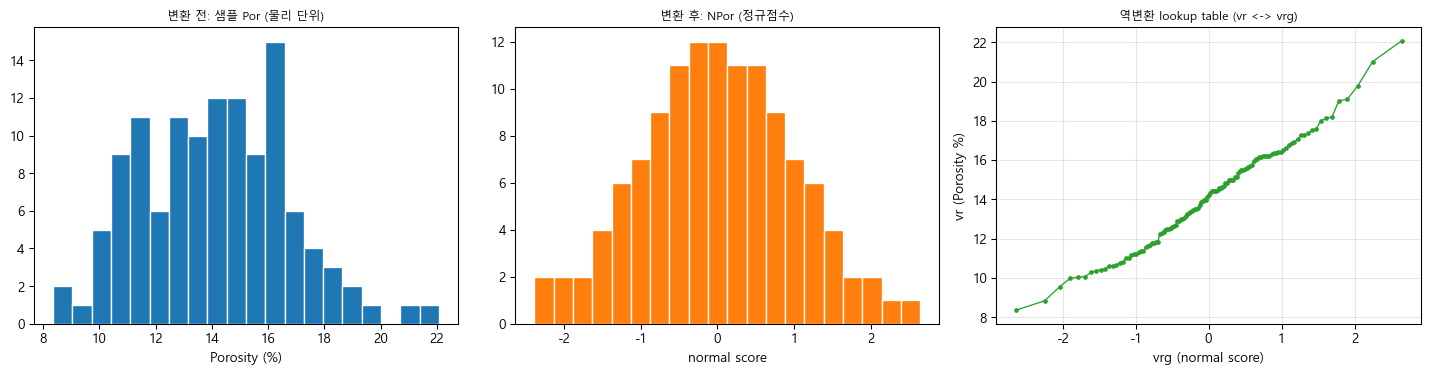

In [7]:
ns, vr, vrg = geostats.nscore(samples_df, VCOL)
ks_df = samples_df.copy()
ks_df["NPor"] = ns

describe("ns (정규점수 변환된 샘플값)", ns)
describe("vr  (변환표: 물리값)", vr)
describe("vrg (변환표: 정규점수)", vrg)
print()
print("변환표 길이 = %d  (= 샘플 개수 %d)" % (len(vr), n_actual_samples))
print("변환표가 단조증가인지: vr diff min=%.3e, vrg diff min=%.3e (둘 다 > 0 이어야 함)"
      % (np.min(np.diff(vr)), np.min(np.diff(vrg))))
print("변환표 커버 범위: 물리 [%.4f, %.4f]  <->  NS [%.4f, %.4f]"
      % (vr[0], vr[-1], vrg[0], vrg[-1]))
print("NPor 평균=%.4f 표준편차=%.4f (표준정규에 가까워야 함)" % (ns.mean(), ns.std()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(samples_df[VCOL].values, bins=20, color="tab:blue", edgecolor="white")
axes[0].set_title("변환 전: 샘플 Por (물리 단위)", fontsize=9)
axes[0].set_xlabel("Porosity (%)")
axes[1].hist(ns, bins=20, color="tab:orange", edgecolor="white")
axes[1].set_title("변환 후: NPor (정규점수)", fontsize=9)
axes[1].set_xlabel("normal score")
axes[2].plot(vrg, vr, "-o", ms=2.5, lw=1, color="tab:green")
axes[2].set_xlabel("vrg (normal score)"); axes[2].set_ylabel("vr (Porosity %)")
axes[2].set_title("역변환 lookup table (vr <-> vrg)", fontsize=9)
axes[2].grid(alpha=0.3)
plt.tight_layout()

## 1.2 `geostats.kb2d` — simple kriging (NS 공간)

**대응**: `kriging.py` 3단계. 상수는 전부 `kriging_mod`에서 그대로 가져온다
(`KTYPE=0`, `SKMEAN_NS=0.0`, `NXDIS/NYDIS=1`, `NDMIN=0`, `NDMAX=50`, `RADIUS=9999`,
`KB2D_TMIN/TMAX=-9999/9999`).

`KB2D_TMIN/TMAX`는 과거에 버그가 있던 자리다 — 엉뚱한 상수(`±3.0`)를 재사용해 |NPor|>3인
샘플이 조용히 드롭됐었다. `kriging.py`는 kb2d의 필터를 **직접 재현해 개수를 검증**하는 가드를
갖고 있고, 아래 셀에서 그 가드도 같이 재현한다.

> 이 셀의 `kb2d` 호출 블록은 `kriging.main()` 안에 인라인으로 있는 코드이며, 함수로 분리되어
> 있지 않다. 동일 인자·동일 순서로 **호출만 재현**했다 (로직 재구현 아님).

kb2d 파라미터 (전부 src/experiments/kriging.py 의 상수):
   KTYPE      = 0
   SKMEAN_NS  = 0.0
   NXDIS      = 1
   NYDIS      = 1
   NDMIN      = 0
   NDMAX      = 50
   RADIUS     = 9999
   KB2D_TMIN  = -9999
   KB2D_TMAX  = 9999
   ktype=0 -> simple kriging (데이터에서 멀어지면 전역 평균으로 revert, 분산 -> sill)



  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:00<00:24,  2.00it/s]

  4%|▍         | 2/50 [00:00<00:16,  2.90it/s]

  6%|▌         | 3/50 [00:00<00:13,  3.52it/s]

...

 96%|█████████▌| 48/50 [00:10<00:00,  4.93it/s]

 98%|█████████▊| 49/50 [00:10<00:00,  4.97it/s]

100%|██████████| 50/50 [00:10<00:00,  4.92it/s]

100%|██████████| 50/50 [00:10<00:00,  4.69it/s]

  Estimated   2500 blocks 
      average   0.30631860790256965  variance  0.7479229887542888
kb2d 소요: 10.66초

kmap_ns (NS 공간 추정값)                    shape=(50, 50)       min=   -2.38287  max=    2.64107  mean=    0.30632  std=   0.86483  n_nan=0
vmap_ns (NS 공간 kriging 분산)             shape=(50, 50)       min=   -0.00000  max=    0.92038  mean=    0.36266  std=   0.18279  n_nan=0

kb2d가 실제로 쓰는 조건화 샘플 수: 121 / 121  -> OK
  (참고) |NPor| > 3.0 인 샘플 0개 — 과거 tmin/tmax=±3.0 버그였다면 이만큼 조용히 드롭됐다

vmap_ns 최솟값 -2.480e-15 (샘플 셀에서 0에 수렴), 최댓값 0.9204 (sill=1.00 에 접근)


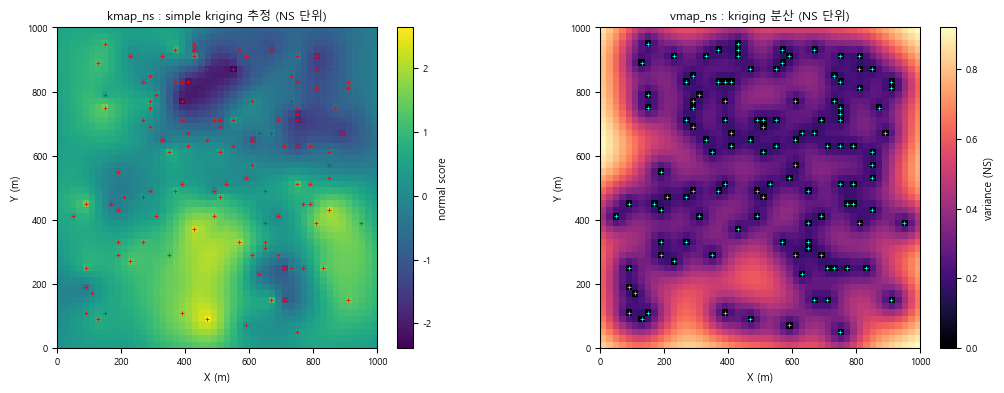

In [8]:
print("kb2d 파라미터 (전부 src/experiments/kriging.py 의 상수):")
for _n in ["KTYPE", "SKMEAN_NS", "NXDIS", "NYDIS", "NDMIN", "NDMAX", "RADIUS",
           "KB2D_TMIN", "KB2D_TMAX"]:
    print("   %-10s = %s" % (_n, getattr(kriging_mod, _n)))
print("   ktype=0 -> simple kriging (데이터에서 멀어지면 전역 평균으로 revert, 분산 -> sill)")
print()

t0 = time.time()
kmap_ns, vmap_ns = geostats.kb2d(
    ks_df, "X", "Y", "NPor",
    kriging_mod.KB2D_TMIN, kriging_mod.KB2D_TMAX,
    NX, XMN, XSIZ, NY, YMN, YSIZ,
    nxdis=kriging_mod.NXDIS, nydis=kriging_mod.NYDIS,
    ndmin=kriging_mod.NDMIN, ndmax=kriging_mod.NDMAX, radius=kriging_mod.RADIUS,
    ktype=kriging_mod.KTYPE, skmean=kriging_mod.SKMEAN_NS, vario=vario,
)
print("kb2d 소요: %.2f초" % (time.time() - t0))
print()
describe("kmap_ns (NS 공간 추정값)", kmap_ns)
describe("vmap_ns (NS 공간 kriging 분산)", vmap_ns)
print()

# kriging.py 의 가드 재현: kb2d 내부 tmin/tmax 필터로 드롭되는 샘플이 있는지
n_used = int(((ks_df["NPor"] >= kriging_mod.KB2D_TMIN)
              & (ks_df["NPor"] <= kriging_mod.KB2D_TMAX)).sum())
print("kb2d가 실제로 쓰는 조건화 샘플 수: %d / %d  -> %s"
      % (n_used, n_actual_samples, "OK" if n_used == n_actual_samples else "드롭 발생 (버그)"))
print("  (참고) |NPor| > 3.0 인 샘플 %d개 — 과거 tmin/tmax=±3.0 버그였다면 이만큼 조용히 드롭됐다"
      % int((np.abs(ns) > 3.0).sum()))
print()
print("vmap_ns 최솟값 %.3e (샘플 셀에서 0에 수렴), 최댓값 %.4f (sill=%.2f 에 접근)"
      % (vmap_ns.min(), vmap_ns.max(), vario["nug"] + vario["cc1"]))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
show_map(axes[0], kmap_ns, "kmap_ns : simple kriging 추정 (NS 단위)", "normal score",
         samples=samples_df)
show_map(axes[1], vmap_ns, "vmap_ns : kriging 분산 (NS 단위)", "variance (NS)",
         cmap="magma", samples=samples_df, sample_color="cyan")
plt.tight_layout()

## 1.3 물리 단위 역변환 (point estimate)

**대응**: `kriging.py` 4단계. `kriging.main()`은 여기서 **벡터화 버전이 아니라 원본 스칼라**
`geostats.backtr_value`를 셀마다 호출한다 (2500회). 그대로 재현한다.

`kmap_physical`은 `BACKTR_ZMIN/ZMAX`(= mean ± 4·stdev = [3, 27])에 의존한다 —
변환표 바깥으로 나간 셀은 이 경계를 향해 선형 외삽되기 때문. 이 상수의 변경 이력은
`kriging.py`의 긴 주석에 기록돼 있다(±4σ → ±10σ → ±4σ 원복).

역변환 파라미터 (src/experiments/kriging.py):
   BACKTR_ZMIN = 3.0
   BACKTR_ZMAX = 27.0
   LTAIL       = 1
   LTPAR       = 3.0
   UTAIL       = 1
   UTPAR       = 27.0
   ltail=utail=1 -> 선형 tail 외삽 (backtr_value_vectorized가 지원하는 유일한 케이스)

스칼라 backtr_value 2500회 호출: 0.01초

kmap_physical                          shape=(50, 50)       min=    8.35131  max=   22.06934  mean=   14.88560  std=   2.28321  n_nan=0
truth (비교용)                            shape=(50, 50)       min=    6.80504  max=   24.28885  mean=   15.00000  std=   3.00000  n_nan=0


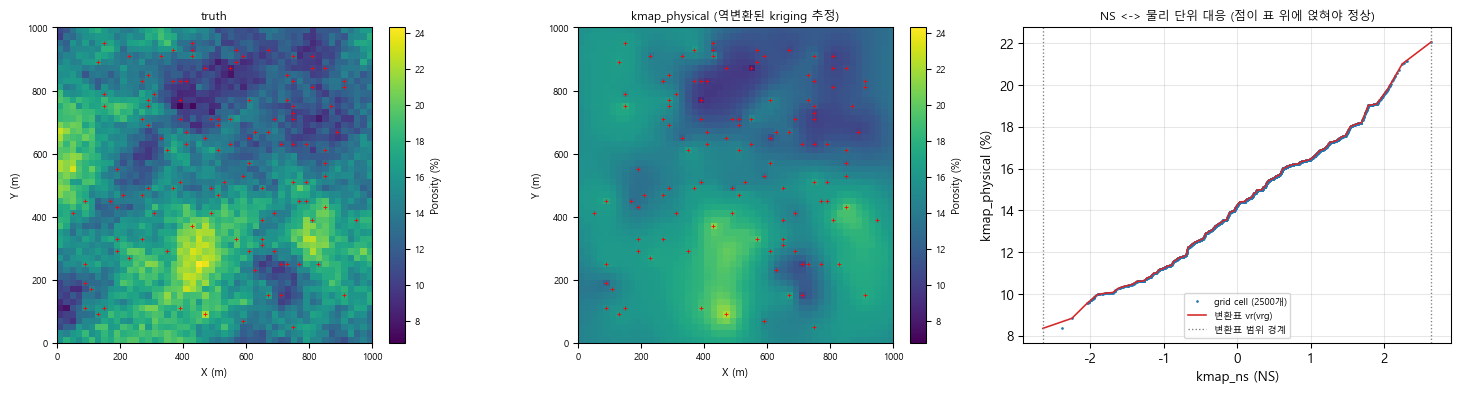

In [9]:
print("역변환 파라미터 (src/experiments/kriging.py):")
for _n in ["BACKTR_ZMIN", "BACKTR_ZMAX", "LTAIL", "LTPAR", "UTAIL", "UTPAR"]:
    print("   %-11s = %s" % (_n, getattr(kriging_mod, _n)))
print("   ltail=utail=1 -> 선형 tail 외삽 (backtr_value_vectorized가 지원하는 유일한 케이스)")
print()

t0 = time.time()
kmap_physical = np.empty((NY, NX))
for iy in range(NY):
    for ix in range(NX):
        kmap_physical[iy, ix] = geostats.backtr_value(
            kmap_ns[iy, ix], vr, vrg,
            zmin=kriging_mod.BACKTR_ZMIN, zmax=kriging_mod.BACKTR_ZMAX,
            ltail=kriging_mod.LTAIL, ltpar=kriging_mod.LTPAR,
            utail=kriging_mod.UTAIL, utpar=kriging_mod.UTPAR,
        )
print("스칼라 backtr_value %d회 호출: %.2f초" % (NX * NY, time.time() - t0))
print()
describe("kmap_physical", kmap_physical)
describe("truth (비교용)", truth)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
_vmin, _vmax = float(truth.min()), float(truth.max())
show_map(axes[0], truth, "truth", "Porosity (%)", vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[1], kmap_physical, "kmap_physical (역변환된 kriging 추정)", "Porosity (%)",
         vmin=_vmin, vmax=_vmax, samples=samples_df)
_o = np.argsort(kmap_ns.ravel())
axes[2].plot(kmap_ns.ravel()[_o], kmap_physical.ravel()[_o], ".", ms=2, color="tab:blue",
             label="grid cell (2500개)")
axes[2].plot(vrg, vr, "-", color="tab:red", lw=1.2, label="변환표 vr(vrg)")
axes[2].axvline(vrg[0], color="gray", ls=":", lw=1)
axes[2].axvline(vrg[-1], color="gray", ls=":", lw=1, label="변환표 범위 경계")
axes[2].set_xlabel("kmap_ns (NS)"); axes[2].set_ylabel("kmap_physical (%)")
axes[2].set_title("NS <-> 물리 단위 대응 (점이 표 위에 얹혀야 정상)", fontsize=9)
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)
plt.tight_layout()

## 1.4 `backtr_value_vectorized` vs 원본 스칼라 `geostats.backtr_value`

**대응**: `kriging.py`의 **필수 검증 단계** (불일치 시 `RuntimeError`로 중단).
Monte Carlo 분산(§1.5)은 셀 2500 × 5000 draw = 1250만 번 역변환이 필요해서 스칼라 호출이
불가능하므로, 벡터화 버전을 쓰기 **전에** 반드시 원본과 일치함을 확인한다.

이 함수가 재현해야 하는 까다로운 부분: GSLIB `dlocate`가 `vrg[1:nt-1]`에 대해 bisect한 뒤
그 인덱스를 **전체 배열**에 쓰고 `[1, nt-2]`로 clamp한다 — 즉 **첫 구간과 마지막 구간이
bracket으로 선택되지 않는다**. 단순한 `np.interp`로는 이 동작이 재현되지 않는다.

단, 이 차이는 **표의 첫/마지막 구간에 떨어지는 값에서만** 나타난다. 이 run의 `kmap_ns` 값들이
전부 표 내부 구간에 들어가면 랜덤 추출만으로는 차이가 0으로 나올 수 있으므로, 아래 셀에서
**첫/마지막 구간 안의 값을 따로 찔러 넣어** 차이를 실제로 만들어 확인한다.

같은 clamp의 부수적 귀결로 **변환표 하단(`vrg[0]`)에서 역변환이 불연속**이라는 점도 아래 셀에서
같이 진단한다 — 이건 우리 구현의 버그가 아니라 원본 `geostats.backtr_value`(GSLIB) 자체의
성질이며, 노트북은 원본 스칼라 함수도 같은 값을 준다는 것을 함께 출력해 그 사실을 확인한다.

검증 파라미터: BACKTR_VALIDATION_SEED=85, N_BACKTR_VALIDATION_SAMPLES=500
max |scalar - vectorized| = 0.000e+00   (kriging.py 허용치: rtol=atol=1e-8)
np.allclose(rtol=1e-8, atol=1e-8) = True

무작위 추출값 500개에서 단순 np.interp 와 원본의 최대 차이: 0.00000
   (0 이어도 정상 — 이 값들이 전부 변환표의 '내부' 구간에 들어가면 clamp 차이가 드러나지 않는다)

변환표의 첫/마지막 구간 내부 값 56개로 재검증:
   max |scalar - backtr_value_vectorized| = 0.000e+00   <- 0 이어야 정상 (원본과 동일 동작)
   max |scalar - np.interp|               = 0.87081   <- dlocate clamp 때문에 어긋나는 양

변환표 하단(vrg[0]=-2.64107) 근방 불연속 진단:
   vrgs=-2.641110 -> 8.35069 % ,  vrgs=-2.640961 -> 7.44979 %   (낙차 -0.90090 %)
   원본 스칼라 geostats.backtr_value 도 같은 값: 8.35069 / 7.44979
   -> 우리 구현의 버그가 아니라 GSLIB backtr_value 자체의 성질이다 (구현은 그걸 정확히 재현).
   상단(vrg[-1]=2.64107)은 clamp 상한이 nt-2 라 마지막 구간이 그대로 쓰여 연속이다 (비대칭).
   영향 범위: kmap_ns 값이 (vrg[0], vrg[1]) = (-2.6411, -2.2446) 안에 있는 셀 = 1 / 2500


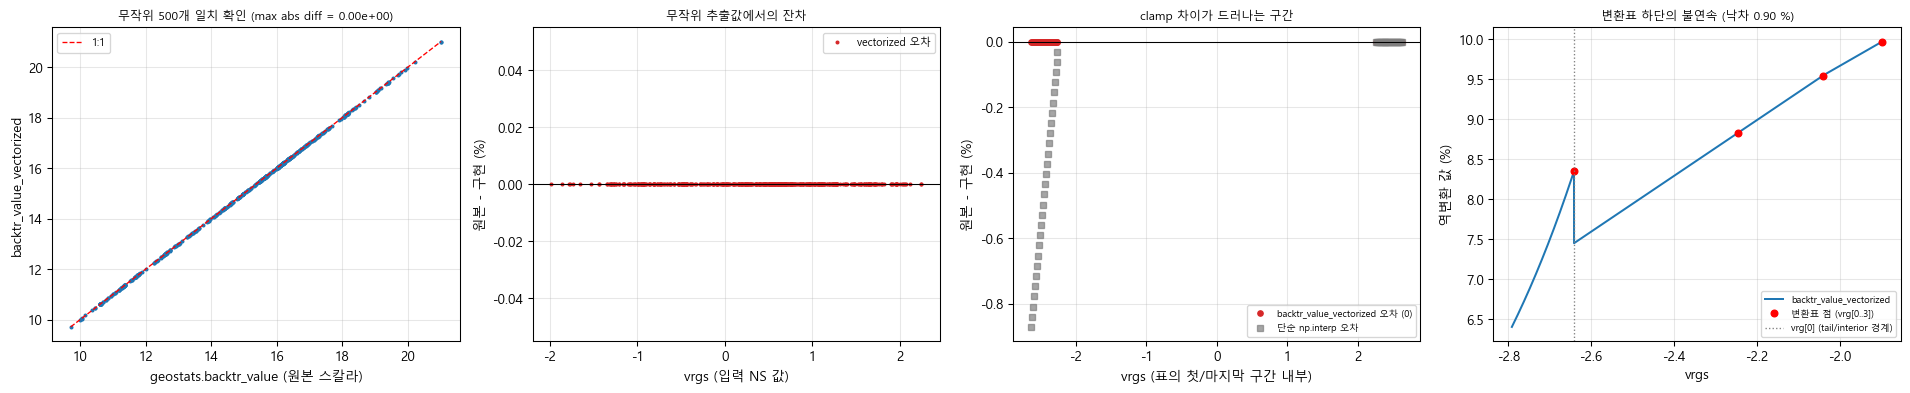

In [10]:
print("검증 파라미터: BACKTR_VALIDATION_SEED=%d, N_BACKTR_VALIDATION_SAMPLES=%d"
      % (kriging_mod.BACKTR_VALIDATION_SEED, kriging_mod.N_BACKTR_VALIDATION_SAMPLES))

_rng = np.random.default_rng(kriging_mod.BACKTR_VALIDATION_SEED)
val_vals = _rng.choice(kmap_ns.ravel(), size=kriging_mod.N_BACKTR_VALIDATION_SAMPLES, replace=True)

ref = np.array([
    geostats.backtr_value(v, vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
                          kriging_mod.LTAIL, kriging_mod.LTPAR,
                          kriging_mod.UTAIL, kriging_mod.UTPAR)
    for v in val_vals
])
vec = kriging_mod.backtr_value_vectorized(
    val_vals, vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
    kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR)

max_abs_diff = float(np.max(np.abs(ref - vec)))
print("max |scalar - vectorized| = %.3e   (kriging.py 허용치: rtol=atol=1e-8)" % max_abs_diff)
print("np.allclose(rtol=1e-8, atol=1e-8) = %s" % np.allclose(ref, vec, rtol=1e-8, atol=1e-8))
print()

# --- 단순 np.interp 는 왜 안 되는가 (kriging.py docstring이 경고하는 부분) ---
naive = np.interp(val_vals, vrg, vr)
_interior = (val_vals > vrg[0]) & (val_vals < vrg[-1])
_naive_random = float(np.max(np.abs(ref[_interior] - naive[_interior]))) if _interior.any() else 0.0
print("무작위 추출값 %d개에서 단순 np.interp 와 원본의 최대 차이: %.5f"
      % (len(val_vals), _naive_random))
print("   (0 이어도 정상 — 이 값들이 전부 변환표의 '내부' 구간에 들어가면 clamp 차이가 드러나지 않는다)")
print()

# 차이가 실제로 생기는 지점을 직접 찌른다: 변환표의 첫 구간 [vrg[0], vrg[1]] 과
# 마지막 구간 [vrg[-2], vrg[-1]] 내부 값들 (dlocate가 이 두 구간을 bracket으로 고르지 못한다)
probe = np.concatenate([np.linspace(vrg[0], vrg[1], 30)[1:-1],
                        np.linspace(vrg[-2], vrg[-1], 30)[1:-1]])
probe_ref = np.array([
    geostats.backtr_value(v, vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
                          kriging_mod.LTAIL, kriging_mod.LTPAR,
                          kriging_mod.UTAIL, kriging_mod.UTPAR) for v in probe])
probe_vec = kriging_mod.backtr_value_vectorized(
    probe, vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
    kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR)
probe_naive = np.interp(probe, vrg, vr)
print("변환표의 첫/마지막 구간 내부 값 %d개로 재검증:" % len(probe))
print("   max |scalar - backtr_value_vectorized| = %.3e   <- 0 이어야 정상 (원본과 동일 동작)"
      % float(np.max(np.abs(probe_ref - probe_vec))))
print("   max |scalar - np.interp|               = %.5f   <- dlocate clamp 때문에 어긋나는 양"
      % float(np.max(np.abs(probe_ref - probe_naive))))
print()

# --- 부수적으로 드러나는 성질: 변환표 하단의 불연속 ---------------------
# 위 clamp의 직접적 귀결이다. vrgs <= vrg[0] 은 tail 분기라 vr[0]을 주는데,
# vrgs 가 vrg[0] 바로 위로 올라가면 clamp 때문에 첫 구간 [vrg[0], vrg[1]] 이 아니라
# [vrg[1], vrg[2]] 를 '뒤로' 외삽한다 -> 경계에서 값이 튄다.
fine = np.linspace(vrg[0] - 0.15, vrg[3], 6000)
fine_v = kriging_mod.backtr_value_vectorized(
    fine, vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
    kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR)
_jd = np.diff(fine_v)
_j = int(np.argmin(_jd))
print("변환표 하단(vrg[0]=%.5f) 근방 불연속 진단:" % vrg[0])
print("   vrgs=%.6f -> %.5f %% ,  vrgs=%.6f -> %.5f %%   (낙차 %.5f %%)"
      % (fine[_j], fine_v[_j], fine[_j + 1], fine_v[_j + 1], _jd[_j]))
print("   원본 스칼라 geostats.backtr_value 도 같은 값: %.5f / %.5f"
      % (geostats.backtr_value(fine[_j], vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
                               kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR),
         geostats.backtr_value(fine[_j + 1], vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
                               kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR)))
print("   -> 우리 구현의 버그가 아니라 GSLIB backtr_value 자체의 성질이다 (구현은 그걸 정확히 재현).")
print("   상단(vrg[-1]=%.5f)은 clamp 상한이 nt-2 라 마지막 구간이 그대로 쓰여 연속이다 (비대칭)." % vrg[-1])
print("   영향 범위: kmap_ns 값이 (vrg[0], vrg[1]) = (%.4f, %.4f) 안에 있는 셀 = %d / %d"
      % (vrg[0], vrg[1], int(((kmap_ns > vrg[0]) & (kmap_ns < vrg[1])).sum()), kmap_ns.size))

fig, axes = plt.subplots(1, 4, figsize=(20, 4.2))
axes[0].plot(ref, vec, ".", ms=4, color="tab:blue")
_lo, _hi = min(ref.min(), vec.min()), max(ref.max(), vec.max())
axes[0].plot([_lo, _hi], [_lo, _hi], "r--", lw=1, label="1:1")
axes[0].set_xlabel("geostats.backtr_value (원본 스칼라)")
axes[0].set_ylabel("backtr_value_vectorized")
axes[0].set_title("무작위 %d개 일치 확인 (max abs diff = %.2e)" % (len(val_vals), max_abs_diff), fontsize=9)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(val_vals, ref - vec, ".", ms=4, color="tab:red", label="vectorized 오차")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("vrgs (입력 NS 값)"); axes[1].set_ylabel("원본 - 구현 (%)")
axes[1].set_title("무작위 추출값에서의 잔차", fontsize=9)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(probe, probe_ref - probe_vec, "o", ms=4, color="tab:red",
             label="backtr_value_vectorized 오차 (0)")
axes[2].plot(probe, probe_ref - probe_naive, "s", ms=4, color="tab:gray", alpha=0.7,
             label="단순 np.interp 오차")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xlabel("vrgs (표의 첫/마지막 구간 내부)"); axes[2].set_ylabel("원본 - 구현 (%)")
axes[2].set_title("clamp 차이가 드러나는 구간", fontsize=9)
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)

axes[3].plot(fine, fine_v, "-", lw=1.5, color="tab:blue", label="backtr_value_vectorized")
axes[3].plot(vrg[:4], vr[:4], "ro", ms=5, label="변환표 점 (vrg[0..3])")
axes[3].axvline(vrg[0], color="gray", ls=":", lw=1, label="vrg[0] (tail/interior 경계)")
axes[3].set_xlabel("vrgs"); axes[3].set_ylabel("역변환 값 (%)")
axes[3].set_title("변환표 하단의 불연속 (낙차 %.2f %%)" % abs(_jd[_j]), fontsize=9)
axes[3].legend(fontsize=7); axes[3].grid(alpha=0.3)
plt.tight_layout()

## 1.5 Monte Carlo 물리단위 kriging 분산

**대응**: `kriging.py`의 Monte Carlo 블록 (`KRIGING_VAR_MC_SEED=80`, `N_MC=5000`).

셀마다 `NPor ~ N(kmap_ns[cell], sqrt(vmap_ns[cell]))`로 5000개를 뽑고, 검증된 벡터화 역변환으로
물리 단위로 보낸 뒤 **표본 분산**(ddof=1)을 취한다. 이건 **근사이고 시각화 전용**이다 —
평가 지표(UMG/CRPS)는 절대 이 배열을 쓰지 않고, NS 공간 분위수를 직접 역변환하는 경로를 쓴다.

> 이 블록도 `kriging.main()` 안에 인라인으로 있어 import가 불가능하다. 동일 상수·동일 순서로 재현했다.

MC 파라미터: KRIGING_VAR_MC_SEED=80, N_MC=5000


MC 2500 cells x 5000 draws: 2.55초



ns_draws                               shape=(2500, 5000)   min=   -4.58841  max=    5.38065  mean=    0.30645  std=   1.05381  n_nan=0


physical_draws                         shape=(2500, 5000)   min=    3.00289  max=   26.99996  mean=   14.93475  std=   2.88982  n_nan=0
kriging_var_map_physical_mc            shape=(50, 50)       min=    0.00000  max=    9.81694  mean=    2.90064  std=   1.80821  n_nan=0

vmap_ns 음수 셀 개수(roundoff) : 59, 최솟값 -2.480e-15 -> sqrt 전에 0으로 clip

예시 셀 (vmap_ns 최대): row=0 col=49  X=990.0 Y=990.0
   kmap_ns=-0.2531, std_ns=0.9594 -> 물리 단위 MC 분산=6.2552 (표준편차 2.5010 %)


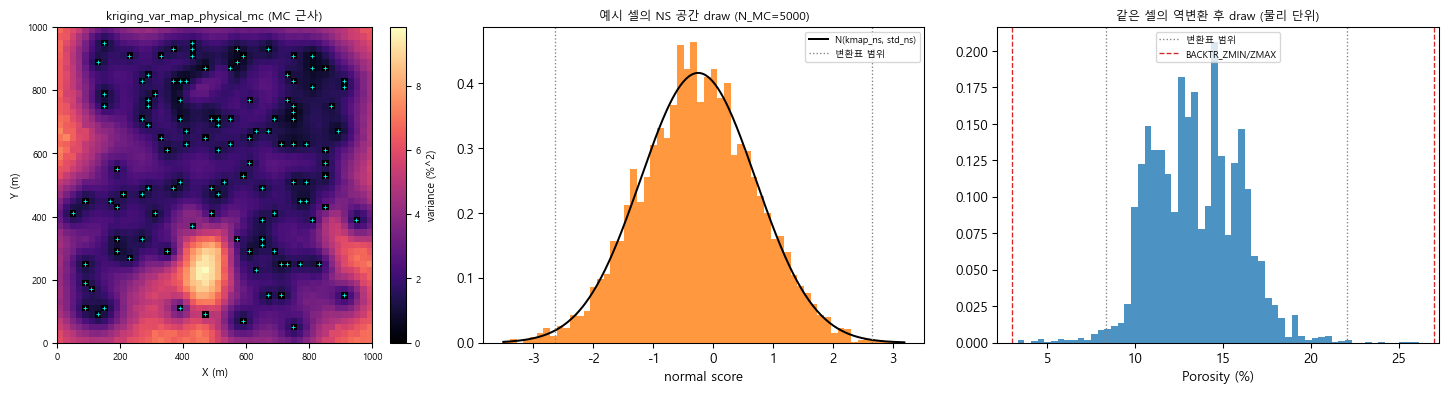

In [11]:
print("MC 파라미터: KRIGING_VAR_MC_SEED=%d, N_MC=%d"
      % (kriging_mod.KRIGING_VAR_MC_SEED, kriging_mod.N_MC))

t0 = time.time()
std_ns_flat = np.sqrt(np.clip(vmap_ns, 0.0, None)).ravel()
kmap_ns_flat = kmap_ns.ravel()
n_cells = kmap_ns_flat.shape[0]

mc_rng = np.random.default_rng(kriging_mod.KRIGING_VAR_MC_SEED)
ns_draws = mc_rng.normal(loc=kmap_ns_flat[:, None], scale=std_ns_flat[:, None],
                         size=(n_cells, kriging_mod.N_MC))
physical_draws = kriging_mod.backtr_value_vectorized(
    ns_draws, vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
    kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR)
kriging_var_map_physical_mc = physical_draws.var(axis=1, ddof=1).reshape(NY, NX)
print("MC %d cells x %d draws: %.2f초" % (n_cells, kriging_mod.N_MC, time.time() - t0))
print()
describe("ns_draws", ns_draws)
describe("physical_draws", physical_draws)
describe("kriging_var_map_physical_mc", kriging_var_map_physical_mc)
print()
print("vmap_ns 음수 셀 개수(roundoff) : %d, 최솟값 %.3e -> sqrt 전에 0으로 clip"
      % (int((vmap_ns < 0).sum()), vmap_ns.min()))

# 변환표 밖으로 나가는 draw 비율 (§1.6 tail 진단에서 재사용)
frac_outside = ((physical_draws < vr[0]) | (physical_draws > vr[-1])).mean(axis=1).reshape(NY, NX)

# 예시 셀: kriging 분산이 가장 큰 셀 (= 샘플에서 가장 멀리 떨어진 쪽)
demo_mc_cell = int(np.argmax(vmap_ns))
_r, _c = np.unravel_index(demo_mc_cell, (NY, NX))
print()
print("예시 셀 (vmap_ns 최대): row=%d col=%d  X=%.1f Y=%.1f" % (_r, _c, XMN + _c * XSIZ, YMN + (NY - 1 - _r) * YSIZ))
print("   kmap_ns=%.4f, std_ns=%.4f -> 물리 단위 MC 분산=%.4f (표준편차 %.4f %%)"
      % (kmap_ns_flat[demo_mc_cell], std_ns_flat[demo_mc_cell],
         kriging_var_map_physical_mc[_r, _c], np.sqrt(kriging_var_map_physical_mc[_r, _c])))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
show_map(axes[0], kriging_var_map_physical_mc,
         "kriging_var_map_physical_mc (MC 근사)", "variance (%^2)", cmap="magma",
         samples=samples_df, sample_color="cyan")
axes[1].hist(ns_draws[demo_mc_cell], bins=60, density=True, color="tab:orange", alpha=0.8)
_xs = np.linspace(ns_draws[demo_mc_cell].min(), ns_draws[demo_mc_cell].max(), 300)
axes[1].plot(_xs, norm.pdf(_xs, kmap_ns_flat[demo_mc_cell], std_ns_flat[demo_mc_cell]),
             "k-", lw=1.5, label="N(kmap_ns, std_ns)")
axes[1].axvline(vrg[0], color="gray", ls=":", lw=1)
axes[1].axvline(vrg[-1], color="gray", ls=":", lw=1, label="변환표 범위")
axes[1].set_title("예시 셀의 NS 공간 draw (N_MC=%d)" % kriging_mod.N_MC, fontsize=9)
axes[1].set_xlabel("normal score"); axes[1].legend(fontsize=7)
axes[2].hist(physical_draws[demo_mc_cell], bins=60, density=True, color="tab:blue", alpha=0.8)
axes[2].axvline(vr[0], color="gray", ls=":", lw=1)
axes[2].axvline(vr[-1], color="gray", ls=":", lw=1, label="변환표 범위")
axes[2].axvline(kriging_mod.BACKTR_ZMIN, color="tab:red", ls="--", lw=1)
axes[2].axvline(kriging_mod.BACKTR_ZMAX, color="tab:red", ls="--", lw=1, label="BACKTR_ZMIN/ZMAX")
axes[2].set_title("같은 셀의 역변환 후 draw (물리 단위)", fontsize=9)
axes[2].set_xlabel("Porosity (%)"); axes[2].legend(fontsize=7)
plt.tight_layout()

## 1.6 Tail 외삽 진단

변환표(`vr`/`vrg`)는 **샘플 121개로만** 만들어진다. 그 범위 밖의 정규점수는 `LTAIL=UTAIL=1`
(선형 외삽)으로 `BACKTR_ZMIN/ZMAX`를 향해 뻗는다. 어느 셀이 표 범위를 벗어나는지 확인한다.

- 왼쪽: **point estimate `kmap_ns`** 자체가 표 밖인 셀
- 오른쪽: 그 셀의 **MC draw 중 표 밖으로 나간 비율** — UMG/CRPS의 극단 분위수가 실제로
  tail 외삽에 얼마나 의존하는지 보여준다 (CRPS는 τ≈0.0025/0.9975까지 건드린다)

변환표 NS 범위: [-2.6411, 2.6411]  (물리 [8.3513, 22.0693])
point estimate가 lower tail 밖인 셀: 0 / 2500 (0.00%)
point estimate가 upper tail 밖인 셀: 0 / 2500 (0.00%)

MC draw 중 표 밖 비율 (셀별)                  shape=(50, 50)       min=    0.00000  max=    1.00000  mean=    0.01538  std=   0.04292  n_nan=0
표 밖 draw 비율이 10% 넘는 셀: 109 / 2500


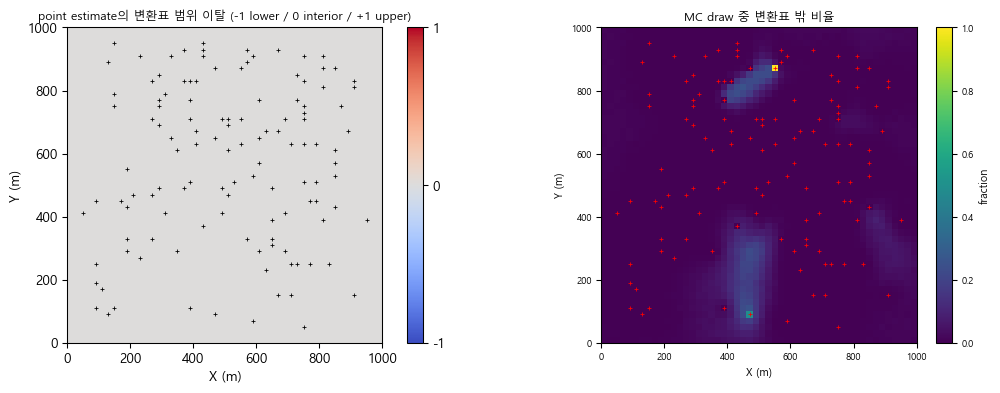

In [12]:
tail_code = np.zeros((NY, NX))
tail_code[kmap_ns < vrg[0]] = -1.0
tail_code[kmap_ns > vrg[-1]] = 1.0

n_lo = int((tail_code < 0).sum()); n_hi = int((tail_code > 0).sum())
print("변환표 NS 범위: [%.4f, %.4f]  (물리 [%.4f, %.4f])" % (vrg[0], vrg[-1], vr[0], vr[-1]))
print("point estimate가 lower tail 밖인 셀: %d / %d (%.2f%%)" % (n_lo, NX * NY, 100.0 * n_lo / (NX * NY)))
print("point estimate가 upper tail 밖인 셀: %d / %d (%.2f%%)" % (n_hi, NX * NY, 100.0 * n_hi / (NX * NY)))
print()
describe("MC draw 중 표 밖 비율 (셀별)", frac_outside)
print("표 밖 draw 비율이 10%% 넘는 셀: %d / %d" % (int((frac_outside > 0.10).sum()), NX * NY))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
im = axes[0].imshow(tail_code, extent=[XMIN, XMAX, YMIN, YMAX], origin="upper",
                    cmap="coolwarm", vmin=-1, vmax=1)
axes[0].scatter(samples_df["X"], samples_df["Y"], s=7, c="k", marker="+", linewidths=0.6)
axes[0].set_title("point estimate의 변환표 범위 이탈 (-1 lower / 0 interior / +1 upper)", fontsize=9)
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
plt.colorbar(im, ax=axes[0], fraction=0.046, ticks=[-1, 0, 1])
show_map(axes[1], frac_outside, "MC draw 중 변환표 밖 비율", "fraction",
         cmap="viridis", samples=samples_df, sample_color="red")
plt.tight_layout()

del ns_draws, physical_draws  # 메모리 정리 (각 ~100MB)

---
# 2. SGS — `src/experiments/sgs.py`

파이프라인:

1. 공통 조건화 데이터 (§0)
2. **jitter**: `sgsim` 호출용 DataFrame *사본*의 X/Y에만 ±1e-2 m 교란
3. `geostats.sgsim(itrans=1, ktype=0, nsim=N_REALIZATIONS)` — sgsim이 내부에서 정규점수 변환/역변환을
   모두 처리하므로 **수동으로 미리 nscore를 적용하지 않는다** (이중 변환 금지)
4. **post-hoc honor 재적용**: 샘플 셀 값을 원본 값으로 강제 덮어쓰기
5. 셀별 앙상블 mean/var

## 2.1 Jitter 적용 전/후

**대응**: `sgs.py`의 `SGS_JITTER_*` 블록.

**왜 필요한가**: 샘플 좌표가 그리드 셀 중심에 **정확히** 얹혀 있으면 `sgsim` 내부 simple-kriging
행렬이 특이(singular)해져 `LinAlgError`가 나거나, 그보다 흔하게는 near-singular 해가 나와
조건부 평균이 ~1e21 같은 말도 안 되는 값이 된다.

**부작용**: `sgsim` 내부의 자체 honor 재할당은 `|dx|+|dy| <= TINY(=1e-4 m)`일 때만 발동하는데
jitter가 그보다 100배 크므로 **honor가 조용히 실패한다**. 그래서 §2.4의 post-hoc 재적용이 붙어 있다.

In [13]:
print("SGS_JITTER_SEED=%d, SGS_JITTER_MAGNITUDE=%g m" % (sgs_mod.SGS_JITTER_SEED, sgs_mod.SGS_JITTER_MAGNITUDE))
print("   셀 크기 대비 : %.2e   (XSIZ=%g m)" % (sgs_mod.SGS_JITTER_MAGNITUDE / XSIZ, XSIZ))
print("   range 대비   : %.2e   (range=%g m)" % (sgs_mod.SGS_JITTER_MAGNITUDE / RANGE, RANGE))
print("   sgsim 내부 honor 임계값 TINY=1e-4 m 대비: %.0f배" % (sgs_mod.SGS_JITTER_MAGNITUDE / 1e-4))
print()

jitter_rng = np.random.RandomState(sgs_mod.SGS_JITTER_SEED)
sgsim_input_df = samples_df.copy()
sgsim_input_df["X"] = sgsim_input_df["X"] + jitter_rng.uniform(
    -sgs_mod.SGS_JITTER_MAGNITUDE, sgs_mod.SGS_JITTER_MAGNITUDE, size=n_actual_samples)
sgsim_input_df["Y"] = sgsim_input_df["Y"] + jitter_rng.uniform(
    -sgs_mod.SGS_JITTER_MAGNITUDE, sgs_mod.SGS_JITTER_MAGNITUDE, size=n_actual_samples)

dx = sgsim_input_df["X"].values - samples_df["X"].values
dy = sgsim_input_df["Y"].values - samples_df["Y"].values
print("dX: min=%.5f max=%.5f  |dX| 최대=%.5f m" % (dx.min(), dx.max(), np.abs(dx).max()))
print("dY: min=%.5f max=%.5f  |dY| 최대=%.5f m" % (dy.min(), dy.max(), np.abs(dy).max()))
print("|dX|+|dY| > TINY(1e-4) 인 샘플: %d / %d  <- sgsim 자체 honor가 실패하는 샘플 수"
      % (int(((np.abs(dx) + np.abs(dy)) > 1e-4).sum()), n_actual_samples))
print()
print("samples_df 원본은 손대지 않는다 (4개 방법 공통 좌표):")
print(pd.DataFrame({"X_원본": samples_df["X"].values[:5], "X_jitter": sgsim_input_df["X"].values[:5],
                    "dX": dx[:5], "Y_원본": samples_df["Y"].values[:5],
                    "Y_jitter": sgsim_input_df["Y"].values[:5], "dY": dy[:5]}).to_string(index=False))

SGS_JITTER_SEED=70, SGS_JITTER_MAGNITUDE=0.01 m
   셀 크기 대비 : 5.00e-04   (XSIZ=20 m)
   range 대비   : 3.33e-05   (range=300 m)
   sgsim 내부 honor 임계값 TINY=1e-4 m 대비: 100배

dX: min=-0.00990 max=0.00984  |dX| 최대=0.00990 m
dY: min=-0.00999 max=0.00995  |dY| 최대=0.00999 m
|dX|+|dY| > TINY(1e-4) 인 샘플: 121 / 121  <- sgsim 자체 honor가 실패하는 샘플 수

samples_df 원본은 손대지 않는다 (4개 방법 공통 좌표):
 X_원본   X_jitter        dX  Y_원본   Y_jitter        dY
570.0 570.008550  0.008550 930.0 929.996930 -0.003070
850.0 850.007449  0.007449 870.0 870.006186  0.006186
850.0 850.001693  0.001693 570.0 570.004846  0.004846
790.0 790.008103  0.008103 450.0 450.008596  0.008596
 90.0  89.996337 -0.003663 450.0 449.990812 -0.009188


## 2.2 `geostats.sgsim` 호출

**대응**: `sgs.py` 3단계. 상수 전부 `sgs_mod`에서 가져온다
(`N_REALIZATIONS = rbf_bootstrap.N_BOOTSTRAP = 10` — 방법 간 replicate 수 일치 요구사항).

**이 셀이 가장 오래 걸린다 (40~75초).** sgsim이 realization마다 진행 상황을 출력한다.

> `sgsim` 호출 블록도 `sgs.main()` 안에 인라인이다. 동일 인자로 호출만 재현했다.

In [14]:
print("sgsim 파라미터 (src/experiments/sgs.py):")
for _n in ["N_REALIZATIONS", "SGS_SEED", "NDMIN", "NDMAX", "NODMAX", "MULTS", "NMULT",
           "NOCT", "KTYPE", "COLOCORR", "SGSIM_ZMIN", "SGSIM_ZMAX",
           "SGSIM_LTAIL", "SGSIM_UTAIL"]:
    print("   %-15s = %s" % (_n, getattr(sgs_mod, _n)))
print("   itrans=1 -> sgsim이 내부에서 nscore 변환/역변환을 전부 수행 (수동 이중 변환 금지)")
print()

t0 = time.time()
sim = geostats.sgsim(
    sgsim_input_df, "X", "Y", VCOL,
    wcol=-1, scol=-1, tmin=-9999, tmax=9999,
    itrans=1, ismooth=0, dftrans=0, tcol=0, twtcol=0,
    zmin=sgs_mod.SGSIM_ZMIN, zmax=sgs_mod.SGSIM_ZMAX,
    ltail=sgs_mod.SGSIM_LTAIL, ltpar=sgs_mod.SGSIM_LTPAR,
    utail=sgs_mod.SGSIM_UTAIL, utpar=sgs_mod.SGSIM_UTPAR,
    nsim=sgs_mod.N_REALIZATIONS,
    nx=NX, xmn=XMN, xsiz=XSIZ, ny=NY, ymn=YMN, ysiz=YSIZ,
    seed=sgs_mod.SGS_SEED,
    ndmin=sgs_mod.NDMIN, ndmax=sgs_mod.NDMAX, nodmax=sgs_mod.NODMAX,
    mults=sgs_mod.MULTS, nmult=sgs_mod.NMULT, noct=sgs_mod.NOCT,
    ktype=sgs_mod.KTYPE, colocorr=sgs_mod.COLOCORR, sec_map=sgs_mod.SEC_MAP,
    vario=vario,
)
sgsim_seconds = time.time() - t0

realizations = np.stack([sim[r] for r in range(sgs_mod.N_REALIZATIONS)], axis=0)
print()
print("sgsim 소요: %.1f초 (%d realization)" % (sgsim_seconds, sgs_mod.N_REALIZATIONS))
describe("realizations (물리 단위, 이미 역변환됨)", realizations)
print("shape = (n_real, NY, NX) = %s" % (realizations.shape,))

sgsim 파라미터 (src/experiments/sgs.py):
   N_REALIZATIONS  = 10
   SGS_SEED        = 60
   NDMIN           = 0
   NDMAX           = 20
   NODMAX          = 20
   MULTS           = 1
   NMULT           = 3
   NOCT            = -1
   KTYPE           = 0
   COLOCORR        = 0.0
   SGSIM_ZMIN      = 3.0
   SGSIM_ZMAX      = 27.0
   SGSIM_LTAIL     = 1
   SGSIM_UTAIL     = 1
   itrans=1 -> sgsim이 내부에서 nscore 변환/역변환을 전부 수행 (수동 이중 변환 금지)


 Data for SGSIM: Number of acceptable data     = 121
                 Number trimmed                = 0
                 Weighted Average              = 14.1036
                 Weighted Variance             = 6.7692
                 Weighted Transformed Average  = -0.0
                 Weighted Transformed Variance = 0.9895
Setting up rotation matrices for variogram and search
Working on realization number 0
   currently on node 0


   currently on node 250


   currently on node 500


   currently on node 750


   currently on node 1000


...

   currently on node 1500


   currently on node 1750


   currently on node 2000


   currently on node 2250


Reassigning data to nodes

 Realization 9: number   = 2500
                                   mean     = 0.3692 (close to 0.0?)
                                   variance = 1.1203 (close to gammabar(V,V)? approx. 1.0)

sgsim 소요: 78.6초 (10 realization)
realizations (물리 단위, 이미 역변환됨)          shape=(10, 50, 50)   min=    3.75084  max=   26.75182  mean=   14.87630  std=   2.79609  n_nan=0
shape = (n_real, NY, NX) = (10, 50, 50)


## 2.3 Realization 그리드 plot

realization별 평균/표준편차 (honor 재적용 전):
   real  0: mean=14.6415  stdev= 2.6586  min=  7.163  max= 26.384
   real  1: mean=14.7673  stdev= 2.6612  min=  7.580  max= 26.139
   real  2: mean=14.9688  stdev= 2.6914  min=  5.245  max= 26.294
   real  3: mean=14.6998  stdev= 2.6400  min=  3.751  max= 26.407
   real  4: mean=14.9948  stdev= 2.7674  min=  4.912  max= 26.686
   real  5: mean=14.8017  stdev= 2.9005  min=  4.020  max= 26.028
   real  6: mean=15.0831  stdev= 3.1468  min=  5.480  max= 26.743
   real  7: mean=14.7295  stdev= 2.7838  min=  6.249  max= 26.685
   real  8: mean=14.9918  stdev= 2.7401  min=  7.713  max= 26.752
   real  9: mean=15.0847  stdev= 2.8877  min=  5.974  max= 26.346


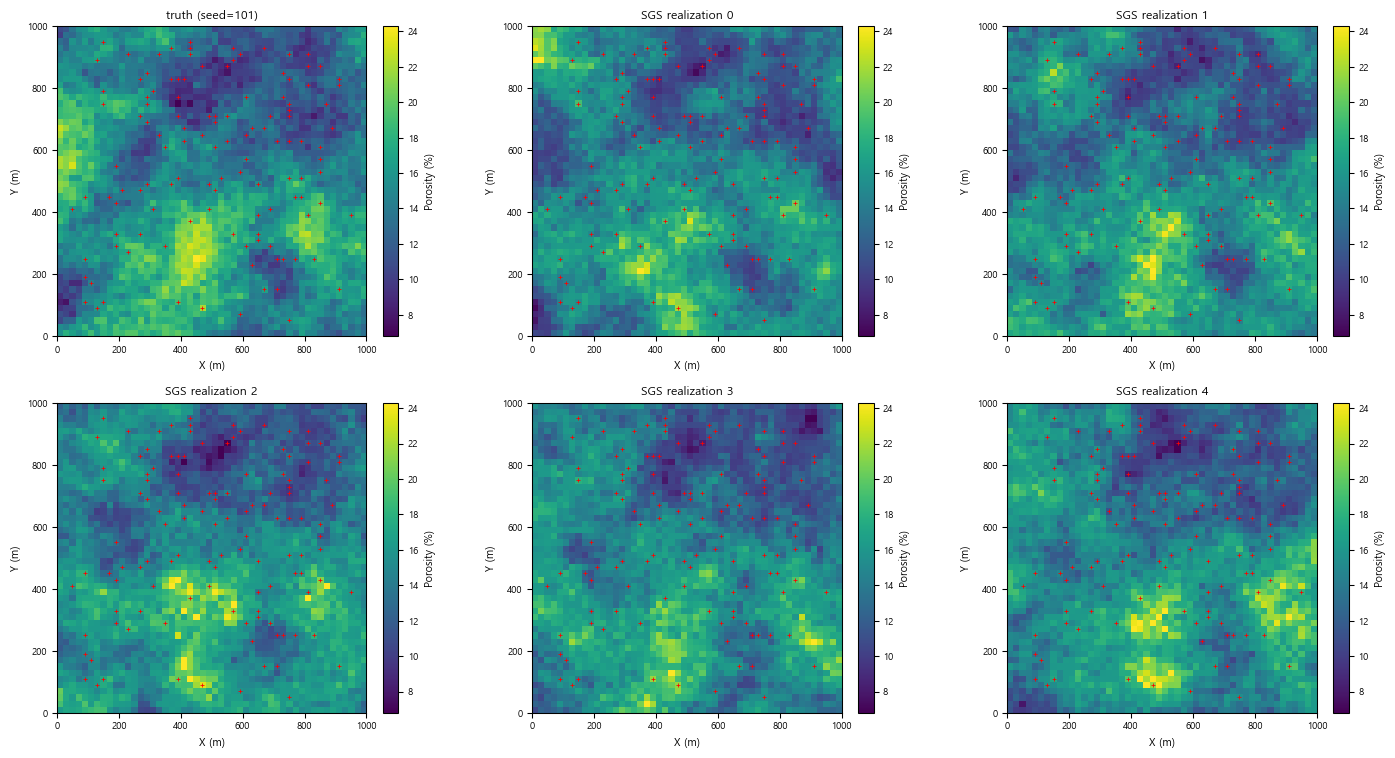

In [15]:
_vmin, _vmax = float(truth.min()), float(truth.max())
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
show_map(axes[0, 0], truth, "truth (seed=%d)" % TRUTH_SEED, "Porosity (%)",
         vmin=_vmin, vmax=_vmax, samples=samples_df)
for i, r in enumerate([0, 1, 2, 3, 4]):
    ax = axes.ravel()[i + 1]
    show_map(ax, realizations[r], "SGS realization %d" % r, "Porosity (%)",
             vmin=_vmin, vmax=_vmax, samples=samples_df)
plt.tight_layout()

print("realization별 평균/표준편차 (honor 재적용 전):")
for r in range(sgs_mod.N_REALIZATIONS):
    print("   real %2d: mean=%7.4f  stdev=%7.4f  min=%7.3f  max=%7.3f"
          % (r, realizations[r].mean(), realizations[r].std(),
             realizations[r].min(), realizations[r].max()))

## 2.4 Honor 검증 — post-hoc 재적용 전/후

**대응**: `sgs.py`의 QC 1a / honor re-enforcement / QC 1b 블록.

§2.1에서 설명한 대로, jitter가 sgsim의 `TINY=1e-4 m` 임계값보다 100배 커서 sgsim 자체 honor가
발동하지 않는다. 그래서 **sgsim이 돌려준 원본 출력의 honor 오차**를 먼저 기록하고(감사 가능성 유지),
그 다음 샘플 셀 값을 원본 값으로 덮어쓴다.

QC 1a — sgsim 원본 출력 (재적용 전):
   max_abs_error  = 3.963177  (porosity %)
   mean_abs_error = 0.639551
   오차 > 0.01 인 (realization, sample) 쌍: 1186 / 1210
   참고: 샘플값 표준편차 = 2.6126 -> 최대 오차는 약 1.52 sigma

QC 1b — post-hoc 재적용 후:
   max_abs_error  = 0.000000e+00
   mean_abs_error = 0.000000e+00
   (구성상 정확히 0이어야 한다. 0이 아니면 인덱싱 실수)


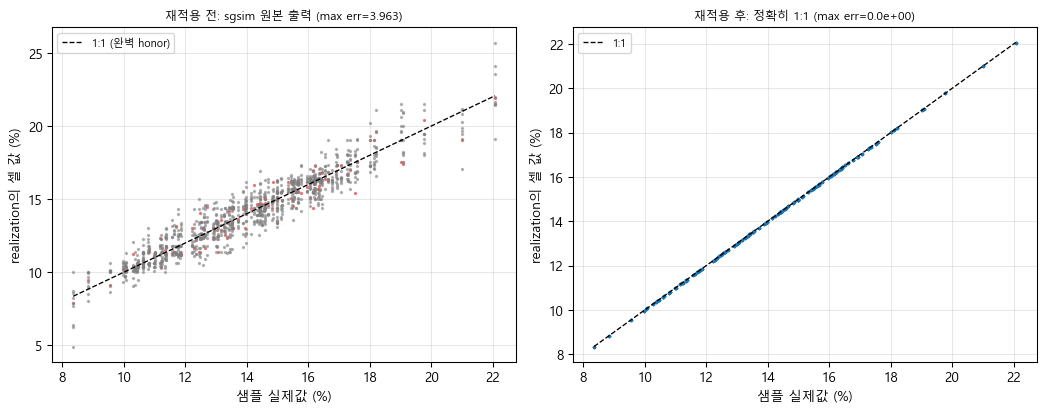

In [16]:
# 샘플 -> 그리드 셀 인덱스 (sgs.py 와 동일한 반올림/행 뒤집기 규약)
sample_ix = np.round((samples_df["X"].values - XMN) / XSIZ).astype(int)
sample_iy = np.round((samples_df["Y"].values - YMN) / YSIZ).astype(int)
sample_row = NY - 1 - sample_iy
sample_col = sample_ix

honor_raw = np.abs(realizations[:, sample_row, sample_col] - samples_df[VCOL].values[None, :])
honor_raw_max, honor_raw_mean = float(honor_raw.max()), float(honor_raw.mean())
raw_at_samples = realizations[:, sample_row, sample_col].copy()

print("QC 1a — sgsim 원본 출력 (재적용 전):")
print("   max_abs_error  = %.6f  (porosity %%)" % honor_raw_max)
print("   mean_abs_error = %.6f" % honor_raw_mean)
print("   오차 > 0.01 인 (realization, sample) 쌍: %d / %d"
      % (int((honor_raw > 0.01).sum()), honor_raw.size))
print("   참고: 샘플값 표준편차 = %.4f -> 최대 오차는 약 %.2f sigma"
      % (samples_df[VCOL].std(), honor_raw_max / samples_df[VCOL].std()))
print()

# post-hoc honor 재적용 (sgs.py: APPLY_HONOR_REENFORCEMENT=True)
if sgs_mod.APPLY_HONOR_REENFORCEMENT:
    realizations[:, sample_row, sample_col] = samples_df[VCOL].values[None, :]

honor_post = np.abs(realizations[:, sample_row, sample_col] - samples_df[VCOL].values[None, :])
print("QC 1b — post-hoc 재적용 후:")
print("   max_abs_error  = %.6e" % float(honor_post.max()))
print("   mean_abs_error = %.6e" % float(honor_post.mean()))
print("   (구성상 정확히 0이어야 한다. 0이 아니면 인덱싱 실수)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
_t = samples_df[VCOL].values
for r in range(sgs_mod.N_REALIZATIONS):
    axes[0].plot(_t, raw_at_samples[r], ".", ms=3, alpha=0.5,
                 color="tab:red" if r == 0 else "tab:gray")
axes[0].plot([_t.min(), _t.max()], [_t.min(), _t.max()], "k--", lw=1, label="1:1 (완벽 honor)")
axes[0].set_xlabel("샘플 실제값 (%)"); axes[0].set_ylabel("realization의 셀 값 (%)")
axes[0].set_title("재적용 전: sgsim 원본 출력 (max err=%.3f)" % honor_raw_max, fontsize=9)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for r in range(sgs_mod.N_REALIZATIONS):
    axes[1].plot(_t, realizations[r, sample_row, sample_col], ".", ms=3, alpha=0.5, color="tab:blue")
axes[1].plot([_t.min(), _t.max()], [_t.min(), _t.max()], "k--", lw=1, label="1:1")
axes[1].set_xlabel("샘플 실제값 (%)"); axes[1].set_ylabel("realization의 셀 값 (%)")
axes[1].set_title("재적용 후: 정확히 1:1 (max err=%.1e)" % float(honor_post.max()), fontsize=9)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()

## 2.5 앙상블 mean / var

**대응**: `sgs.py` 4단계. 이 두 배열이 SGS의 point estimate와 불확실성 모델이다
(물리 단위 realization들의 모멘트이므로 kriging처럼 역변환 문제가 없다).

sgs_mean_map                           shape=(50, 50)       min=    8.35131  max=   22.23181  mean=   14.87535  std=   2.30000  n_nan=0
sgs_var_map                            shape=(50, 50)       min=    0.00000  max=   18.10317  mean=    2.79754  std=   2.34426  n_nan=0

샘플 셀에서의 분산 (honor 재적용 때문에 정확히 0이어야 함): max=1.402e-29
비샘플 셀 분산 중앙값 = 2.3222 %^2  (표준편차 1.5239 %)
참고: 전역 분산(sill) = stdev^2 = 9.0 %^2


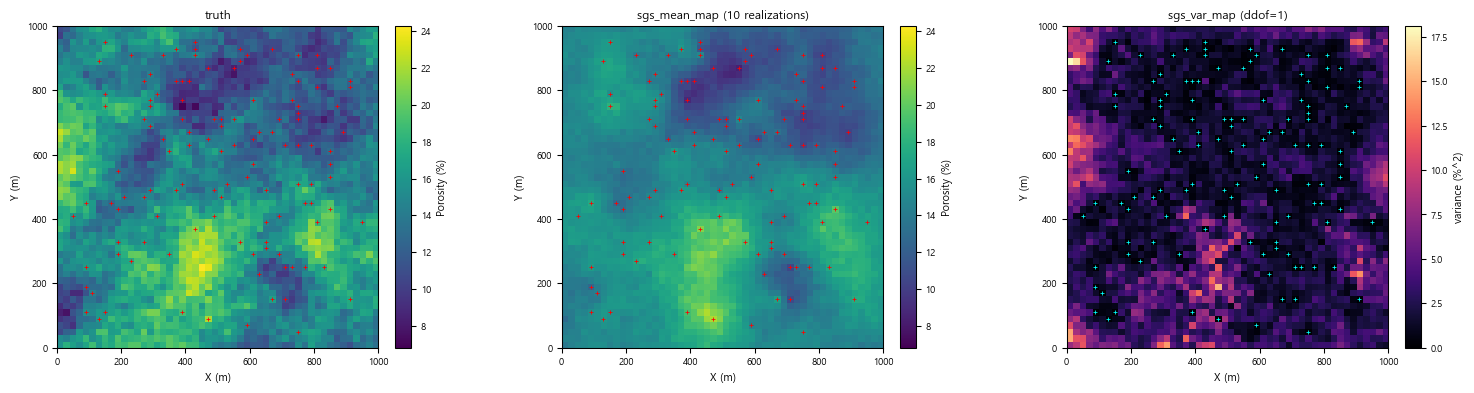

In [17]:
sgs_mean_map = realizations.mean(axis=0)
sgs_var_map = realizations.var(axis=0, ddof=1)

describe("sgs_mean_map", sgs_mean_map)
describe("sgs_var_map", sgs_var_map)
print()
print("샘플 셀에서의 분산 (honor 재적용 때문에 정확히 0이어야 함): max=%.3e"
      % float(sgs_var_map[sample_row, sample_col].max()))
print("비샘플 셀 분산 중앙값 = %.4f %%^2  (표준편차 %.4f %%)"
      % (np.median(np.delete(sgs_var_map.ravel(), sample_row * NX + sample_col)),
         np.sqrt(np.median(np.delete(sgs_var_map.ravel(), sample_row * NX + sample_col)))))
print("참고: 전역 분산(sill) = stdev^2 = %.1f %%^2" % POR_STDEV ** 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
show_map(axes[0], truth, "truth", "Porosity (%)", vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[1], sgs_mean_map, "sgs_mean_map (%d realizations)" % sgs_mod.N_REALIZATIONS,
         "Porosity (%)", vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[2], sgs_var_map, "sgs_var_map (ddof=1)", "variance (%^2)",
         cmap="magma", samples=samples_df, sample_color="cyan")
plt.tight_layout()

## 2.6 Realization별 QC — 히스토그램 재현 / variogram 구조 보존

**대응**: `sgs.py`의 QC 2 (histogram) / QC 3 (`geostats.gamv`).

`docs/geostatspy_conventions.md` 5절 QC 체크리스트의 (2) 원본 히스토그램 재현,
(3) variogram 구조 보존에 해당한다. ((1) honor는 §2.4에서 확인)

QC 2 — 히스토그램 재현 (목표 mean=15.0, stdev=3.0):
   real  0: mean=14.6407  stdev= 2.6597
   real  1: mean=14.7674  stdev= 2.6654
   real  2: mean=14.9624  stdev= 2.6851
   real  3: mean=14.7038  stdev= 2.6426
   real  4: mean=14.9912  stdev= 2.7633
   real  5: mean=14.8029  stdev= 2.8947
   real  6: mean=15.0820  stdev= 3.1386
   real  7: mean=14.7333  stdev= 2.7814
   real  8: mean=14.9892  stdev= 2.7428
   real  9: mean=15.0806  stdev= 2.8881
   앙상블 평균의 평균=14.8753, 표준편차의 평균=2.7862

QC 3 — realization 0 의 실험적 variogram (geostats.gamv)
   lag_dist=40, lag_tol=20, nlag=15, azi=0, atol=90, isill=1


   gamv 소요 1.1초, 최대 lag=559m, 총 pair=7736520


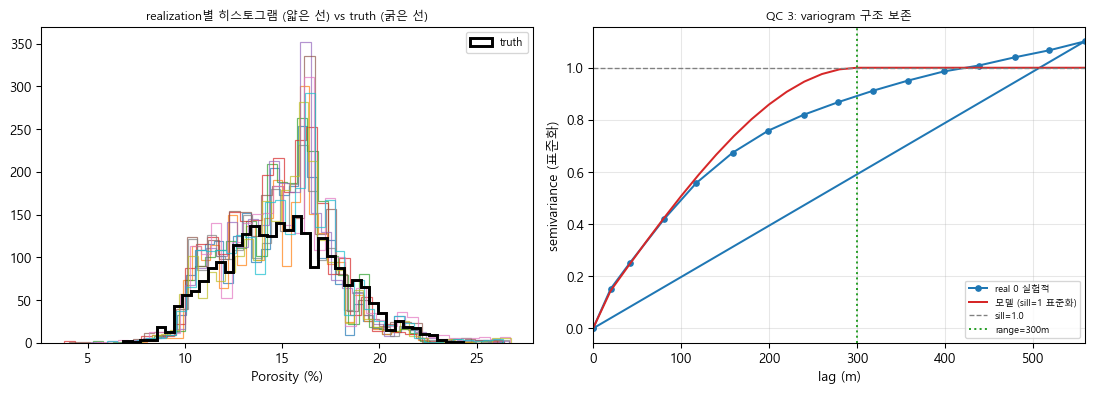

In [18]:
real_means = realizations.reshape(sgs_mod.N_REALIZATIONS, -1).mean(axis=1)
real_stdevs = realizations.reshape(sgs_mod.N_REALIZATIONS, -1).std(axis=1)
print("QC 2 — 히스토그램 재현 (목표 mean=%.1f, stdev=%.1f):" % (POR_MEAN, POR_STDEV))
for r in range(sgs_mod.N_REALIZATIONS):
    print("   real %2d: mean=%7.4f  stdev=%7.4f" % (r, real_means[r], real_stdevs[r]))
print("   앙상블 평균의 평균=%.4f, 표준편차의 평균=%.4f" % (real_means.mean(), real_stdevs.mean()))
print()

print("QC 3 — realization %d 의 실험적 variogram (geostats.gamv)" % sgs_mod.QC_REALIZATION_INDEX)
print("   lag_dist=%g, lag_tol=%g, nlag=%d, azi=%g, atol=%g, isill=%d"
      % (sgs_mod.QC_LAG_DIST, sgs_mod.QC_LAG_TOL, sgs_mod.QC_NLAG,
         sgs_mod.QC_AZI, sgs_mod.QC_ATOL, sgs_mod.QC_ISILL))

qc_real = realizations[sgs_mod.QC_REALIZATION_INDEX]
_ny_idx, _nx_idx = np.meshgrid(np.arange(NY), np.arange(NX), indexing="ij")
qc_row, qc_col = _ny_idx.ravel(), _nx_idx.ravel()
qc_df = pd.DataFrame({"X": XMN + qc_col * XSIZ,
                      "Y": YMN + (NY - 1 - qc_row) * YSIZ,
                      VCOL: qc_real[qc_row, qc_col]})
t0 = time.time()
qc_lag, qc_gamma, qc_npair = geostats.gamv(
    qc_df, "X", "Y", VCOL, -9999, 9999, sgs_mod.QC_LAG_DIST, sgs_mod.QC_LAG_TOL,
    sgs_mod.QC_NLAG, sgs_mod.QC_AZI, sgs_mod.QC_ATOL, sgs_mod.QC_BANDH, sgs_mod.QC_ISILL)
print("   gamv 소요 %.1f초, 최대 lag=%.0fm, 총 pair=%d" % (time.time() - t0, qc_lag.max(), int(np.sum(qc_npair))))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for r in range(sgs_mod.N_REALIZATIONS):
    axes[0].hist(realizations[r].ravel(), bins=40, histtype="step", lw=0.9, alpha=0.7)
axes[0].hist(truth.ravel(), bins=40, histtype="step", lw=2.2, color="k", label="truth")
axes[0].set_title("realization별 히스토그램 (얇은 선) vs truth (굵은 선)", fontsize=9)
axes[0].set_xlabel("Porosity (%)"); axes[0].legend(fontsize=8)

axes[1].plot(qc_lag, qc_gamma, "o-", ms=4, color="tab:blue",
             label="real %d 실험적" % sgs_mod.QC_REALIZATION_INDEX)
axes[1].plot(_h, _gam, "-", color="tab:red", lw=1.5, label="모델 (sill=1 표준화)")
axes[1].axhline(1.0, color="gray", ls="--", lw=1, label="sill=1.0")
axes[1].axvline(RANGE, color="tab:green", ls=":", lw=1.5, label="range=%gm" % RANGE)
axes[1].set_xlim(0, qc_lag.max())
axes[1].set_xlabel("lag (m)"); axes[1].set_ylabel("semivariance (표준화)")
axes[1].set_title("QC 3: variogram 구조 보존", fontsize=9)
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout()

---
# 3. RBF + bootstrap — `src/experiments/rbf_bootstrap.py`

파이프라인:

1. 공통 조건화 데이터 (§0)
2. **CV-MSE 그리드 서치**로 ε(shape)와 λ(smoothing) 자동 튜닝 — `cv_mse_grid_search()` (실제 함수 호출)
3. 전체 샘플로 1회 적합 → point estimate map
4. **bootstrap**: 복원추출 resample × `N_BOOTSTRAP`회, **같은 하이퍼파라미터로** 재적합
   (replicate마다 재튜닝하지 않음 — "bootstrap은 샘플셋 변동성만 포착한다"는 Claim 1 서술과 부합하는 설계, 사용자 확정)
5. 셀별 mean/var = 이 방법의 불확실성 모델

## 3.1 CV 그리드 서치 (`rbf_bootstrap.cv_mse_grid_search`)

**대응**: `rbf_bootstrap.py` 2단계. **모듈의 실제 함수를 그대로 호출**한다
(ε 격자 9개 × λ 격자 7개 × 5-fold = 315 fit).

RBF_KERNEL      = 'gaussian'
CV_FOLDS        = 5   (KFold shuffle, CV_SEED=40)
EPSILON_GRID    = [0.001 0.003 0.01  0.02  0.03  0.05  0.1   0.3   1.   ]
SMOOTHING_GRID  = [0.e+00 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01]
탐색 조합 수     = 9 x 7 = 63



cv_mse_grid_search 소요: 3.9초
선택된 best_epsilon   = 0.01
선택된 best_smoothing = 0.1
최소 CV-MSE           = 3.21882

CV-MSE 상위(=좋은) 5개 조합:
 epsilon  smoothing   cv_mse
   0.010     0.1000 3.218816
   0.010     1.0000 3.227278
   0.003     0.1000 3.346227
   0.003     1.0000 3.532698
   0.001     0.0001 3.789433


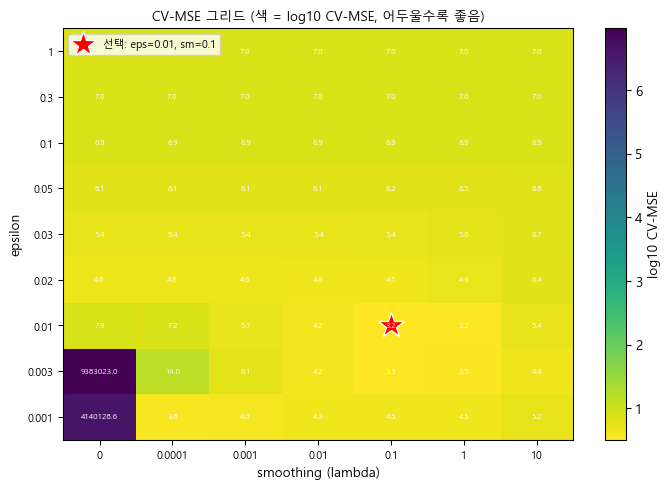

In [19]:
print("RBF_KERNEL      = %r" % rbf_mod.RBF_KERNEL)
print("CV_FOLDS        = %d   (KFold shuffle, CV_SEED=%d)" % (rbf_mod.CV_FOLDS, rbf_mod.CV_SEED))
print("EPSILON_GRID    = %s" % rbf_mod.EPSILON_GRID)
print("SMOOTHING_GRID  = %s" % rbf_mod.SMOOTHING_GRID)
print("탐색 조합 수     = %d x %d = %d" % (len(rbf_mod.EPSILON_GRID), len(rbf_mod.SMOOTHING_GRID),
                                        len(rbf_mod.EPSILON_GRID) * len(rbf_mod.SMOOTHING_GRID)))
print()

X_rbf = samples_df[["X", "Y"]].values
d_rbf = samples_df[VCOL].values

t0 = time.time()
best_epsilon, best_smoothing, cv_results_df = rbf_mod.cv_mse_grid_search(X_rbf, d_rbf)
print("cv_mse_grid_search 소요: %.1f초" % (time.time() - t0))
print("선택된 best_epsilon   = %g" % best_epsilon)
print("선택된 best_smoothing = %g" % best_smoothing)
print("최소 CV-MSE           = %.5f" % cv_results_df["cv_mse"].min())
print()
print("CV-MSE 상위(=좋은) 5개 조합:")
print(cv_results_df.nsmallest(5, "cv_mse").to_string(index=False))

pivot = cv_results_df.pivot(index="epsilon", columns="smoothing", values="cv_mse")
fig, ax = plt.subplots(figsize=(7.5, 5.2))
im = ax.imshow(np.log10(pivot.values), cmap="viridis_r", aspect="auto", origin="lower")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(["%g" % c for c in pivot.columns], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(["%g" % i for i in pivot.index], fontsize=8)
ax.set_xlabel("smoothing (lambda)"); ax.set_ylabel("epsilon")
ax.set_title("CV-MSE 그리드 (색 = log10 CV-MSE, 어두울수록 좋음)", fontsize=10)
_bi = list(pivot.index).index(best_epsilon)
_bj = list(pivot.columns).index(best_smoothing)
ax.plot(_bj, _bi, "r*", ms=20, mec="white", mew=1.0,
        label="선택: eps=%g, sm=%g" % (best_epsilon, best_smoothing))
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, "%.1f" % pivot.values[i, j], ha="center", va="center",
                fontsize=6, color="white")
ax.legend(fontsize=8, loc="upper left")
plt.colorbar(im, ax=ax, label="log10 CV-MSE")
plt.tight_layout()

## 3.2 단일 적합 (point estimate)

**대응**: `rbf_bootstrap.py` 3단계. `full_grid_coordinates()`(실제 함수)로 2500개 셀 중심 좌표를
만들고 `reshape(NY, NX)` — row 0 = max-y 규약이 여기서 보장된다.

grid_coords shape = (2500, 2)
   첫 셀 (row 0, col 0) = (10.0, 990.0)  <- y는 최댓값이어야 함 (990.0)
   마지막 셀            = (990.0, 10.0)

point_estimate_map                     shape=(50, 50)       min=    8.10071  max=   21.49077  mean=   14.84809  std=   2.25376  n_nan=0

샘플 위치에서의 적합 오차 (smoothing=0.1 이므로 정확 보간 아님): max|err|=1.8022, mean|err|=0.4457


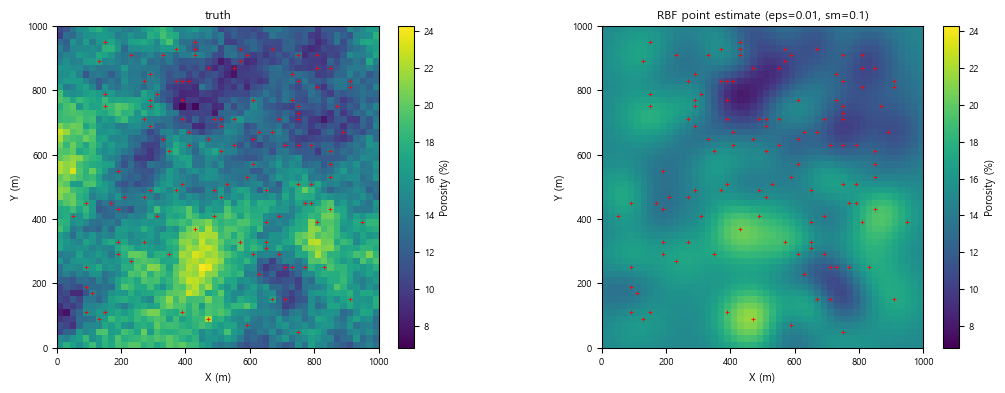

In [20]:
grid_coords = full_grid_coordinates(NX, NY, XMN, YMN, XSIZ, YSIZ)
print("grid_coords shape = %s" % (grid_coords.shape,))
print("   첫 셀 (row 0, col 0) = (%.1f, %.1f)  <- y는 최댓값이어야 함 (%.1f)"
      % (grid_coords[0, 0], grid_coords[0, 1], YMN + (NY - 1) * YSIZ))
print("   마지막 셀            = (%.1f, %.1f)" % (grid_coords[-1, 0], grid_coords[-1, 1]))
print()

rbf_point = RBFInterpolator(X_rbf, d_rbf, kernel=rbf_mod.RBF_KERNEL,
                            epsilon=best_epsilon, smoothing=best_smoothing)
point_estimate_map = rbf_point(grid_coords).reshape(NY, NX)
describe("point_estimate_map", point_estimate_map)
print()
print("샘플 위치에서의 적합 오차 (smoothing=%g 이므로 정확 보간 아님): max|err|=%.4f, mean|err|=%.4f"
      % (best_smoothing,
         np.abs(rbf_point(X_rbf) - d_rbf).max(), np.abs(rbf_point(X_rbf) - d_rbf).mean()))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
show_map(axes[0], truth, "truth", "Porosity (%)", vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[1], point_estimate_map,
         "RBF point estimate (eps=%g, sm=%g)" % (best_epsilon, best_smoothing),
         "Porosity (%)", vmin=_vmin, vmax=_vmax, samples=samples_df)
plt.tight_layout()

## 3.3 Bootstrap replicate

**대응**: `rbf_bootstrap.py` 4단계 (`BOOTSTRAP_SEED=30`, `N_BOOTSTRAP=10`).

> 이 루프는 `rbf_bootstrap.main()` 안에 인라인이라 import가 불가능하다. **동일 RNG·동일 순서로
> 재현**했고, `best_smoothing==0.0` 분기도 원본 그대로 옮겼다(base case에서는 발동하지 않음, §3.5에서 별도 시연).

아래에서 replicate 0, 1의 **resample된 샘플 위치**를 실제로 그린다. 복원추출이므로 같은 점이
여러 번 뽑히고(마커 크기 ∝ 중복도), 어떤 점은 아예 빠진다 — bootstrap이 포착하는 변동성이
"어느 샘플이 쓰였는가"뿐임을 눈으로 확인할 수 있다 (Claim 1의 메커니즘).

BOOTSTRAP_SEED=30, N_BOOTSTRAP=10
replicate마다 하이퍼파라미터를 재튜닝하지 않는다: eps=0.01, sm=0.1 고정 (사용자 확정 설계)



n_bootstrap_deduplicated = 0 / 10  (best_smoothing=0.1 이므로 분기 미발동)
non-finite 값 존재 여부: False
replicate_maps                         shape=(10, 50, 50)   min=    7.68626  max=   21.78907  mean=   14.68767  std=   2.12559  n_nan=0

   replicate  0: 고유 샘플  78 / 121 (64%),  map mean=14.9110 std=2.1680
   replicate  1: 고유 샘플  73 / 121 (60%),  map mean=14.3194 std=2.0116
   replicate  2: 고유 샘플  77 / 121 (64%),  map mean=14.5685 std=2.0356
   replicate  3: 고유 샘플  69 / 121 (57%),  map mean=14.4061 std=2.0479
   replicate  4: 고유 샘플  77 / 121 (64%),  map mean=14.5550 std=2.2511
   replicate  5: 고유 샘플  75 / 121 (62%),  map mean=14.8363 std=2.0296
   replicate  6: 고유 샘플  74 / 121 (61%),  map mean=14.8844 std=2.0660
   replicate  7: 고유 샘플  79 / 121 (65%),  map mean=15.0086 std=2.0404
   replicate  8: 고유 샘플  75 / 121 (62%),  map mean=14.7741 std=2.1468
   replicate  9: 고유 샘플  80 / 121 (66%),  map mean=14.6133 std=2.3230


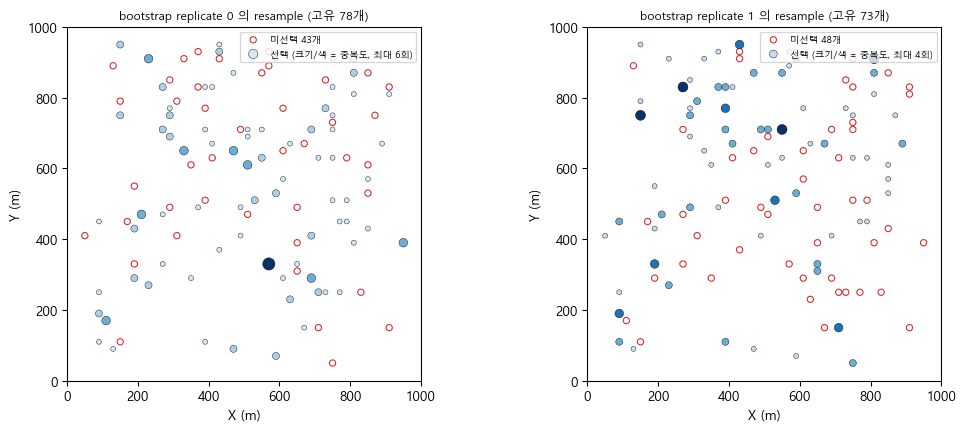

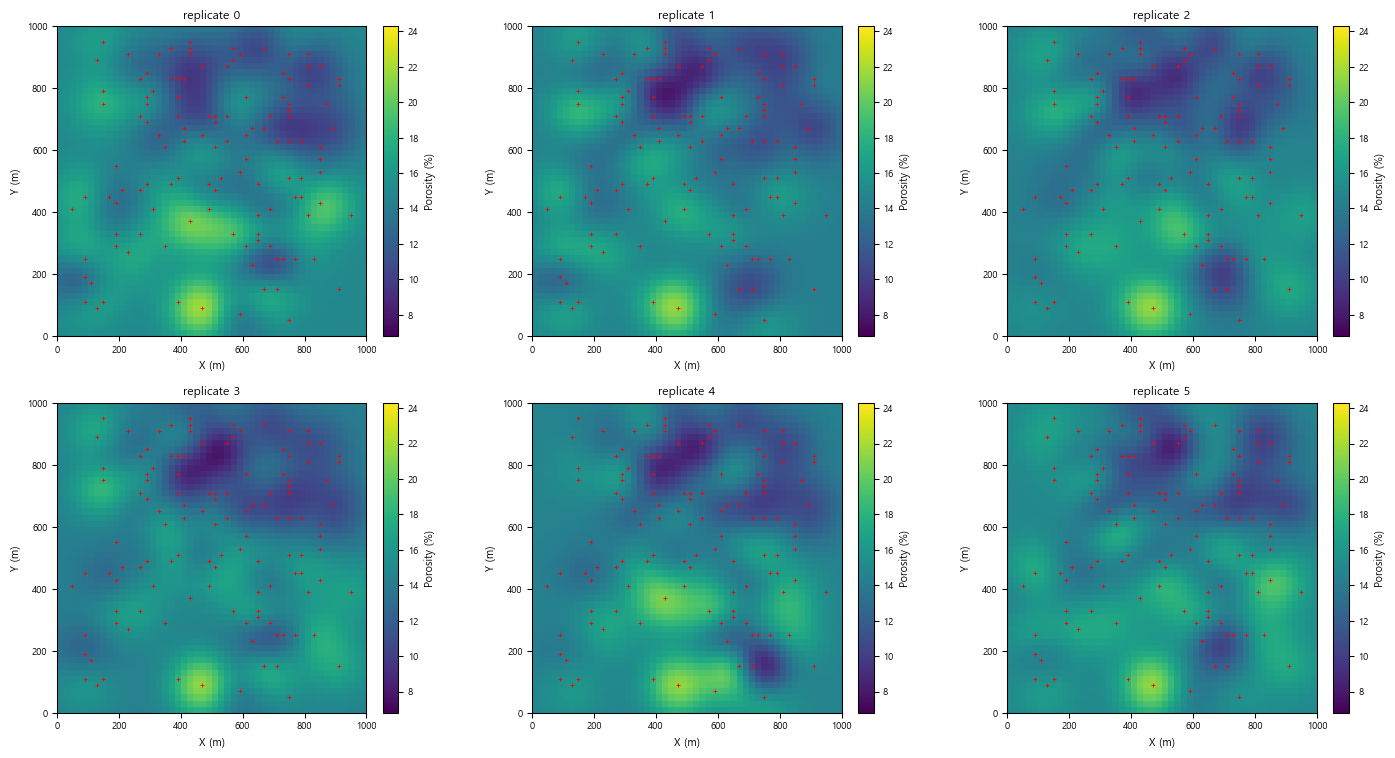

In [21]:
print("BOOTSTRAP_SEED=%d, N_BOOTSTRAP=%d" % (rbf_mod.BOOTSTRAP_SEED, rbf_mod.N_BOOTSTRAP))
print("replicate마다 하이퍼파라미터를 재튜닝하지 않는다: eps=%g, sm=%g 고정 (사용자 확정 설계)"
      % (best_epsilon, best_smoothing))
print()

rng = np.random.RandomState(rbf_mod.BOOTSTRAP_SEED)
replicate_maps = np.empty((rbf_mod.N_BOOTSTRAP, NY, NX))
boot_idx_list = []
n_bootstrap_deduplicated = 0
for b in range(rbf_mod.N_BOOTSTRAP):
    idx = rng.choice(n_actual_samples, size=n_actual_samples, replace=True)
    boot_idx_list.append(idx)
    X_fit, d_fit = X_rbf[idx], d_rbf[idx]
    if best_smoothing == 0.0:
        X_unique, unique_idx = np.unique(X_fit, axis=0, return_index=True)
        if len(X_unique) < len(X_fit):
            n_bootstrap_deduplicated += 1
            print("  note: replicate %d: 중복 (X,Y) %d행 제거 (%d unique / %d)"
                  % (b, len(X_fit) - len(X_unique), len(X_unique), len(X_fit)))
            X_fit, d_fit = X_unique, d_fit[unique_idx]
    rbf_b = RBFInterpolator(X_fit, d_fit, kernel=rbf_mod.RBF_KERNEL,
                            epsilon=best_epsilon, smoothing=best_smoothing)
    replicate_maps[b] = rbf_b(grid_coords).reshape(NY, NX)

print("n_bootstrap_deduplicated = %d / %d  (best_smoothing=%g 이므로 %s)"
      % (n_bootstrap_deduplicated, rbf_mod.N_BOOTSTRAP, best_smoothing,
         "분기 미발동" if best_smoothing != 0.0 else "분기 발동"))
print("non-finite 값 존재 여부: %s" % bool(np.any(~np.isfinite(replicate_maps))))
describe("replicate_maps", replicate_maps)
print()
for b in range(rbf_mod.N_BOOTSTRAP):
    _u = len(np.unique(boot_idx_list[b]))
    print("   replicate %2d: 고유 샘플 %3d / %3d (%.0f%%),  map mean=%7.4f std=%6.4f"
          % (b, _u, n_actual_samples, 100.0 * _u / n_actual_samples,
             replicate_maps[b].mean(), replicate_maps[b].std()))

# resample 위치 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for k, b in enumerate([0, 1]):
    idx = boot_idx_list[b]
    counts = np.bincount(idx, minlength=n_actual_samples)
    used = counts > 0
    axes[k].scatter(X_rbf[~used, 0], X_rbf[~used, 1], s=22, facecolors="none",
                    edgecolors="tab:red", linewidths=0.8, label="미선택 %d개" % int((~used).sum()))
    axes[k].scatter(X_rbf[used, 0], X_rbf[used, 1], s=14 * counts[used], c=counts[used],
                    cmap="Blues", vmin=0, vmax=counts.max(), edgecolors="k", linewidths=0.3,
                    label="선택 (크기/색 = 중복도, 최대 %d회)" % counts.max())
    axes[k].set_xlim(XMIN, XMAX); axes[k].set_ylim(YMIN, YMAX); axes[k].set_aspect("equal")
    axes[k].set_title("bootstrap replicate %d 의 resample (고유 %d개)" % (b, int(used.sum())), fontsize=9)
    axes[k].set_xlabel("X (m)"); axes[k].set_ylabel("Y (m)")
    axes[k].legend(fontsize=7, loc="upper right")
plt.tight_layout()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, b in enumerate(range(6)):
    show_map(axes.ravel()[i], replicate_maps[b], "replicate %d" % b, "Porosity (%)",
             vmin=_vmin, vmax=_vmax, samples=samples_df)
plt.tight_layout()

## 3.4 앙상블 mean / var

**대응**: `rbf_bootstrap.py` 5단계. 이 `bootstrap_var_map`이 Claim 1의 검증 대상이다 —
SGS/kriging 분산과 비교해 **체계적으로 너무 좁은지**를 §5에서 정량화한다.

bootstrap_mean_map                     shape=(50, 50)       min=    8.84387  max=   21.45665  mean=   14.68767  std=   1.95738  n_nan=0
bootstrap_var_map                      shape=(50, 50)       min=    0.00902  max=    5.67085  mean=    0.76314  std=   0.90808  n_nan=0

분산 비교 (중앙값, 물리 %^2):
   SGS            :   2.2073
   RBF+bootstrap  :   0.4445
   kriging (MC근사):   2.3318
   전역 분산(sill) :   9.0000


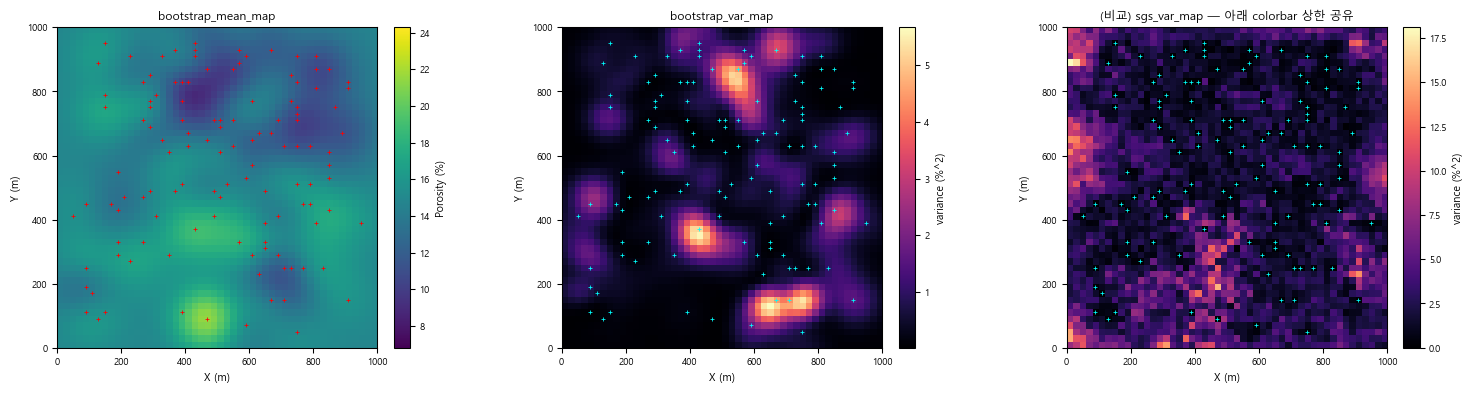

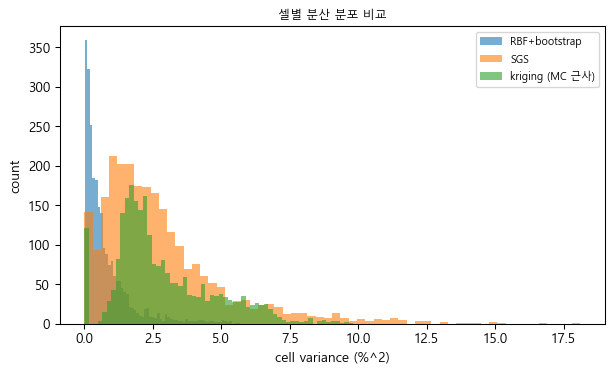

In [22]:
bootstrap_mean_map = replicate_maps.mean(axis=0)
bootstrap_var_map = replicate_maps.var(axis=0, ddof=1)

describe("bootstrap_mean_map", bootstrap_mean_map)
describe("bootstrap_var_map", bootstrap_var_map)
print()
print("분산 비교 (중앙값, 물리 %^2):")
print("   SGS            : %8.4f" % np.median(sgs_var_map))
print("   RBF+bootstrap  : %8.4f" % np.median(bootstrap_var_map))
print("   kriging (MC근사): %8.4f" % np.median(kriging_var_map_physical_mc))
print("   전역 분산(sill) : %8.4f" % POR_STDEV ** 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
show_map(axes[0], bootstrap_mean_map, "bootstrap_mean_map", "Porosity (%)",
         vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[1], bootstrap_var_map, "bootstrap_var_map", "variance (%^2)",
         cmap="magma", samples=samples_df, sample_color="cyan")
_shared = float(max(sgs_var_map.max(), bootstrap_var_map.max()))
show_map(axes[2], sgs_var_map, "(비교) sgs_var_map — 아래 colorbar 상한 공유", "variance (%^2)",
         cmap="magma", vmin=0, vmax=_shared, samples=samples_df, sample_color="cyan")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(bootstrap_var_map.ravel(), bins=60, alpha=0.6, label="RBF+bootstrap")
ax.hist(sgs_var_map.ravel(), bins=60, alpha=0.6, label="SGS")
ax.hist(kriging_var_map_physical_mc.ravel(), bins=60, alpha=0.6, label="kriging (MC 근사)")
ax.set_xlabel("cell variance (%^2)"); ax.set_ylabel("count")
ax.set_title("셀별 분산 분포 비교", fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()

## 3.5 `best_smoothing == 0.0` dedup 분기 시연

**대응**: `rbf_bootstrap.py` bootstrap 루프의 조건 분기.

base case는 `best_smoothing=0.1`이라 이 분기가 **발동하지 않는다**. 하지만 range=50m 축에서
CV가 `0.0`(정확 보간)을 고른 적이 있었고, 그때 복원추출의 **중복 좌표**가 RBF 보간 행렬을
특이하게 만들어 (a) `LinAlgError`가 나거나 (b) **예외 없이 전부 NaN인 map**이 나왔다.
후자가 조용해서 위험하므로 수정은 사후 예외처리가 아니라 **사전 dedup**으로 되어 있다.

아래에서 `smoothing=0.0`을 강제해 그 상황을 실제로 재현한다.

시연용 강제 설정: smoothing=0 (실제 CV 선택값은 0.1)

replicate 0 resample: 전체 121행, 고유 (X,Y) 78행 -> 중복 43행

[A] dedup 하지 않고 smoothing=0.0 으로 적합:
    예외 발생: LinAlgError: Singular matrix.

[B] rbf_bootstrap.py의 분기대로 dedup 후 적합:
    non-finite 셀 = 0
    dedup 후 map                        shape=(50, 50)       min=    5.98003  max=   22.37052  mean=   14.81025  std=   2.84033  n_nan=0

수학적 근거 (reviewer 확인): smoothing=0 은 '모든 지점을 정확히 지나라'는 등식 제약이므로,
동일 (X,Y)의 중복 행은 새 정보가 아니라 중복 제약이다 -> 제거해도 보간 함수값이 바뀌지 않고
특이행렬만 해소된다. smoothing>0 에서는 중복 행이 가중치로 실제 기여하므로 분기를 끈다.


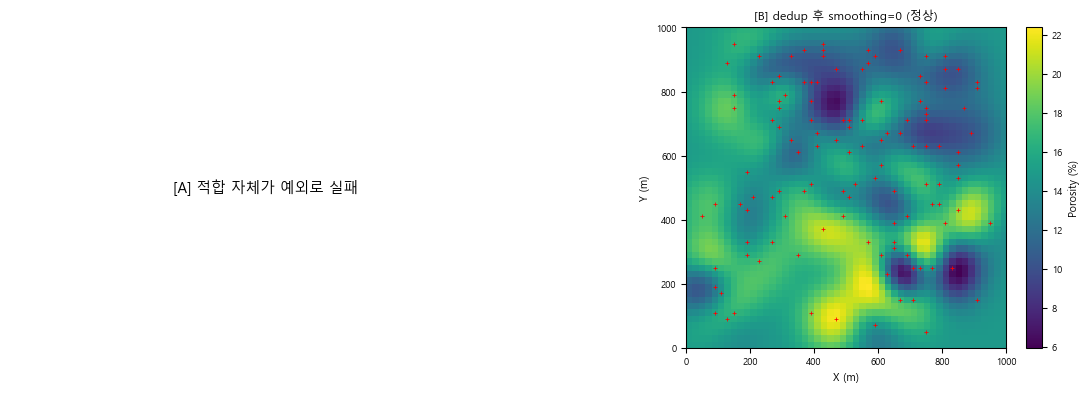

In [23]:
demo_smoothing = 0.0
print("시연용 강제 설정: smoothing=%g (실제 CV 선택값은 %g)" % (demo_smoothing, best_smoothing))
print()

_rng_demo = np.random.RandomState(rbf_mod.BOOTSTRAP_SEED)
idx0 = _rng_demo.choice(n_actual_samples, size=n_actual_samples, replace=True)
X_fit0, d_fit0 = X_rbf[idx0], d_rbf[idx0]
X_u0, u_idx0 = np.unique(X_fit0, axis=0, return_index=True)
print("replicate 0 resample: 전체 %d행, 고유 (X,Y) %d행 -> 중복 %d행"
      % (len(X_fit0), len(X_u0), len(X_fit0) - len(X_u0)))
print()

print("[A] dedup 하지 않고 smoothing=0.0 으로 적합:")
try:
    _rbf_bad = RBFInterpolator(X_fit0, d_fit0, kernel=rbf_mod.RBF_KERNEL,
                               epsilon=best_epsilon, smoothing=demo_smoothing)
    _map_bad = _rbf_bad(grid_coords).reshape(NY, NX)
    _nfin = int(np.sum(~np.isfinite(_map_bad)))
    print("    예외 없음. 하지만 non-finite 셀 = %d / %d" % (_nfin, _map_bad.size))
    if _nfin == 0:
        describe("    (예외 없이 통과한) map", _map_bad)
        print("    -> 이 draw는 우연히 살아남았지만, 값 자체가 불안정할 수 있다")
except Exception as exc:
    _map_bad = None
    print("    예외 발생: %s: %s" % (type(exc).__name__, exc))

print()
print("[B] rbf_bootstrap.py의 분기대로 dedup 후 적합:")
_rbf_ok = RBFInterpolator(X_u0, d_fit0[u_idx0], kernel=rbf_mod.RBF_KERNEL,
                          epsilon=best_epsilon, smoothing=demo_smoothing)
_map_ok = _rbf_ok(grid_coords).reshape(NY, NX)
print("    non-finite 셀 = %d" % int(np.sum(~np.isfinite(_map_ok))))
describe("    dedup 후 map", _map_ok)
print()
print("수학적 근거 (reviewer 확인): smoothing=0 은 '모든 지점을 정확히 지나라'는 등식 제약이므로,")
print("동일 (X,Y)의 중복 행은 새 정보가 아니라 중복 제약이다 -> 제거해도 보간 함수값이 바뀌지 않고")
print("특이행렬만 해소된다. smoothing>0 에서는 중복 행이 가중치로 실제 기여하므로 분기를 끈다.")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
if _map_bad is not None:
    show_map(axes[0], np.where(np.isfinite(_map_bad), _map_bad, np.nan),
             "[A] dedup 없이 smoothing=0 (non-finite %d셀)" % int(np.sum(~np.isfinite(_map_bad))),
             "Porosity (%)", samples=samples_df)
else:
    axes[0].text(0.5, 0.5, "[A] 적합 자체가 예외로 실패", ha="center", va="center", fontsize=11)
    axes[0].set_axis_off()
show_map(axes[1], _map_ok, "[B] dedup 후 smoothing=0 (정상)", "Porosity (%)", samples=samples_df)
plt.tight_layout()

---
# 4. GP-MLE — `src/experiments/gp_mle.py`

파이프라인:

1. 공통 조건화 데이터 (§0)
2. 커널 `ConstantKernel() * RBF(length_scale) + WhiteKernel(noise_level)` 구성 →
   `gpr.fit()`이 **marginal likelihood 최대화**로 하이퍼파라미터를 자동 선택
   (`n_restarts_optimizer=8`, 손으로 튜닝하지 않음 — 논문이 비판하는 바로 그 절차)
3. `gpr.predict(..., return_std=True)` 한 번으로 posterior mean과 variance를 동시에 얻는다
   (bootstrap 앙상블이 필요 없다 — Bayesian posterior 자체가 불확실성 모델)

## 4.1 커널 구성 / 적합 전 초기값·bounds

**대응**: `gp_mle.build_kernel()` — **실제 함수 호출**.

In [24]:
kernel = gp_mod.build_kernel()
print("초기 커널 : %s" % kernel)
print()
print("하이퍼파라미터 초기값/bounds (src/experiments/gp_mle.py 상수):")
for hp in kernel.hyperparameters:
    print("   %-28s bounds=%s  (n_elements=%d)" % (hp.name, np.asarray(hp.bounds).tolist(), hp.n_elements))
print()
print("   CONSTANT_VALUE_INIT = %g,  bounds = %s" % (gp_mod.CONSTANT_VALUE_INIT, str(gp_mod.CONSTANT_VALUE_BOUNDS)))
print("   LENGTH_SCALE_INIT   = %g,  bounds = %s" % (gp_mod.LENGTH_SCALE_INIT, str(gp_mod.LENGTH_SCALE_BOUNDS)))
print("   NOISE_LEVEL_INIT    = %g,  bounds = %s" % (gp_mod.NOISE_LEVEL_INIT, str(gp_mod.NOISE_LEVEL_BOUNDS)))
print("   N_RESTARTS_OPTIMIZER= %d,  GP_RANDOM_STATE = %d" % (gp_mod.N_RESTARTS_OPTIMIZER, gp_mod.GP_RANDOM_STATE))
print("   theta (log 공간 초기값) = %s" % np.round(kernel.theta, 4))
print()
print("주의: normalize_y=True 이므로 최적화는 내부 표준화된 y 공간에서 이뤄진다.")
print("      ConstantKernel/WhiteKernel 값은 그 표준화 공간의 분산이고, 물리 단위로 보려면")
print("      gpr._y_train_std**2 를 곱해야 한다 (gp_mle.py가 하는 그대로).")

초기 커널 : 1**2 * RBF(length_scale=100) + WhiteKernel(noise_level=1)

하이퍼파라미터 초기값/bounds (src/experiments/gp_mle.py 상수):
   k1__k1__constant_value       bounds=[[0.001, 1000.0]]  (n_elements=1)
   k1__k2__length_scale         bounds=[[0.01, 10000.0]]  (n_elements=1)
   k2__noise_level              bounds=[[1e-05, 1000.0]]  (n_elements=1)

   CONSTANT_VALUE_INIT = 1,  bounds = (0.001, 1000.0)
   LENGTH_SCALE_INIT   = 100,  bounds = (0.01, 10000.0)
   NOISE_LEVEL_INIT    = 1,  bounds = (1e-05, 1000.0)
   N_RESTARTS_OPTIMIZER= 8,  GP_RANDOM_STATE = 50
   theta (log 공간 초기값) = [0.     4.6052 0.    ]

주의: normalize_y=True 이므로 최적화는 내부 표준화된 y 공간에서 이뤄진다.
      ConstantKernel/WhiteKernel 값은 그 표준화 공간의 분산이고, 물리 단위로 보려면
      gpr._y_train_std**2 를 곱해야 한다 (gp_mle.py가 하는 그대로).


## 4.2 `gpr.fit` — 학습된 하이퍼파라미터

**practical range 환산**: sklearn의 `RBF` 커널은 `corr(h) = exp(-h^2 / (2 l^2))`이다.
지구통계에서 쓰는 practical range(상관이 sill의 5%로 떨어지는 거리)는
`corr = 0.05` → `h^2/(2l^2) = ln 20 = 2.996` → `h = l * sqrt(2 ln 20) ≈ l * sqrt(6) ≈ 2.45 l`.
즉 **√6·ℓ**을 truth의 range(`RANGE`, 기본 300 m)와 비교해야 한다 — ℓ 자체를 직접 비교하면 안 된다.

In [25]:
X_gp = samples_df[["X", "Y"]].values
y_gp = samples_df[VCOL].values

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=gp_mod.N_RESTARTS_OPTIMIZER,
    normalize_y=True,
    random_state=gp_mod.GP_RANDOM_STATE,
)
t0 = time.time()
gpr.fit(X_gp, y_gp)
print("gpr.fit 소요: %.2f초" % (time.time() - t0))
print()

fitted_kernel = gpr.kernel_
constant_kernel = fitted_kernel.k1.k1
rbf_kernel = fitted_kernel.k1.k2
white_kernel = fitted_kernel.k2

y_train_std = float(gpr._y_train_std)
sig_var_norm = float(constant_kernel.constant_value)
noise_var_norm = float(white_kernel.noise_level)
sig_var_real = sig_var_norm * y_train_std ** 2
noise_var_real = noise_var_norm * y_train_std ** 2
length_scale = float(rbf_kernel.length_scale)
practical_range = length_scale * np.sqrt(6.0)

print("학습된 커널 : %s" % fitted_kernel)
print("log marginal likelihood = %.4f" % gpr.log_marginal_likelihood(gpr.kernel_.theta))
print()
print("  length_scale (l)               = %10.4f m" % length_scale)
print("  practical range (sqrt(6) * l)  = %10.4f m   <-- truth range %g m 와 비교할 값"
      % (practical_range, RANGE))
print("  practical range / truth range  = %10.4f" % (practical_range / RANGE))
print()
print("  y_train_std (normalize_y)      = %10.4f" % y_train_std)
print("  signal variance (표준화 공간)   = %10.4f" % sig_var_norm)
print("  noise  variance (표준화 공간)   = %10.6f" % noise_var_norm)
print("  signal variance (물리 %%^2)      = %10.4f" % sig_var_real)
print("  noise  variance (물리 %%^2)      = %10.6f" % noise_var_real)
print()
print("  학습된 nugget 비율 noise/(signal+noise) = %.5f" % (noise_var_real / (sig_var_real + noise_var_real)))
print("  truth 생성 시 nugget 비율                = %.5f  (nug=%.2f, sill=%.2f)"
      % (vario["nug"] / (vario["nug"] + vario["cc1"]), vario["nug"], vario["nug"] + vario["cc1"]))
print("  (Claim 2가 겨냥하는 지점: 자동 튜닝이 nugget을 신호로 흡수하면 불확실성이 압축된다.")
print("   base case는 nugget이 작아 차이가 작을 수 있고, nugget axis에서 본격적으로 드러날 부분이다.)")
print()
print("  bounds 경계에 붙었는지 확인 (붙었으면 최적화가 제약된 것):")
for _nm, _v, _b in [("length_scale", length_scale, gp_mod.LENGTH_SCALE_BOUNDS),
                    ("constant_value", sig_var_norm, gp_mod.CONSTANT_VALUE_BOUNDS),
                    ("noise_level", noise_var_norm, gp_mod.NOISE_LEVEL_BOUNDS)]:
    _hit = (abs(np.log10(_v) - np.log10(_b[0])) < 1e-6) or (abs(np.log10(_v) - np.log10(_b[1])) < 1e-6)
    print("     %-15s = %-12.6g bounds=%s  %s" % (_nm, _v, str(_b), "<<< 경계에 붙음" if _hit else "내부"))

gpr.fit 소요: 0.70초

학습된 커널 : 0.937**2 * RBF(length_scale=116) + WhiteKernel(noise_level=0.237)
log marginal likelihood = -127.4585

  length_scale (l)               =   116.1313 m
  practical range (sqrt(6) * l)  =   284.4625 m   <-- truth range 300 m 와 비교할 값
  practical range / truth range  =     0.9482

  y_train_std (normalize_y)      =     2.6018
  signal variance (표준화 공간)   =     0.8786
  noise  variance (표준화 공간)   =   0.236562
  signal variance (물리 %^2)      =     5.9477
  noise  variance (물리 %^2)      =   1.601347

  학습된 nugget 비율 noise/(signal+noise) = 0.21213
  truth 생성 시 nugget 비율                = 0.05000  (nug=0.05, sill=1.00)
  (Claim 2가 겨냥하는 지점: 자동 튜닝이 nugget을 신호로 흡수하면 불확실성이 압축된다.
   base case는 nugget이 작아 차이가 작을 수 있고, nugget axis에서 본격적으로 드러날 부분이다.)

  bounds 경계에 붙었는지 확인 (붙었으면 최적화가 제약된 것):
     length_scale    = 116.131      bounds=(0.01, 10000.0)  내부
     constant_value  = 0.878635     bounds=(0.001, 1000.0)  내부
     noise_level     = 0.236562     bounds=(1e-05, 1000.0)  내부

## 4.3 Posterior mean / std map

**대응**: `gp_mle.py` 3단계. `predict(return_std=True)` 한 번 호출로 끝난다 (재적합 없음).
`normalize_y=True`여도 sklearn이 역스케일링을 해주므로 반환값은 이미 물리 단위다.

gpr.predict 소요: 0.02초 (2500 셀)
post_mean_map                          shape=(50, 50)       min=    9.41253  max=   20.08746  mean=   14.92881  std=   2.25845  n_nan=0
post_std_map                           shape=(50, 50)       min=    1.36684  max=    2.61094  mean=    1.65113  std=   0.27224  n_nan=0
post_var_map                           shape=(50, 50)       min=    1.86824  max=    6.81703  mean=    2.80033  std=   0.99697  n_nan=0

샘플 셀에서의 posterior 분산: 평균 2.09178 (0이 아니라 noise level 근처여야 정상: noise_var_real=1.60135)
샘플에서 먼 셀의 분산 최댓값: 6.8170  (prior 분산 signal+noise = 7.5490 에 접근해야 정상)


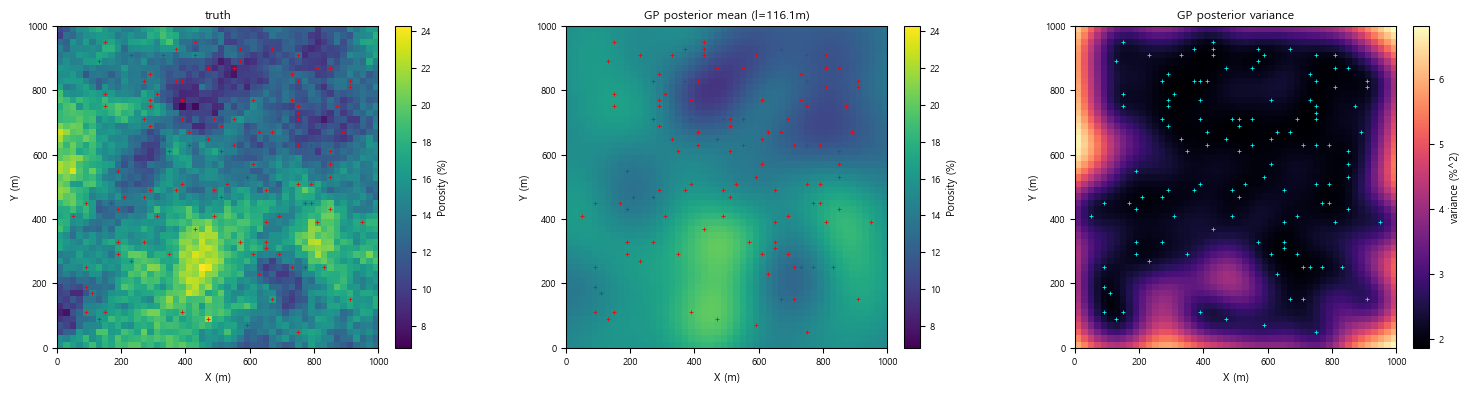

In [26]:
t0 = time.time()
post_mean, post_std = gpr.predict(grid_coords, return_std=True)
print("gpr.predict 소요: %.2f초 (%d 셀)" % (time.time() - t0, len(grid_coords)))

post_mean_map = post_mean.reshape(NY, NX)
post_std_map = post_std.reshape(NY, NX)
post_var_map = post_std_map ** 2

describe("post_mean_map", post_mean_map)
describe("post_std_map", post_std_map)
describe("post_var_map", post_var_map)
print()
print("샘플 셀에서의 posterior 분산: 평균 %.5f (0이 아니라 noise level 근처여야 정상: noise_var_real=%.5f)"
      % (post_var_map[sample_row, sample_col].mean(), noise_var_real))
print("샘플에서 먼 셀의 분산 최댓값: %.4f  (prior 분산 signal+noise = %.4f 에 접근해야 정상)"
      % (post_var_map.max(), sig_var_real + noise_var_real))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
show_map(axes[0], truth, "truth", "Porosity (%)", vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[1], post_mean_map, "GP posterior mean (l=%.1fm)" % length_scale, "Porosity (%)",
         vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[2], post_var_map, "GP posterior variance", "variance (%^2)",
         cmap="magma", samples=samples_df, sample_color="cyan")
plt.tight_layout()

## 4.4 Posterior 샘플 draw — `sample_y` SVD 실패와 Cholesky fallback

**대응**: `gp_mle.py`의 `try/except np.linalg.LinAlgError` 블록.

이 환경(numpy 1.24.4)에서는 `gpr.sample_y`가 내부적으로 쓰는
`numpy.random.RandomState.multivariate_normal` → `numpy.linalg.svd`가
2500×2500 posterior 공분산에 대해 **seed와 무관하게 재현성 있게** "SVD did not converge"로 실패한다.
공분산 자체는 정상(NaN/Inf 없음, 고윳값 전부 양수)이고 `scipy.linalg.svd`는 성공하므로
numpy/LAPACK 쪽 수렴 문제다.

fallback은 `sample_y`가 하는 계산(`predict(return_cov=True)` → 전체 공분산에서 draw)을 그대로 하되,
SVD 대신 **Cholesky 분해**를 쓴다. 둘 다 같은 공분산의 제곱근이므로 수학적으로 동등하다.

GP_SAMPLE_SEED = 55 (GP_RANDOM_STATE=50 와 별개 — 최적화 restart와 posterior draw는 무관한 난수)



경로 [2] gpr.sample_y() 실패: LinAlgError('SVD did not converge')
        -> 동일한 전체 posterior N(y_mean, y_cov)에서 Cholesky로 draw (fallback)


        y_cov shape=(2500, 2500), 고윳값 범위=[1.6013, 233.6032], NaN/Inf=0


소요 11.40초, 방법 = manual_cholesky_fallback

posterior_sample_map                   shape=(50, 50)       min=    6.54688  max=   24.01262  mean=   14.95364  std=   2.72869  n_nan=0
posterior mean 대비 편차의 표준편차 = 1.7500  (pointwise post_std 평균 1.6511 와 비슷해야 정상)


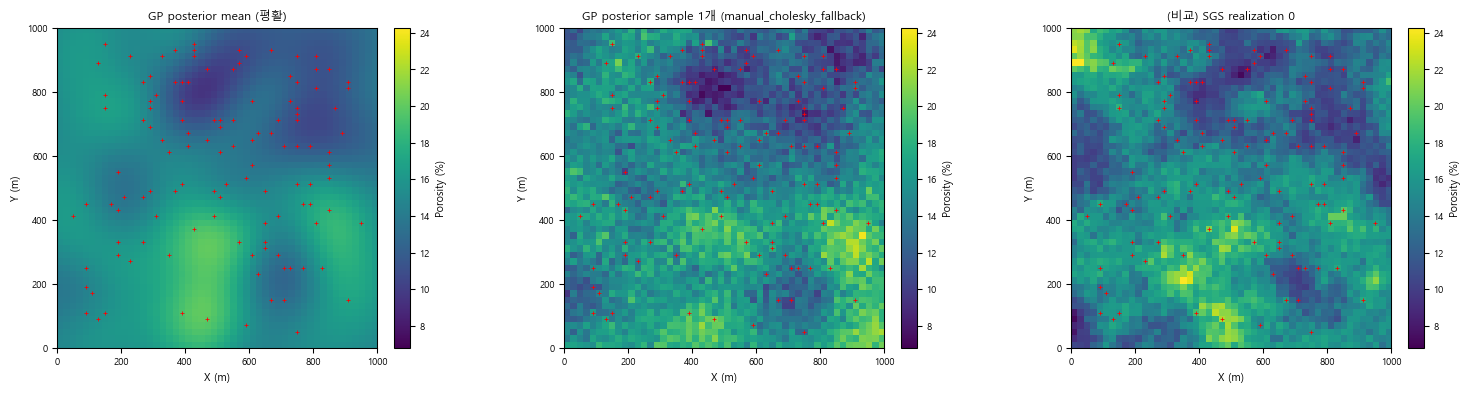

In [27]:
print("GP_SAMPLE_SEED = %d (GP_RANDOM_STATE=%d 와 별개 — 최적화 restart와 posterior draw는 무관한 난수)"
      % (gp_mod.GP_SAMPLE_SEED, gp_mod.GP_RANDOM_STATE))
print()
t0 = time.time()
try:
    posterior_sample = gpr.sample_y(grid_coords, n_samples=1, random_state=gp_mod.GP_SAMPLE_SEED)
    posterior_sample_map = posterior_sample[:, 0].reshape(NY, NX)
    posterior_sample_method = "sklearn_sample_y_svd"
    print("경로 [1] gpr.sample_y() 성공 -> sklearn API 그대로 사용")
except np.linalg.LinAlgError as exc:
    print("경로 [2] gpr.sample_y() 실패: %r" % (exc,))
    print("        -> 동일한 전체 posterior N(y_mean, y_cov)에서 Cholesky로 draw (fallback)")
    y_mean_full, y_cov_full = gpr.predict(grid_coords, return_cov=True)
    _eig = np.linalg.eigvalsh(y_cov_full)
    print("        y_cov shape=%s, 고윳값 범위=[%.4f, %.4f], NaN/Inf=%d"
          % (y_cov_full.shape, _eig.min(), _eig.max(), int(np.sum(~np.isfinite(y_cov_full)))))
    L = np.linalg.cholesky(y_cov_full)
    z = np.random.RandomState(gp_mod.GP_SAMPLE_SEED).standard_normal(y_mean_full.shape[0])
    posterior_sample_map = (y_mean_full + L @ z).reshape(NY, NX)
    posterior_sample_method = "manual_cholesky_fallback"
print("소요 %.2f초, 방법 = %s" % (time.time() - t0, posterior_sample_method))
print()
describe("posterior_sample_map", posterior_sample_map)
print("posterior mean 대비 편차의 표준편차 = %.4f  (pointwise post_std 평균 %.4f 와 비슷해야 정상)"
      % (float(np.std(posterior_sample_map - post_mean_map)), float(post_std_map.mean())))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
show_map(axes[0], post_mean_map, "GP posterior mean (평활)", "Porosity (%)",
         vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[1], posterior_sample_map, "GP posterior sample 1개 (%s)" % posterior_sample_method,
         "Porosity (%)", vmin=_vmin, vmax=_vmax, samples=samples_df)
show_map(axes[2], realizations[0], "(비교) SGS realization 0", "Porosity (%)",
         vmin=_vmin, vmax=_vmax, samples=samples_df)
plt.tight_layout()

## 4.5 학습된 커널의 상관함수 vs truth variogram

스케일 비교. GP의 구조함수를 variogram 형태로 바꾸면
`gamma_GP(h) = noise_var + signal_var * (1 - exp(-h^2/(2 l^2)))`이고,
truth 모델은 NS 공간 sill=1이므로 물리 단위로는 `stdev^2`를 곱하면 된다 (affine은 선형).

 x,y,z offsets = 0.0,20.0
h=0 근방:
   GP    nugget(=noise_var_real)            = 1.60135 %^2
   truth nugget(= nug * stdev^2)            = 0.45000 %^2
총 sill:
   GP    signal+noise                       = 7.5490 %^2
   truth stdev^2                            = 9.0000 %^2
range:
   GP    practical range sqrt(6)*l          = 284.46 m
   truth range                              = 300.00 m


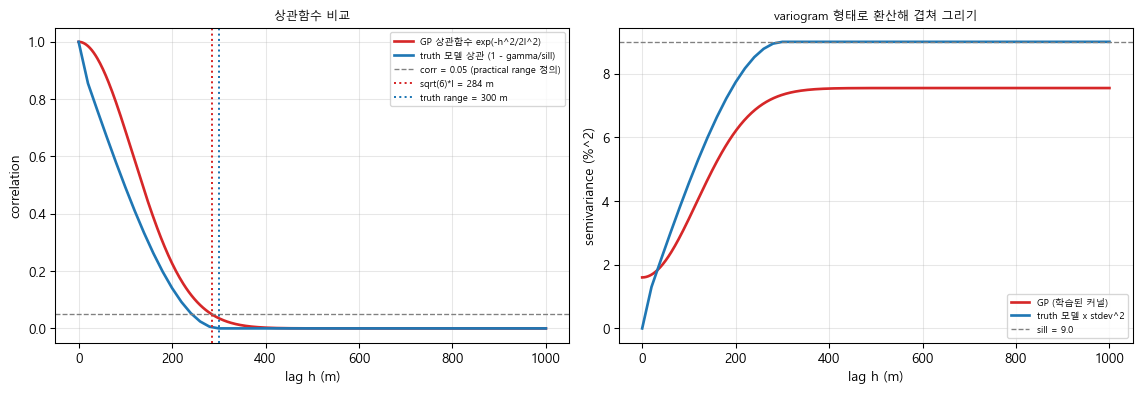

In [28]:
h_grid = np.linspace(0.0, 1000.0, 501)
corr_gp = np.exp(-0.5 * (h_grid / length_scale) ** 2)
gam_gp = noise_var_real + sig_var_real * (1.0 - corr_gp)

_i2, h_m, gam_m, _c2, ro_m = geostats.vmodel(nlag=50, xlag=20.0, azm=0.0, vario=vario)
gam_truth_phys = gam_m * POR_STDEV ** 2

print("h=0 근방:")
print("   GP    nugget(=noise_var_real)            = %.5f %%^2" % noise_var_real)
print("   truth nugget(= nug * stdev^2)            = %.5f %%^2" % (vario["nug"] * POR_STDEV ** 2))
print("총 sill:")
print("   GP    signal+noise                       = %.4f %%^2" % (sig_var_real + noise_var_real))
print("   truth stdev^2                            = %.4f %%^2" % POR_STDEV ** 2)
print("range:")
print("   GP    practical range sqrt(6)*l          = %.2f m" % practical_range)
print("   truth range                              = %.2f m" % RANGE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(h_grid, corr_gp, "-", color="tab:red", lw=2, label="GP 상관함수 exp(-h^2/2l^2)")
axes[0].plot(h_m, ro_m, "-", color="tab:blue", lw=2, label="truth 모델 상관 (1 - gamma/sill)")
axes[0].axhline(0.05, color="gray", ls="--", lw=1, label="corr = 0.05 (practical range 정의)")
axes[0].axvline(practical_range, color="tab:red", ls=":", lw=1.5, label="sqrt(6)*l = %.0f m" % practical_range)
axes[0].axvline(RANGE, color="tab:blue", ls=":", lw=1.5, label="truth range = %g m" % RANGE)
axes[0].set_xlabel("lag h (m)"); axes[0].set_ylabel("correlation")
axes[0].set_title("상관함수 비교", fontsize=9)
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].plot(h_grid, gam_gp, "-", color="tab:red", lw=2, label="GP (학습된 커널)")
axes[1].plot(h_m, gam_truth_phys, "-", color="tab:blue", lw=2, label="truth 모델 x stdev^2")
axes[1].axhline(POR_STDEV ** 2, color="gray", ls="--", lw=1, label="sill = %.1f" % POR_STDEV ** 2)
axes[1].set_xlabel("lag h (m)"); axes[1].set_ylabel("semivariance (%^2)")
axes[1].set_title("variogram 형태로 환산해 겹쳐 그리기", fontsize=9)
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout()

---
# 5. 평가 지표 — `src/evaluation.py`

**accuracy와 uncertainty quality를 분리해서** 본다 (논문의 핵심 논지이므로 절대 하나로 뭉치지 않는다).

| 지표 | 성격 | 함수 |
|---|---|---|
| MSE | accuracy | `ev.mse` |
| UMG (Deutsch goodness) | calibration (집계 coverage) | `ev.accuracy_plot_fraction_in` / `ev.kriging_fraction_in` + `ev.calc_umg` |
| interval width (p=0.95) | sharpness | `ev.gaussian_interval_widths` / `ev.kriging_interval_widths` |
| CRPS | proper scoring rule (calibration+sharpness 동시) | `ev.gaussian_crps` / `ev.kriging_crps` |

**방법별 예측 분포 표현** (`evaluation.py`의 cross-method fairness 규약):
- SGS / RBF+bootstrap / GP-MLE → 셀별 가우시안 `N(mean, std)` (물리 단위)
- kriging → 셀별 가우시안을 **NS 공간**에서 잡고, 분위수 끝점만 물리 단위로 역변환.
  kriging **분산은 절대 역변환하지 않는다**.

## 5.1 `conditioning_cell_mask` — 평가에서 제외되는 셀

**대응**: `evaluate_*.py`의 공통 전처리. 조건화 샘플이 놓인 셀은 4개 방법 **모두** 동일하게 제외한다
(그 셀에서 kriging 분산은 0, SGS는 honor로 정확히 일치하므로 평가에 넣으면 방법 간 비교가 왜곡된다).

mask shape = (50, 50), dtype = bool  (True = 평가에 포함)
제외되는 조건화 셀 : 121
평가 대상 셀       : 2379 / 2500 (95.16%)
제외 셀 수 == 실제 샘플 수 : True
truth_masked                           shape=(2379,)        min=    6.80504  max=   24.28885  mean=   15.04559  std=   3.01173  n_nan=0


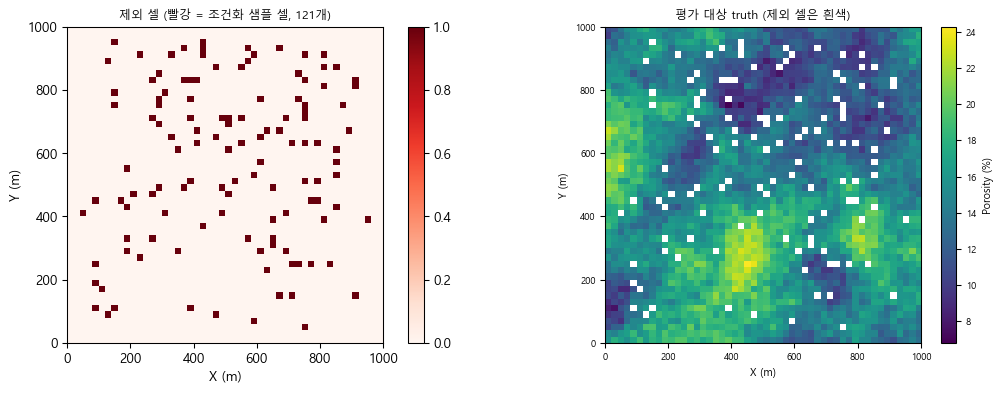

In [29]:
mask = ev.conditioning_cell_mask(samples_df, NX, NY, XMN, YMN, XSIZ, YSIZ)
n_excluded = int((~mask).sum())
print("mask shape = %s, dtype = %s  (True = 평가에 포함)" % (mask.shape, mask.dtype))
print("제외되는 조건화 셀 : %d" % n_excluded)
print("평가 대상 셀       : %d / %d (%.2f%%)" % (int(mask.sum()), mask.size, 100.0 * mask.sum() / mask.size))
print("제외 셀 수 == 실제 샘플 수 : %s" % (n_excluded == n_actual_samples))

truth_masked = truth[mask]
describe("truth_masked", truth_masked)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
im = axes[0].imshow((~mask).astype(float), extent=[XMIN, XMAX, YMIN, YMAX], origin="upper",
                    cmap="Reds", vmin=0, vmax=1)
axes[0].set_title("제외 셀 (빨강 = 조건화 샘플 셀, %d개)" % n_excluded, fontsize=9)
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
plt.colorbar(im, ax=axes[0], fraction=0.046)
_masked_truth = np.where(mask, truth, np.nan)
show_map(axes[1], _masked_truth, "평가 대상 truth (제외 셀은 흰색)", "Porosity (%)")
plt.tight_layout()

## 5.2 방법별 예측 배열 정리

`evaluation.py` docstring에 명시된 소스 배열 규약을 그대로 따른다:

- kriging : MSE는 `kmap_physical`, 불확실성은 `kmap_ns` + `vmap_ns` (NS 공간 분위수 역변환)
- SGS : `sgs_mean_map` / `sgs_var_map` (둘 다 앙상블 통계)
- RBF+bootstrap : MSE는 **단일 적합** `point_estimate_map`, 불확실성은 `bootstrap_mean_map` / `bootstrap_var_map`
- GP-MLE : `posterior_mean_map` / `posterior_var_map`

In [30]:
METHODS = ["kriging", "sgs", "rbf_bootstrap", "gp_mle"]
COLORS = {"kriging": "tab:blue", "sgs": "tab:green", "rbf_bootstrap": "tab:orange", "gp_mle": "tab:red"}

std_ns_masked = np.sqrt(np.clip(vmap_ns[mask], 0.0, None))
kmap_ns_masked = kmap_ns[mask]

gaussian_specs = {
    "sgs":           (sgs_mean_map,       sgs_mean_map,       sgs_var_map),
    "rbf_bootstrap": (point_estimate_map, bootstrap_mean_map, bootstrap_var_map),
    "gp_mle":        (post_mean_map,      post_mean_map,      post_var_map),
}
point_maps = {"kriging": kmap_physical}
unc = {}
for m, (pm, um, uv) in gaussian_specs.items():
    point_maps[m] = pm
    unc[m] = (um[mask], np.sqrt(np.clip(uv[mask], 0.0, None)))

print("%-15s %-28s %-28s" % ("method", "point estimate 소스", "불확실성 소스"))
print("%-15s %-28s %-28s" % ("kriging", "kmap_physical", "kmap_ns + vmap_ns (NS)"))
print("%-15s %-28s %-28s" % ("sgs", "sgs_mean_map", "sgs_mean/var_map"))
print("%-15s %-28s %-28s" % ("rbf_bootstrap", "point_estimate_map", "bootstrap_mean/var_map"))
print("%-15s %-28s %-28s" % ("gp_mle", "posterior_mean_map", "posterior_mean/var_map"))
print()
for m in METHODS:
    if m == "kriging":
        print("%-15s point mean=%7.4f | NS std: min=%.4f max=%.4f mean=%.4f"
              % (m, point_maps[m][mask].mean(), std_ns_masked.min(), std_ns_masked.max(), std_ns_masked.mean()))
    else:
        _mu, _sd = unc[m]
        print("%-15s point mean=%7.4f | 물리 std: min=%.4f max=%.4f mean=%.4f"
              % (m, point_maps[m][mask].mean(), _sd.min(), _sd.max(), _sd.mean()))
print()
print("주의: std가 0에 가까운 셀이 남아있으면 evaluation.py가 경고를 내며 드롭한다 (STD_EPS=%g)" % ev.STD_EPS)
for m in ["sgs", "rbf_bootstrap", "gp_mle"]:
    print("   %-15s std <= STD_EPS 인 셀: %d" % (m, int((unc[m][1] <= ev.STD_EPS).sum())))
print("   %-15s std <= STD_EPS 인 셀: %d" % ("kriging(NS)", int((std_ns_masked <= ev.STD_EPS).sum())))

method          point estimate 소스            불확실성 소스                     
kriging         kmap_physical                kmap_ns + vmap_ns (NS)      
sgs             sgs_mean_map                 sgs_mean/var_map            
rbf_bootstrap   point_estimate_map           bootstrap_mean/var_map      
gp_mle          posterior_mean_map           posterior_mean/var_map      

kriging         point mean=14.9254 | NS std: min=0.3882 max=0.9594 mean=0.6038
sgs             point mean=14.9146 | 물리 std: min=0.3545 max=4.2548 mean=1.6045
rbf_bootstrap   point mean=14.8860 | 물리 std: min=0.1056 max=2.3814 mean=0.7585
gp_mle          point mean=14.9723 | 물리 std: min=1.3668 max=2.6109 mean=1.6616

주의: std가 0에 가까운 셀이 남아있으면 evaluation.py가 경고를 내며 드롭한다 (STD_EPS=1e-12)
   sgs             std <= STD_EPS 인 셀: 0
   rbf_bootstrap   std <= STD_EPS 인 셀: 0
   gp_mle          std <= STD_EPS 인 셀: 0
   kriging(NS)     std <= STD_EPS 인 셀: 0


## 5.3 MSE — truth vs 예측 crossplot

**대응**: `ev.mse(truth_masked, pred_masked)`.

MSE (accuracy, 낮을수록 좋음) — 평가 셀 2379개
   kriging         MSE= 3.31226  RMSE=1.81996  MAE=1.40708  상관계수=0.7993
   sgs             MSE= 3.61256  RMSE=1.90067  MAE=1.46014  상관계수=0.7772
   rbf_bootstrap   MSE= 3.72556  RMSE=1.93017  MAE=1.49292  상관계수=0.7699
   gp_mle          MSE= 3.39988  RMSE=1.84388  MAE=1.43381  상관계수=0.7923


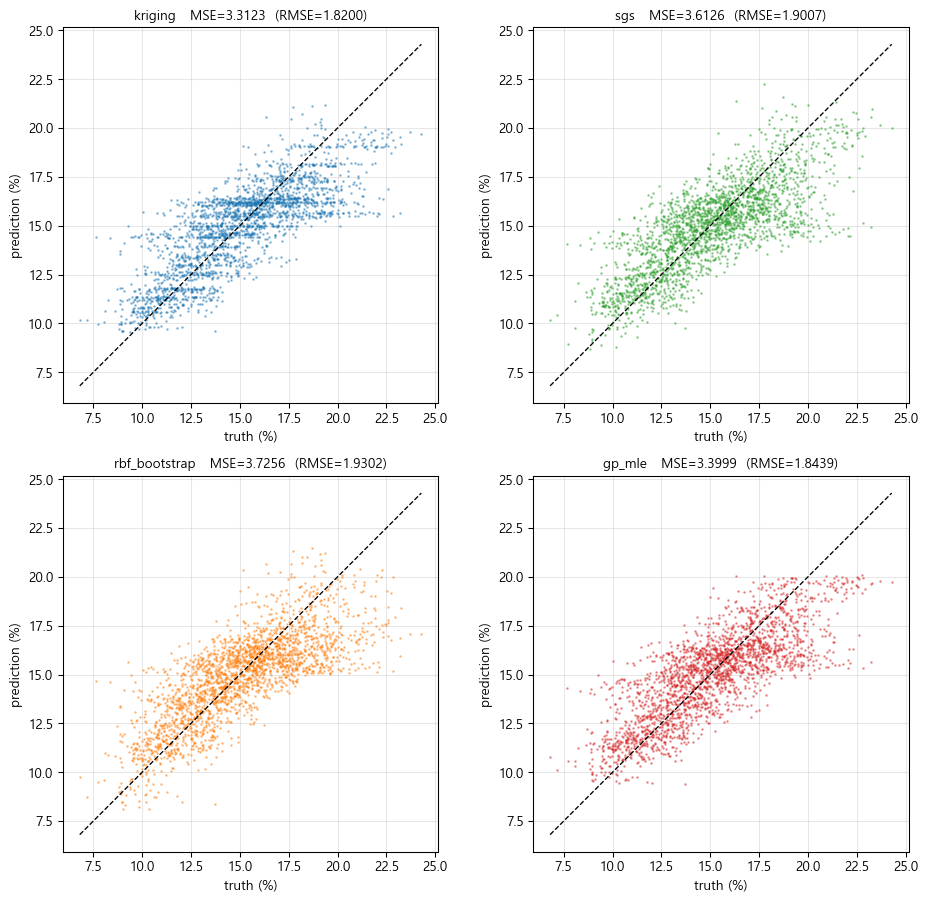

In [31]:
mse_vals = {m: ev.mse(truth_masked, point_maps[m][mask]) for m in METHODS}

fig, axes = plt.subplots(2, 2, figsize=(10, 9.5))
for ax, m in zip(axes.ravel(), METHODS):
    p = point_maps[m][mask]
    ax.plot(truth_masked, p, ".", ms=2, alpha=0.4, color=COLORS[m])
    _lo = min(truth_masked.min(), p.min()); _hi = max(truth_masked.max(), p.max())
    ax.plot([_lo, _hi], [_lo, _hi], "k--", lw=1)
    ax.set_xlabel("truth (%)"); ax.set_ylabel("prediction (%)")
    ax.set_title("%s   MSE=%.4f  (RMSE=%.4f)" % (m, mse_vals[m], np.sqrt(mse_vals[m])), fontsize=10)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
plt.tight_layout()

print("MSE (accuracy, 낮을수록 좋음) — 평가 셀 %d개" % int(mask.sum()))
for m in METHODS:
    print("   %-15s MSE=%8.5f  RMSE=%7.5f  MAE=%7.5f  상관계수=%.4f"
          % (m, mse_vals[m], np.sqrt(mse_vals[m]),
             np.mean(np.abs(truth_masked - point_maps[m][mask])),
             np.corrcoef(truth_masked, point_maps[m][mask])[0, 1]))

## 5.4 UMG — accuracy plot과 `calc_umg`의 적분

**대응**: `ev.accuracy_plot_fraction_in` (가우시안 3개 방법) / `ev.kriging_fraction_in` (kriging) →
`ev.calc_umg`.

`calc_umg`가 재는 것:

```
a_p = 1 if fraction_in > p else 0
G   = 1 - (1/n) * sum_p (3*a_p - 2) * (fraction_in - p)
```

- `fraction_in > p` (**과대산포**, 곡선이 y=x 위) → 가중치 **1**
- `fraction_in <= p` (**과소산포/과신**, 곡선이 y=x 아래) → 가중치 **-2**, 즉 `2*(p - fraction_in)` 벌점

→ **과소평가에 2배 벌점을 주는 비대칭 지표**다. (구간을 넓히면 점수가 오른다는 서술은 **틀렸다** —
`evaluation.py` docstring에 측정값과 함께 정정되어 있다. UMG의 실제 한계는 이 비대칭성과,
sharpness를 구분하지 못하는 집계 coverage 지표라는 점이다.)

kriging은 스칼라 `geostats.backtr_value`를 셀×bin마다 호출하므로 **이 셀이 10~40초 걸린다.**

kriging_fraction_in (스칼라 역변환 경로) 소요: 0.2초

UMG (1.0에 가까울수록 좋음, bins=20):
   kriging         UMG = 0.9491
   sgs             UMG = 0.9043
   rbf_bootstrap   UMG = 0.5279
   gp_mle          UMG = 0.9612


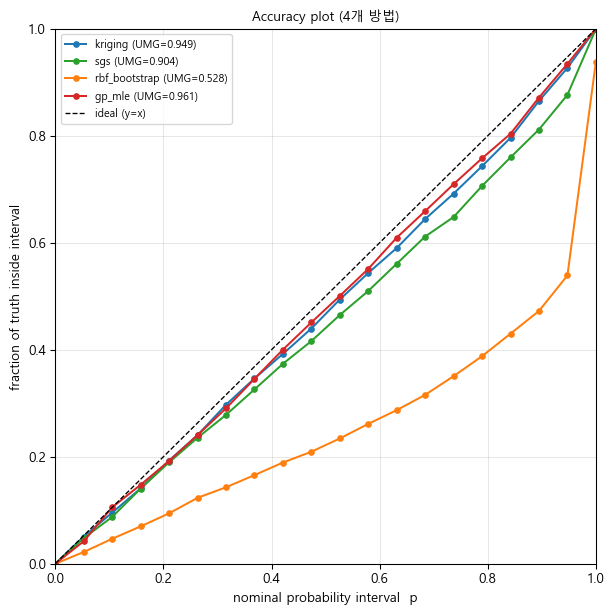

In [32]:
curves = {}
umg_vals = {}

t0 = time.time()
kp, kf = ev.kriging_fraction_in(
    truth_masked, kmap_ns_masked, std_ns_masked, vr, vrg,
    kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
    kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR)
curves["kriging"] = (kp, kf)
umg_vals["kriging"] = ev.calc_umg(kp, kf)
print("kriging_fraction_in (스칼라 역변환 경로) 소요: %.1f초" % (time.time() - t0))

for m in ["sgs", "rbf_bootstrap", "gp_mle"]:
    _mu, _sd = unc[m]
    p, f = ev.accuracy_plot_fraction_in(truth_masked, _mu, _sd)
    curves[m] = (p, f)
    umg_vals[m] = ev.calc_umg(p, f)

print()
print("UMG (1.0에 가까울수록 좋음, bins=%d):" % ev.DEFAULT_BINS)
for m in METHODS:
    print("   %-15s UMG = %.4f" % (m, umg_vals[m]))

fig, ax = plt.subplots(figsize=(6.5, 6.5))
for m in METHODS:
    p, f = curves[m]
    ax.plot(p, f, marker="o", ms=4, color=COLORS[m], label="%s (UMG=%.3f)" % (m, umg_vals[m]))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="ideal (y=x)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("nominal probability interval  p")
ax.set_ylabel("fraction of truth inside interval")
ax.set_title("Accuracy plot (4개 방법)", fontsize=10)
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout()

kriging         sum(contrib)=+1.01807  /n=20  -> G = 1 - 0.05090 = 0.94910  (ev.calc_umg=0.94910)
rbf_bootstrap   sum(contrib)=+9.44262  /n=20  -> G = 1 - 0.47213 = 0.52787  (ev.calc_umg=0.52787)


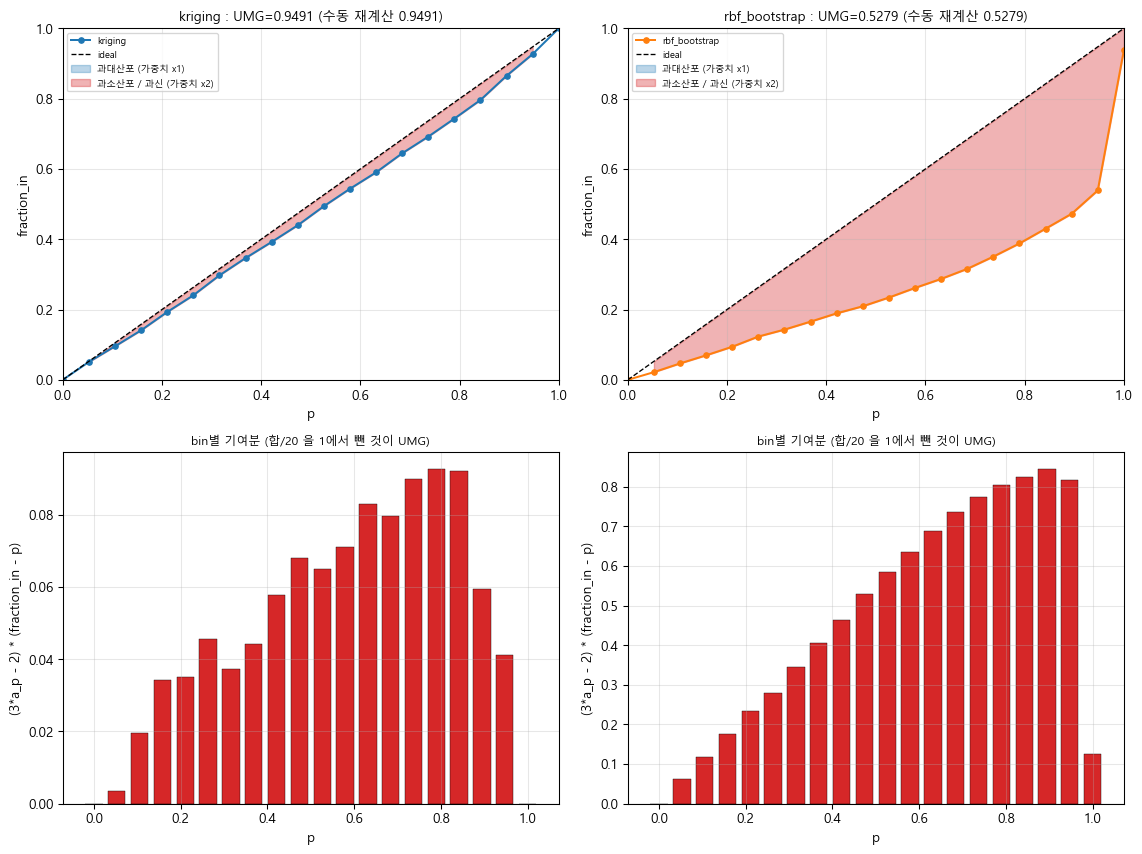

In [33]:
# calc_umg 의 적분이 어떤 면적을 재는지 시각화 (kriging = 잘 보정된 예, rbf = 과신 예)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for k, m in enumerate(["kriging", "rbf_bootstrap"]):
    p, f = curves[m]
    a_p = (f > p).astype(int)
    contrib = (3 * a_p - 2) * (f - p)
    G_manual = 1 - np.sum(contrib) / len(p)

    ax = axes[0, k]
    ax.plot(p, f, "-o", ms=4, color=COLORS[m], label=m)
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="ideal")
    ax.fill_between(p, p, f, where=(f >= p), color="tab:blue", alpha=0.3,
                    label="과대산포 (가중치 x1)")
    ax.fill_between(p, p, f, where=(f < p), color="tab:red", alpha=0.35,
                    label="과소산포 / 과신 (가중치 x2)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("p"); ax.set_ylabel("fraction_in")
    ax.set_title("%s : UMG=%.4f (수동 재계산 %.4f)" % (m, umg_vals[m], G_manual), fontsize=10)
    ax.legend(fontsize=7, loc="upper left"); ax.grid(alpha=0.3)

    ax = axes[1, k]
    ax.bar(p, contrib, width=0.04,
           color=["tab:blue" if a else "tab:red" for a in a_p], edgecolor="k", linewidth=0.3)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel("p"); ax.set_ylabel("(3*a_p - 2) * (fraction_in - p)")
    ax.set_title("bin별 기여분 (합/%d 을 1에서 뺀 것이 UMG)" % len(p), fontsize=9)
    ax.grid(alpha=0.3)

    print("%-15s sum(contrib)=%+.5f  /n=%d  -> G = 1 - %.5f = %.5f  (ev.calc_umg=%.5f)"
          % (m, np.sum(contrib), len(p), np.sum(contrib) / len(p), G_manual, umg_vals[m]))
plt.tight_layout()

## 5.5 Interval width — 한 셀의 예측 분포와 여러 nominal level 구간

**대응**: `ev.gaussian_interval_widths` / `ev.kriging_interval_widths`
(`INTERVAL_WIDTH_NOMINAL_LEVELS`는 UMG와 같은 20개 레벨에서 `p=1.0`만 뺀 것 —
p=1은 가우시안이면 폭이 무한, kriging이면 `BACKTR_ZMAX-BACKTR_ZMIN`로 상수가 되어 평균에 넣을 수 없다).

시연 셀은 **평가 대상 셀 중 가장 가까운 샘플까지의 거리가 최대인 셀**(= 외삽이 가장 심한 곳)을 고른다.

시연 셀: row=18 col=0  (X=10.0, Y=630.0), 최근접 샘플까지 184.4 m
이 셀의 truth = 20.5762 %

   kriging         NS mu=0.4719 sd=0.9544
   sgs             물리 mu=14.9047 sd=3.1165
   rbf_bootstrap   물리 mu=14.8192 sd=0.2051
   gp_mle          물리 mu=15.3489 sd=2.5853

이 셀의 중심 구간 폭 (porosity 단위):
   method          p=0.50  p=0.80  p=0.90  p=0.95  p=0.99
   kriging          3.305   6.477   8.768  10.760  15.271
   sgs              4.204   7.988  10.252  12.216  16.055
   rbf_bootstrap    0.277   0.526   0.675   0.804   1.056
   gp_mle           3.488   6.626   8.505  10.134  13.319


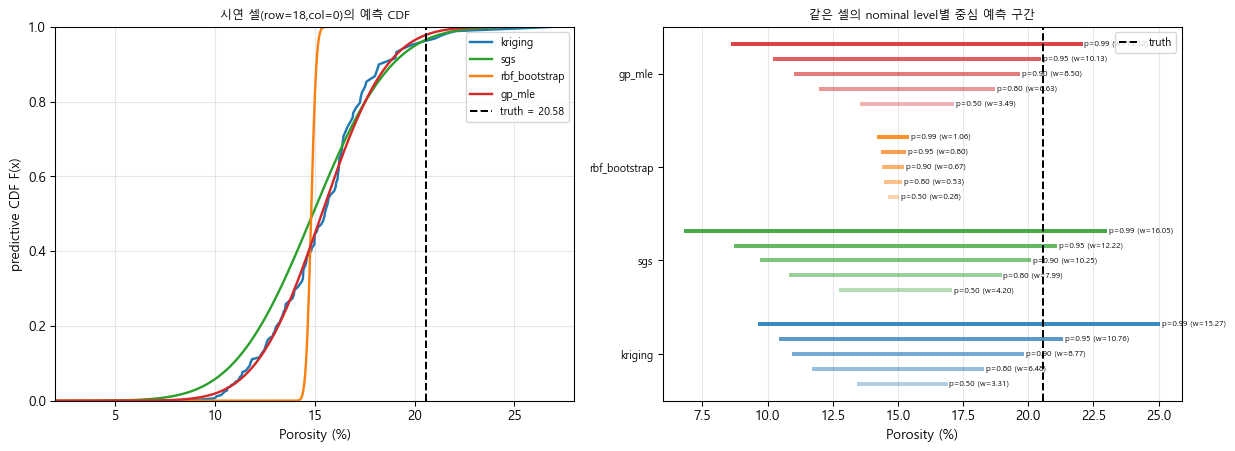

In [34]:
# 시연 셀 선정: 평가 셀 중 최근접 샘플까지 거리가 최대인 셀
_gx = grid_coords[:, 0].reshape(NY, NX)
_gy = grid_coords[:, 1].reshape(NY, NX)
_d = np.sqrt((_gx[..., None] - X_rbf[:, 0]) ** 2 + (_gy[..., None] - X_rbf[:, 1]) ** 2).min(axis=2)
_d_eval = np.where(mask, _d, -np.inf)
demo_r, demo_c = np.unravel_index(np.argmax(_d_eval), (NY, NX))
demo_flat_masked = int(np.sum(mask.ravel()[: demo_r * NX + demo_c]))  # masked 배열 내 위치

print("시연 셀: row=%d col=%d  (X=%.1f, Y=%.1f), 최근접 샘플까지 %.1f m"
      % (demo_r, demo_c, _gx[demo_r, demo_c], _gy[demo_r, demo_c], _d[demo_r, demo_c]))
y_true_cell = float(truth[demo_r, demo_c])
print("이 셀의 truth = %.4f %%" % y_true_cell)
print()

levels = np.array([0.5, 0.8, 0.9, 0.95, 0.99])
x_grid = np.linspace(2.0, 28.0, 1200)

cell_cdf = {}
cell_intervals = {}
for m in METHODS:
    if m == "kriging":
        mu_ns = np.array([kmap_ns[demo_r, demo_c]])
        sd_ns = np.array([np.sqrt(max(vmap_ns[demo_r, demo_c], 0.0))])
        _args = (vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
                 kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR,
                 kriging_mod.backtr_value_vectorized)
        taus_fine = np.linspace(1e-4, 1 - 1e-4, 1500)
        q_fine = ev.kriging_quantiles_physical(mu_ns, sd_ns, taus_fine, *_args)[0]
        cell_cdf[m] = (q_fine, taus_fine)
        tau_lo, tau_hi = 0.5 - 0.5 * levels, 0.5 + 0.5 * levels
        q_lohi = ev.kriging_quantiles_physical(mu_ns, sd_ns, np.concatenate([tau_lo, tau_hi]), *_args)[0]
        cell_intervals[m] = (q_lohi[: len(levels)], q_lohi[len(levels):])
        print("   %-15s NS mu=%.4f sd=%.4f" % (m, mu_ns[0], sd_ns[0]))
    else:
        mu = float(unc[m][0][demo_flat_masked]); sd = float(unc[m][1][demo_flat_masked])
        cell_cdf[m] = (x_grid, norm.cdf(x_grid, mu, sd))
        z = norm.ppf(0.5 + 0.5 * levels)
        cell_intervals[m] = (mu - z * sd, mu + z * sd)
        print("   %-15s 물리 mu=%.4f sd=%.4f" % (m, mu, sd))

print()
print("이 셀의 중심 구간 폭 (porosity 단위):")
print("   %-15s %s" % ("method", "  ".join("p=%.2f" % p for p in levels)))
for m in METHODS:
    lo, hi = cell_intervals[m]
    print("   %-15s %s" % (m, "  ".join("%6.3f" % w for w in (hi - lo))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for m in METHODS:
    xs, cs = cell_cdf[m]
    axes[0].plot(xs, cs, "-", lw=1.8, color=COLORS[m], label=m)
axes[0].axvline(y_true_cell, color="k", ls="--", lw=1.5, label="truth = %.2f" % y_true_cell)
axes[0].set_xlim(2, 28); axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Porosity (%)"); axes[0].set_ylabel("predictive CDF F(x)")
axes[0].set_title("시연 셀(row=%d,col=%d)의 예측 CDF" % (demo_r, demo_c), fontsize=9)
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for i, m in enumerate(METHODS):
    lo, hi = cell_intervals[m]
    for j, p in enumerate(levels):
        yy = i + (j - (len(levels) - 1) / 2.0) * 0.16
        axes[1].plot([lo[j], hi[j]], [yy, yy], "-", lw=3, color=COLORS[m], alpha=0.35 + 0.13 * j)
        axes[1].text(hi[j] + 0.15, yy, "p=%.2f (w=%.2f)" % (p, hi[j] - lo[j]), fontsize=6, va="center")
axes[1].axvline(y_true_cell, color="k", ls="--", lw=1.5, label="truth")
axes[1].set_yticks(range(len(METHODS))); axes[1].set_yticklabels(METHODS, fontsize=8)
axes[1].set_xlabel("Porosity (%)")
axes[1].set_title("같은 셀의 nominal level별 중심 예측 구간", fontsize=9)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="x")
plt.tight_layout()

## 5.6 CRPS — 세 가지 방식으로 같은 값이 나오는지 확인

**대응**: `ev.gaussian_crps` / `ev.kriging_crps` / `ev.crps_gaussian_analytic` / `ev.crps_tau_grid`.

세 가지 정의가 같은 값을 준다는 것을 한 셀에서 직접 확인한다 (GP-MLE, 가우시안이라 closed-form 존재):

- **(a) 면적 정의**: `CRPS = ∫ (F(x) - 1{x >= y})^2 dx` — 예측 CDF와 truth 계단함수 사이 면적
- **(b) pinball 정의**: `CRPS = 2 ∫_0^1 pinball_τ(y, q_τ) dτ`, `pinball_τ = (τ - 1{y<q_τ})(y - q_τ)`
  → `evaluation.py`가 실제로 쓰는 경로 (midpoint rule, `n_tau = ev.CRPS_DEFAULT_N_TAU = 199`)
- **(c) 가우시안 closed-form**: `σ [ z(2Φ(z)-1) + 2φ(z) - 1/√π ]`

kriging은 역변환 때문에 closed-form이 없으므로 (a)와 (b)만 비교한다.

시연 셀 / 방법 = gp_mle : mu=15.3489, sigma=2.5853, truth=20.5762

(a) 면적 정의   int (F - H)^2 dx           = 3.80951559
(b) pinball 수동 2 * mean(pinball_tau)      = 3.81012240
    ev.gaussian_crps (동일 경로)            = 3.81012240
(c) 가우시안 closed-form                    = 3.81009151

상대 오차 |(a)-(c)|/(c) = 1.512e-04
상대 오차 |(b)-(c)|/(c) = 8.109e-06   <- midpoint rule n_tau=199 의 quadrature 오차

n_tau 수렴:
   n_tau=  19 -> CRPS=3.80483318  (closed-form 대비 상대오차 1.380e-03)
   n_tau=  49 -> CRPS=3.81223484  (closed-form 대비 상대오차 5.625e-04)
   n_tau=  99 -> CRPS=3.81056153  (closed-form 대비 상대오차 1.234e-04)
   n_tau= 199 -> CRPS=3.81012240  (closed-form 대비 상대오차 8.109e-06)
   n_tau= 499 -> CRPS=3.81010346  (closed-form 대비 상대오차 3.136e-06)
   n_tau= 999 -> CRPS=3.81008790  (closed-form 대비 상대오차 9.472e-07)


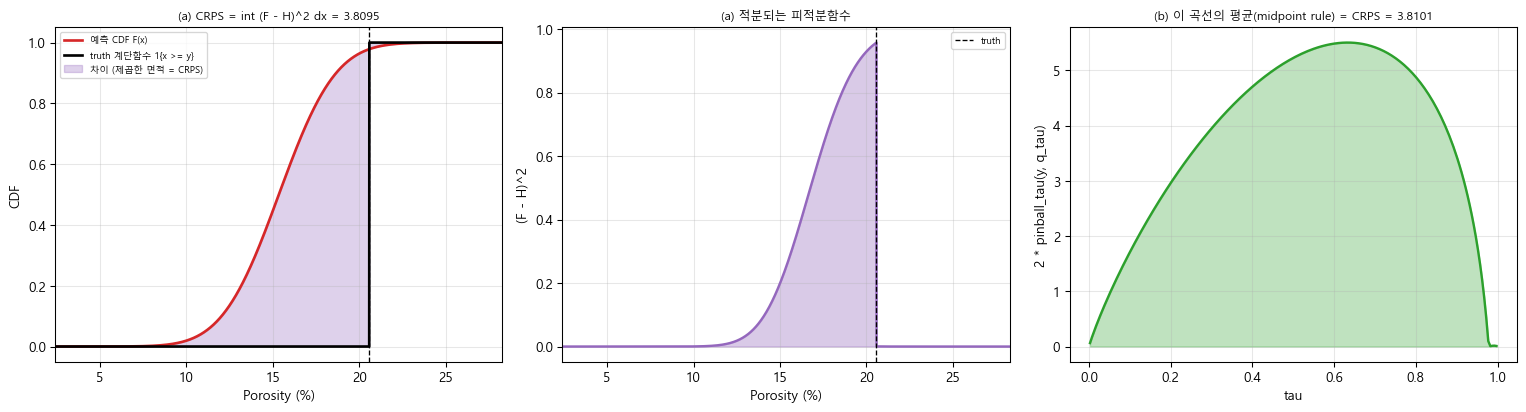

In [35]:
m = "gp_mle"
mu_c = float(unc[m][0][demo_flat_masked]); sd_c = float(unc[m][1][demo_flat_masked])
y_c = y_true_cell
print("시연 셀 / 방법 = %s : mu=%.4f, sigma=%.4f, truth=%.4f" % (m, mu_c, sd_c, y_c))
print()

# (a) 면적 정의: ∫ (F - H)^2 dx
xs = np.linspace(mu_c - 12 * sd_c, mu_c + 12 * sd_c, 40001)
F = norm.cdf(xs, mu_c, sd_c)
H = (xs >= y_c).astype(float)
crps_area = float(np.trapz((F - H) ** 2, xs))

# (b) pinball 정의 — evaluation.py 가 실제로 쓰는 경로
taus = ev.crps_tau_grid(ev.CRPS_DEFAULT_N_TAU)
q_taus = mu_c + norm.ppf(taus) * sd_c
pinball = (taus - (y_c < q_taus).astype(float)) * (y_c - q_taus)
crps_pinball_manual = float(2.0 * pinball.mean())
crps_pinball_ev = ev.gaussian_crps(np.array([y_c]), np.array([mu_c]), np.array([sd_c]))

# (c) closed form
crps_closed = ev.crps_gaussian_analytic(np.array([y_c]), np.array([mu_c]), np.array([sd_c]))

print("(a) 면적 정의   int (F - H)^2 dx           = %.8f" % crps_area)
print("(b) pinball 수동 2 * mean(pinball_tau)      = %.8f" % crps_pinball_manual)
print("    ev.gaussian_crps (동일 경로)            = %.8f" % crps_pinball_ev)
print("(c) 가우시안 closed-form                    = %.8f" % crps_closed)
print()
print("상대 오차 |(a)-(c)|/(c) = %.3e" % (abs(crps_area - crps_closed) / crps_closed))
print("상대 오차 |(b)-(c)|/(c) = %.3e   <- midpoint rule n_tau=%d 의 quadrature 오차"
      % (abs(crps_pinball_ev - crps_closed) / crps_closed, ev.CRPS_DEFAULT_N_TAU))
print()

# n_tau 수렴 확인
print("n_tau 수렴:")
for nt in [19, 49, 99, 199, 499, 999]:
    v = ev.gaussian_crps(np.array([y_c]), np.array([mu_c]), np.array([sd_c]), n_tau=nt)
    print("   n_tau=%4d -> CRPS=%.8f  (closed-form 대비 상대오차 %.3e)"
          % (nt, v, abs(v - crps_closed) / crps_closed))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
axes[0].plot(xs, F, "-", lw=2, color=COLORS[m], label="예측 CDF F(x)")
axes[0].plot(xs, H, "-", lw=2, color="k", label="truth 계단함수 1{x >= y}")
axes[0].fill_between(xs, F, H, color="tab:purple", alpha=0.3, label="차이 (제곱한 면적 = CRPS)")
axes[0].axvline(y_c, color="k", ls="--", lw=1)
axes[0].set_xlim(mu_c - 5 * sd_c, mu_c + 5 * sd_c)
axes[0].set_xlabel("Porosity (%)"); axes[0].set_ylabel("CDF")
axes[0].set_title("(a) CRPS = int (F - H)^2 dx = %.4f" % crps_area, fontsize=9)
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

axes[1].plot(xs, (F - H) ** 2, "-", lw=1.8, color="tab:purple")
axes[1].fill_between(xs, 0, (F - H) ** 2, color="tab:purple", alpha=0.35)
axes[1].axvline(y_c, color="k", ls="--", lw=1, label="truth")
axes[1].set_xlim(mu_c - 5 * sd_c, mu_c + 5 * sd_c)
axes[1].set_xlabel("Porosity (%)"); axes[1].set_ylabel("(F - H)^2")
axes[1].set_title("(a) 적분되는 피적분함수", fontsize=9)
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

axes[2].plot(taus, 2 * pinball, "-", lw=1.8, color="tab:green")
axes[2].fill_between(taus, 0, 2 * pinball, color="tab:green", alpha=0.3)
axes[2].set_xlabel("tau"); axes[2].set_ylabel("2 * pinball_tau(y, q_tau)")
axes[2].set_title("(b) 이 곡선의 평균(midpoint rule) = CRPS = %.4f" % crps_pinball_manual, fontsize=9)
axes[2].grid(alpha=0.3)
plt.tight_layout()

kriging, 같은 셀 (NS mu=0.4719 sd=0.9544, truth=20.5762):
   (a) 면적 정의 (분위수 20만점 수치적분)  = 3.879103
   (b) ev.kriging_crps (n_tau=199, pinball)  = 3.878909
   상대 차이 = 5.017e-05
   분위수 단조성: 위반 1 / 200000 지점, 최대 낙차 0.87172 %
      위반 지점 tau=0.000550, 물리값 8.32352 -> 7.45179
      이건 부동소수 반올림이 아니라 1.4절에서 확인한 '변환표 하단 불연속'이 그대로 나타난 것이다
      (원본 geostats.backtr_value 자체의 성질, 구현 버그 아님). CRPS 적분에는 이 한 점만
      기여하므로 (a)/(b) 두 경로의 일치에는 영향이 거의 없다 — 위 상대 차이 참고.

   주의: kriging의 극단 분위수(tau~0.0025/0.9975)는 정규점수 변환표 밖이라
   선형 tail 외삽 (-> BACKTR_ZMIN/ZMAX)으로 만들어진다. 이건 프로젝트 전역 규약이고
   UMG의 p->1 거동이 의존하는 것과 같은 성질이다 (kriging.py 주석 참고).


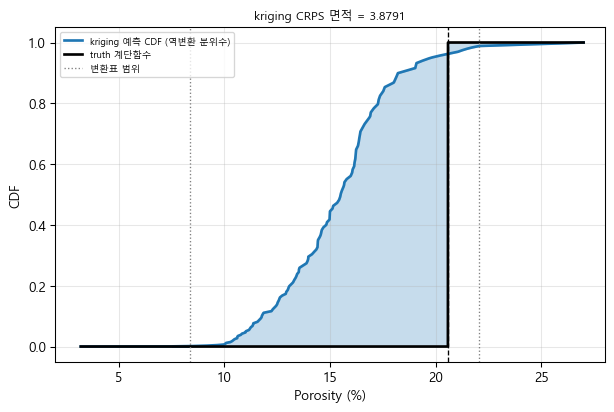

In [36]:
# kriging: closed-form이 없으므로 (a) 면적 정의 vs (b) evaluation.py 경로 비교
mu_ns_c = np.array([kmap_ns[demo_r, demo_c]])
sd_ns_c = np.array([np.sqrt(max(vmap_ns[demo_r, demo_c], 0.0))])
_kargs = (vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
          kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR,
          kriging_mod.backtr_value_vectorized)

crps_k_ev = ev.kriging_crps(np.array([y_c]), mu_ns_c, sd_ns_c, *_kargs)

# (a) 경로: 아주 촘촘한 분위수로 CDF를 만들고 int (F-H)^2 dx 를 수치적분
taus_dense = np.linspace(1e-5, 1 - 1e-5, 200001)
q_dense = ev.kriging_quantiles_physical(mu_ns_c, sd_ns_c, taus_dense, *_kargs)[0]
_ok = np.diff(q_dense) >= 0
F_k = taus_dense
H_k = (q_dense >= y_c).astype(float)
crps_k_area = float(np.trapz((F_k - H_k) ** 2, q_dense))

print("kriging, 같은 셀 (NS mu=%.4f sd=%.4f, truth=%.4f):" % (mu_ns_c[0], sd_ns_c[0], y_c))
print("   (a) 면적 정의 (분위수 20만점 수치적분)  = %.6f" % crps_k_area)
print("   (b) ev.kriging_crps (n_tau=%d, pinball)  = %.6f" % (ev.CRPS_DEFAULT_N_TAU, crps_k_ev))
print("   상대 차이 = %.3e" % (abs(crps_k_area - crps_k_ev) / crps_k_ev))
_worst = float(-np.min(np.diff(q_dense))) if np.any(~_ok) else 0.0
print("   분위수 단조성: 위반 %d / %d 지점, 최대 낙차 %.5f %%" % (int(np.sum(~_ok)), len(_ok), _worst))
if np.any(~_ok):
    _wi = int(np.argmin(np.diff(q_dense)))
    print("      위반 지점 tau=%.6f, 물리값 %.5f -> %.5f" % (taus_dense[_wi], q_dense[_wi], q_dense[_wi + 1]))
    print("      이건 부동소수 반올림이 아니라 1.4절에서 확인한 '변환표 하단 불연속'이 그대로 나타난 것이다")
    print("      (원본 geostats.backtr_value 자체의 성질, 구현 버그 아님). CRPS 적분에는 이 한 점만")
    print("      기여하므로 (a)/(b) 두 경로의 일치에는 영향이 거의 없다 — 위 상대 차이 참고.")
print()
print("   주의: kriging의 극단 분위수(tau~0.0025/0.9975)는 정규점수 변환표 밖이라")
print("   선형 tail 외삽 (-> BACKTR_ZMIN/ZMAX)으로 만들어진다. 이건 프로젝트 전역 규약이고")
print("   UMG의 p->1 거동이 의존하는 것과 같은 성질이다 (kriging.py 주석 참고).")

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.plot(q_dense, F_k, "-", lw=2, color=COLORS["kriging"], label="kriging 예측 CDF (역변환 분위수)")
ax.plot(q_dense, H_k, "-", lw=2, color="k", label="truth 계단함수")
ax.fill_between(q_dense, F_k, H_k, color="tab:blue", alpha=0.25)
ax.axvline(y_c, color="k", ls="--", lw=1)
ax.axvline(vr[0], color="gray", ls=":", lw=1)
ax.axvline(vr[-1], color="gray", ls=":", lw=1, label="변환표 범위")
ax.set_xlim(2, 28); ax.set_xlabel("Porosity (%)"); ax.set_ylabel("CDF")
ax.set_title("kriging CRPS 면적 = %.4f" % crps_k_area, fontsize=9)
ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout()

## 5.7 최종 표 — 4개 방법 × 4개 지표

`evaluate_base_case.py` / `evaluate_range_axis.py`가 만드는 tidy long-format 표와 **같은 값**이어야 한다
(단, 이 노트북은 `results/raw/`의 저장된 run을 읽지 않고 메모리에서 방금 계산한 값을 쓴다 —
seed가 전부 고정되어 있으므로 동일 파라미터라면 일치해야 한다).

**accuracy(MSE)와 uncertainty quality(UMG / width / CRPS)를 분리해서 읽는다.**

평가 셀 수 = 2379,  case = base_case 형식 (range=300 m, n_samples=125, truth_seed=101, sample_seed=20)

                   mse      umg  interval_width_p95  interval_width_mean_nominal     crps
method                                                                                   
kriging        3.31226  0.94910             6.66513                      2.36226  1.00030
sgs            3.61256  0.90433             6.28959                      2.33754  1.05161
rbf_bootstrap  3.72556  0.52787             2.97326                      1.10502  1.28952
gp_mle         3.39988  0.96117             6.51342                      2.42073  1.01578

읽는 법:
  mse                : 낮을수록 정확 (accuracy)
  umg                : 1.0에 가까울수록 보정 양호 (과소산포에 2배 벌점, 비대칭)
  interval_width_p95 : 좁을수록 sharp — 좋다/나쁘다가 아니라 umg와 함께 읽어야 한다
  crps               : 낮을수록 좋음 (proper scoring rule, 보정+sharpness 동시)

tidy long-format (저장하지 않음, 형식 확인용):
                case axis axis_level        method                      metric    va

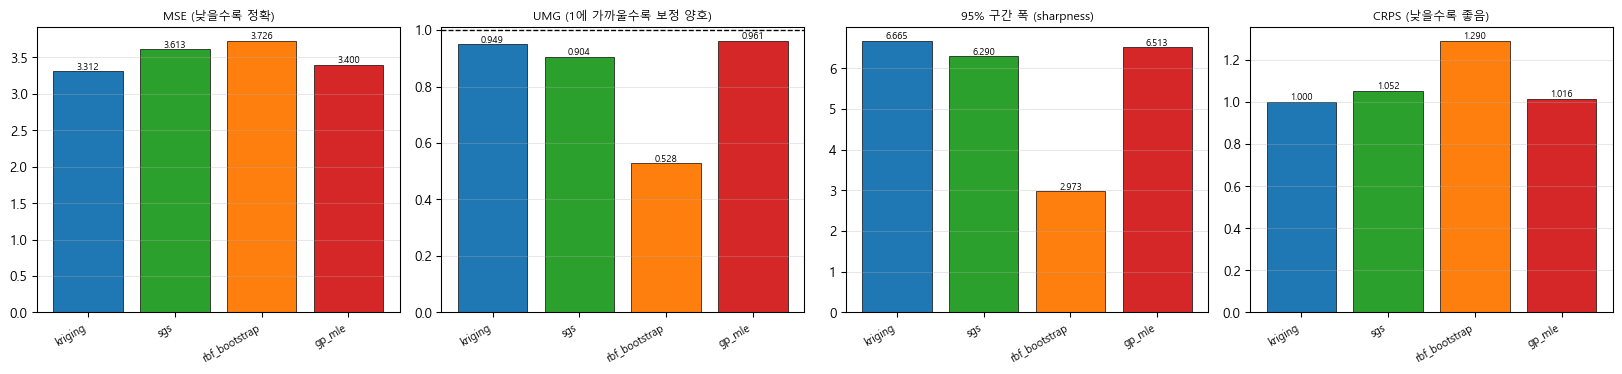

In [37]:
rows = []
for m in METHODS:
    if m == "kriging":
        _a = (vr, vrg, kriging_mod.BACKTR_ZMIN, kriging_mod.BACKTR_ZMAX,
              kriging_mod.LTAIL, kriging_mod.LTPAR, kriging_mod.UTAIL, kriging_mod.UTPAR,
              kriging_mod.backtr_value_vectorized)
        w_all = ev.kriging_interval_widths(kmap_ns_masked, std_ns_masked, *_a)
        w95 = float(ev.kriging_interval_widths(kmap_ns_masked, std_ns_masked, *_a,
                                               p_levels=np.array([ev.INTERVAL_WIDTH_HEADLINE_P]))[0])
        crps_v = ev.kriging_crps(truth_masked, kmap_ns_masked, std_ns_masked, *_a)
    else:
        _mu, _sd = unc[m]
        w_all = ev.gaussian_interval_widths(_mu, _sd)
        w95 = float(ev.gaussian_interval_widths(_mu, _sd,
                                                p_levels=np.array([ev.INTERVAL_WIDTH_HEADLINE_P]))[0])
        crps_v = ev.gaussian_crps(truth_masked, _mu, _sd)
    rows.append({"method": m,
                 "mse": mse_vals[m],
                 "umg": umg_vals[m],
                 "interval_width_p95": w95,
                 "interval_width_mean_nominal": float(np.mean(w_all)),
                 "crps": crps_v})

summary = pd.DataFrame(rows).set_index("method").loc[METHODS]
print("평가 셀 수 = %d,  case = base_case 형식 (range=%g m, n_samples=%d, truth_seed=%d, sample_seed=%d)"
      % (int(mask.sum()), RANGE, N_SAMPLES, TRUTH_SEED, SAMPLE_SEED))
print()
print(summary.round(5).to_string())
print()
print("읽는 법:")
print("  mse                : 낮을수록 정확 (accuracy)")
print("  umg                : 1.0에 가까울수록 보정 양호 (과소산포에 2배 벌점, 비대칭)")
print("  interval_width_p95 : 좁을수록 sharp — 좋다/나쁘다가 아니라 umg와 함께 읽어야 한다")
print("  crps               : 낮을수록 좋음 (proper scoring rule, 보정+sharpness 동시)")

# tidy long-format 으로도 출력 (results/processed/* 의 metrics.csv 형식)
tidy = summary.reset_index().melt(id_vars="method", var_name="metric", value_name="value")
tidy.insert(0, "case", "notebook_walkthrough")
tidy.insert(1, "axis", "none")
tidy.insert(2, "axis_level", "%g" % RANGE)
print()
print("tidy long-format (저장하지 않음, 형식 확인용):")
print(tidy.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, col, ttl in zip(axes,
                        ["mse", "umg", "interval_width_p95", "crps"],
                        ["MSE (낮을수록 정확)", "UMG (1에 가까울수록 보정 양호)",
                         "95% 구간 폭 (sharpness)", "CRPS (낮을수록 좋음)"]):
    ax.bar(range(len(METHODS)), summary[col].values,
           color=[COLORS[m] for m in METHODS], edgecolor="k", linewidth=0.5)
    ax.set_xticks(range(len(METHODS)))
    ax.set_xticklabels(METHODS, rotation=30, ha="right", fontsize=8)
    ax.set_title(ttl, fontsize=9)
    ax.grid(alpha=0.3, axis="y")
    for i, v in enumerate(summary[col].values):
        ax.text(i, v, "%.3f" % v, ha="center", va="bottom", fontsize=7)
    if col == "umg":
        ax.axhline(1.0, color="k", ls="--", lw=1)
plt.tight_layout()

---
## 검증 체크리스트 요약

이 노트북을 끝까지 실행했을 때 확인된 것 / 확인되지 않은 것:

**확인됨**
- 4개 방법 모두 §0에서 만든 **동일한 `samples_df`** 하나를 쓴다
- kriging: `kb2d`가 조건화 샘플을 하나도 드롭하지 않는다 (§1.2 가드)
- kriging: `backtr_value_vectorized`가 원본 스칼라 `geostats.backtr_value`와 1e-8 이내 일치 (§1.4)
- SGS: post-hoc honor 재적용 후 조건 데이터를 정확히 지난다 (§2.4), 히스토그램/variogram 재현 (§2.6)
- RBF: CV가 고른 하이퍼파라미터가 bootstrap replicate 전체에 고정 재사용된다 (§3.3)
- RBF: `smoothing=0` + 중복 좌표 → 특이/NaN, dedup으로 해소 (§3.5)
- GP: `sample_y`의 SVD 실패 → Cholesky fallback 경로 (§4.4)
- CRPS: 면적 정의 / pinball 정의 / 가우시안 closed-form 세 경로가 일치 (§5.6)

**이 노트북을 돌리면서 새로 드러난 것 (조율자/사용자 판단 필요)**
- `geostats.backtr_value`(원본)는 변환표 하단 `vrg[0]`에서 **불연속**이다 (§1.4).
  GSLIB `dlocate`의 clamp가 첫 구간을 bracket에서 제외하기 때문이고, 상단은 clamp 상한이
  `nt-2`라 연속이므로 **비대칭**이다. `backtr_value_vectorized`는 이 동작을 정확히 재현한다
  (즉 이 프로젝트 코드의 버그가 아니다). 결과적으로 kriging의 물리단위 예측 분위수 함수가
  최하단에서 한 번 **역전**한다 (§5.6에서 측정). 영향 범위가 좁아 base case의 CRPS/UMG에는
  거의 영향이 없어 보이지만, **kriging 분산이 커지는 축(긴 range, 큰 nugget, 외삽 축)에서
  이 구간에 걸리는 셀이 늘어나면 달라질 수 있다** — 지금은 그대로 두고 기록만 한다.

**이 노트북으로 확인되지 않는 것**
- `results/raw/`에 저장된 **기존 run들과의 수치 일치** — 이 노트북은 저장된 배열을 읽지 않고
  메모리에서 새로 계산한다. bit-for-bit 대조가 필요하면 별도 회귀 스크립트가 필요하다.
- `src/experiments/*.py`의 **저장 경로**(`make_run_dir`/`save_result`/manifest 생성) — 의도적으로 호출하지 않았다.
- 여러 ground truth realization에 걸친 통계 — 이 노트북은 `TRUTH_SEED` 하나만 다룬다.